In [1]:
# •	File name: Evolv1-Hourly energy analysis code
# •	Author: Ehsan Akbari
# •	Affiliation: University of Waterloo, PhD student.


In [ ]:
# import torch 
# from torch import nn 
# from torch.utils.data import DataLoader
import numpy as np 
import dask.dataframe as dd
import pandas as pd  
import glob
import os 
import matplotlib.pyplot as plt   
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
Data = pd.read_csv('C:/Users/User/OneDrive - University of Waterloo/Evolv1-code and data till end 2023/Evolv1/End_of_2023/Total_Energy_Consumption(kWh).csv', encoding='latin-1')   
Data = pd.DataFrame(Data)
Data1 = Data.drop('Date', axis=1) 
Data_1 = Data1.values
print (Data_1.shape)

Data2 = pd.read_csv('C:/Users/User/OneDrive - University of Waterloo/Evolv1-code and data till end 2023/Evolv1/End_of_2023/Whole_EV_consumption(kWh).csv', encoding='latin-1')
Data2 = pd.DataFrame(Data2)
Data2 = Data2.drop('Date', axis=1) 
Data_2 = Data2.values
print (Data_2.shape)

Temp = pd.read_csv('C:/Users/User/OneDrive - University of Waterloo/Evolv1-code and data till end 2023/Evolv1/End_of_2023/Outside_ Temperature.csv', encoding='latin-1')
Temp = pd.DataFrame(Temp)
Temp2 = Temp.drop('Date', axis=1) 
Temp_2 = Temp2.values
print (Temp_2.shape)

Radiation = pd.read_csv('C:/Users/User/OneDrive - University of Waterloo/Evolv1-code and data till end 2023/Evolv1/End_of_2023/PV_Generation(kWh)_parkinglot.csv', encoding='latin-1')
Radiation = pd.DataFrame(Radiation)
Radiation2 = Radiation.drop('Date', axis=1) 
Radiation_2 = Radiation2.values
Radiation_2.shape
print (Radiation_2.shape)

POA = pd.read_csv('C:/Users/User/OneDrive - University of Waterloo/Evolv1-code and data till end 2023/Evolv1/For radiation/POA.csv', encoding='latin-1')   
POA_df = pd.DataFrame(POA)
poa = POA_df.drop('Date', axis=1) 
poa = poa.values
POA_df

Solar_Angles = pd.read_csv('C:/Users/User/OneDrive - University of Waterloo/Evolv1-code and data till end 2023/Evolv1/For radiation/Solar Angles.csv', encoding='latin-1')   
Solar_Angles_df = pd.DataFrame(Solar_Angles)
Solar_Azimuth = Solar_Angles_df['Site Solar Azimuth Angle'].values
Solar_Altitude = Solar_Angles_df['Site Solar Altitude Angle'].values
Solar_Azimuth

Data_new = Data_1-Data_2

(1095, 24)
(1095, 24)
(1095, 24)
(1095, 24)


In [4]:
# POA_df = POA_df.rename(columns={'sd': 'Date'})
poa1=poa.reshape(1,26280)
poa1
poa2=poa.reshape(26280,1)

In [21]:
Data_new.shape

(1095, 24)

In [23]:
X_E1=Data_new

In [25]:
X_E1.max()

232.007

In [27]:
scaled_data_X_E1 = (X_E1 - X_E1.min())/ (X_E1.max() - X_E1.min())
# X_scaled = scaled_data_X_E*(X_E.max() - X_E.min()) 
scaled_data_X_E1

array([[0.42659337, 0.41024107, 0.43102572, ..., 0.40914615, 0.38955048,
        0.39399789],
       [0.39028795, 0.40179401, 0.39125118, ..., 0.3541368 , 0.3481693 ,
        0.35129979],
       [0.33268993, 0.34960662, 0.34657396, ..., 0.34478295, 0.5289815 ,
        0.58773841],
       ...,
       [0.37261874, 0.36716672, 0.39746325, ..., 0.37402972, 0.37191889,
        0.36663995],
       [0.3666851 , 0.37107607, 0.37411249, ..., 0.34421856, 0.34241627,
        0.3463482 ],
       [0.35063005, 0.34392132, 0.34403043, ..., 0.12704827, 0.12704827,
        0.12704827]])

In [29]:
dates = pd.date_range(start='2021-01-01', periods=1095, freq='D')
dates = dates.astype(object)

# Concatenate the date column with the original array horizontally
data_with_date = np.hstack((np.expand_dims(dates, axis=1), X_E1))
Data_with_date_normalize = np.hstack((np.expand_dims(dates, axis=1), scaled_data_X_E1))
DF_N=pd.DataFrame(Data_with_date_normalize)
DF_=pd.DataFrame(data_with_date)
DF_

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,2021-01-01,79.611,75.265,80.789,102.531,128.606,128.73,118.224,104.632,102.867,...,85.69,85.741,87.328,89.711,77.376,99.209,72.159,74.974,69.766,70.948
1,2021-01-02,69.962,73.02,70.218,72.306,74.018,64.712,61.899,62.091,58.56,...,52.897,54.954,58.658,60.534,59.771,59.198,57.344,60.354,58.768,59.6
2,2021-01-03,54.654,59.15,58.344,60.697,61.886,61.979,62.184,61.617,64.864,...,56.22,58.109,62.138,62.949,60.646,61.431,58.621,57.868,106.823,122.439
3,2021-01-04,120.893,119.074,116.742,109.607,140.845,154.348,116.057,112.742,101.682,...,90.751,119.438,105.397,95.399,78.559,72.612,69.41,67.629,68.096,68.6
4,2021-01-05,70.638,67.675,70.717,70.464,134.422,121.67,105.697,109.976,110.059,...,108.767,109.349,106.13,110.279,95.155,90.572,88.229,75.984,80.205,77.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,2023-12-27,63.145,62.267,69.615,66.857,82.587,72.474,100.684,92.822,91.832,...,82.489,81.456,89.704,84.833,67.715,67.557,61.908,63.283,62.587,58.888
1091,2023-12-28,66.756,64.903,69.506,66.172,76.288,71.869,99.761,93.442,81.087,...,76.603,84.042,80.45,86.02,69.971,67.359,64.013,64.357,63.099,65.096
1092,2023-12-29,65.266,63.817,71.869,66.487,80.403,73.877,100.184,91.857,94.036,...,84.643,85.735,93.618,95.734,76.005,70.521,63.466,65.641,65.08,63.677
1093,2023-12-30,63.689,64.856,65.663,66.837,67.027,64.473,61.911,60.241,57.165,...,56.761,55.865,55.027,58.279,63.192,57.845,59.871,57.718,57.239,58.284


In [31]:
cl_whole_df=pd.DataFrame(X_E1, columns=[f'Hour_{i}' for i in range(24)])
cl_N_whole_df=pd.DataFrame(scaled_data_X_E1, columns=[f'Hour_{i}' for i in range(24)])
# consumption_cl1_df=consumption_cl1_df.reset_index(drop=True)
cl_whole_df['Date'] = DF_[0]
cl_N_whole_df['Date'] = DF_[0]
cl_N_whole_df

,Hour_0,Hour_1,Hour_2,Hour_3,Hour_4,Hour_5,Hour_6,Hour_7,Hour_8,Hour_9,...,Hour_15,Hour_16,Hour_17,Hour_18,Hour_19,Hour_20,Hour_21,Hour_22,Hour_23,Date
0,0.426593,0.410241,0.431026,0.512832,0.610942,0.611409,0.571879,0.520738,0.514097,0.473348,...,0.449658,0.455629,0.464596,0.418184,0.500333,0.398554,0.409146,0.389550,0.393998,2021-01-01
1,0.390288,0.401794,0.391251,0.399108,0.405549,0.370534,0.359950,0.360672,0.347387,0.344418,...,0.333819,0.347755,0.354814,0.351943,0.349787,0.342811,0.354137,0.348169,0.351300,2021-01-02
2,0.332690,0.349607,0.346574,0.355427,0.359901,0.360251,0.361022,0.358889,0.371106,0.350570,...,0.345690,0.360849,0.363901,0.355235,0.358189,0.347616,0.344783,0.528981,0.587738,2021-01-03
3,0.581921,0.575077,0.566303,0.539457,0.656993,0.707800,0.563725,0.551252,0.509638,0.508709,...,0.576447,0.523616,0.485997,0.422635,0.400259,0.388211,0.381510,0.383267,0.385163,2021-01-04
4,0.392831,0.381683,0.393129,0.392177,0.632826,0.584845,0.524745,0.540845,0.541157,0.547659,...,0.538486,0.526374,0.541985,0.485079,0.467835,0.459020,0.412946,0.428828,0.420268,2021-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,0.364638,0.361335,0.388982,0.378605,0.437791,0.399740,0.505883,0.476301,0.472576,0.440809,...,0.433535,0.464569,0.446242,0.381833,0.381239,0.359984,0.365157,0.362539,0.348621,2023-12-27
1091,0.378225,0.371253,0.388572,0.376028,0.414090,0.397463,0.502410,0.478634,0.432147,0.456258,...,0.443265,0.429750,0.450708,0.390322,0.380494,0.367904,0.369199,0.364465,0.371979,2023-12-28
1092,0.372619,0.367167,0.397463,0.377213,0.429573,0.405019,0.504002,0.472670,0.480869,0.465630,...,0.449636,0.479296,0.487258,0.413025,0.392391,0.365846,0.374030,0.371919,0.366640,2023-12-29
1093,0.366685,0.371076,0.374112,0.378530,0.379245,0.369635,0.359995,0.353712,0.342138,0.337751,...,0.337246,0.334093,0.346329,0.364815,0.344696,0.352319,0.344219,0.342416,0.346348,2023-12-30


In [33]:
import pandas as pd
import numpy as np

# Assume cl1_df is your DataFrame with columns 'Date', 'Hour_0' to 'Hour_23'

# Function to detect outliers using the IQR method and replace them with zeros
def replace_outliers_with_zeros(data):
    replaced_df = data.copy()

    for hour in range(24):
        column_name = f'Hour_{hour}'
        hour_data = data[column_name]

        Q1 = np.percentile(hour_data, 25)
        Q3 = np.percentile(hour_data, 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 4 * IQR

        is_outlier = (hour_data < lower_bound) | (hour_data > upper_bound)

        # Replace outliers with zero
        replaced_df[column_name] = np.where(is_outlier, 0, hour_data)

    return replaced_df

# Function to detect outliers using the IQR method and replace them with the average
def replace_outliers_with_average(data):
    replaced_df = data.copy()

    for hour in range(24):
        column_name = f'Hour_{hour}'
        hour_data = data[column_name]

        Q1 = np.percentile(hour_data, 25)
        Q3 = np.percentile(hour_data, 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5* IQR
        upper_bound = Q3 + 4.5* IQR

        is_outlier = (hour_data < lower_bound) | (hour_data > upper_bound)

        # Calculate the mean for each hour
        mean = np.mean(hour_data)

        # Replace outliers with the mean
        replaced_data = hour_data.copy()
        replaced_data[is_outlier] = mean
        replaced_df[column_name] = replaced_data

    return replaced_df

# Detect outliers and replace them with zeros
replaced_with_zeros_df = replace_outliers_with_zeros(cl_whole_df)

# Detect outliers and replace them with average
replaced_with_average_df = replace_outliers_with_average(cl_whole_df)

# Output the DataFrame with outliers replaced by zeros
print("Data with Outliers Replaced by Zeros:")
print(replaced_with_zeros_df)

# Output the DataFrame with outliers replaced by average
print("Data with Outliers Replaced by Average:")
print(replaced_with_average_df)

Data with Outliers Replaced by Zeros:
      Hour_0  Hour_1   Hour_2   Hour_3   Hour_4   Hour_5   Hour_6   Hour_7  \
0     79.611  75.265   80.789  102.531  128.606  128.730  118.224  104.632   
1     69.962  73.020   70.218   72.306   74.018   64.712   61.899   62.091   
2      0.000  59.150   58.344   60.697   61.886   61.979   62.184   61.617   
3      0.000   0.000  116.742  109.607  140.845  154.348  116.057  112.742   
4     70.638  67.675   70.717   70.464  134.422  121.670  105.697  109.976   
...      ...     ...      ...      ...      ...      ...      ...      ...   
1090  63.145  62.267   69.615   66.857   82.587   72.474  100.684   92.822   
1091  66.756  64.903   69.506   66.172   76.288   71.869   99.761   93.442   
1092  65.266  63.817   71.869   66.487   80.403   73.877  100.184   91.857   
1093  63.689  64.856   65.663   66.837   67.027   64.473   61.911   60.241   
1094  59.422  57.639   57.668   56.250   60.192   58.792   59.424   58.562   

       Hour_8   Hour_9  .

In [35]:

# Initialize a NumPy array to store the count of zeros for each day
final_replaced_df=replaced_with_zeros_df
zero_counts = np.zeros(len(replaced_with_zeros_df['Date'].unique()))

# Iterate over each unique date
for i, date in enumerate(replaced_with_zeros_df['Date'].unique()):
    # Count the number of zeros in each day
    daily_data = replaced_with_zeros_df[replaced_with_zeros_df['Date'] == date]
    zero_count = (daily_data.iloc[:, 1:] == 0).sum().sum()  # count zeros in all hours of the day
    zero_counts[i] = zero_count
    if zero_count > 4:
        # Make all the values of that day zero
        final_replaced_df.loc[final_replaced_df['Date'] == date, final_replaced_df.columns[0:]] = 0
    else:
        # Replace zeroes with the corresponding values from replaced_with_average_df for this day
        for hour in range(24):
            column_name = f'Hour_{hour}'
            final_replaced_df.loc[(final_replaced_df['Date'] == date) & (final_replaced_df[column_name] == 0), column_name] = replaced_with_average_df.loc[replaced_with_average_df['Date'] == date, column_name]

# Output the final DataFrame
print("Final DataFrame with replacements based on the number of zeroes:")
print(final_replaced_df)


C:\Users\User\AppData\Local\Temp\ipykernel_24248\485980533.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  final_replaced_df.loc[final_replaced_df['Date'] == date, final_replaced_df.columns[0:]] = 0


Final DataFrame with replacements based on the number of zeroes:
        Hour_0     Hour_1   Hour_2   Hour_3   Hour_4   Hour_5   Hour_6  \
0     79.61100  75.265000   80.789  102.531  128.606  128.730  118.224   
1     69.96200  73.020000   70.218   72.306   74.018   64.712   61.899   
2     69.53408  59.150000   58.344   60.697   61.886   61.979   62.184   
3     69.53408  69.288499  116.742  109.607  140.845  154.348  116.057   
4     70.63800  67.675000   70.717   70.464  134.422  121.670  105.697   
...        ...        ...      ...      ...      ...      ...      ...   
1090  63.14500  62.267000   69.615   66.857   82.587   72.474  100.684   
1091  66.75600  64.903000   69.506   66.172   76.288   71.869   99.761   
1092  65.26600  63.817000   71.869   66.487   80.403   73.877  100.184   
1093  63.68900  64.856000   65.663   66.837   67.027   64.473   61.911   
1094   0.00000   0.000000    0.000    0.000    0.000    0.000    0.000   

       Hour_7   Hour_8   Hour_9  ...  Hour_15 

In [36]:
cl_clean=final_replaced_df.drop(columns=['Date']) 
cl_clean=cl_clean.values
X_clean=cl_clean


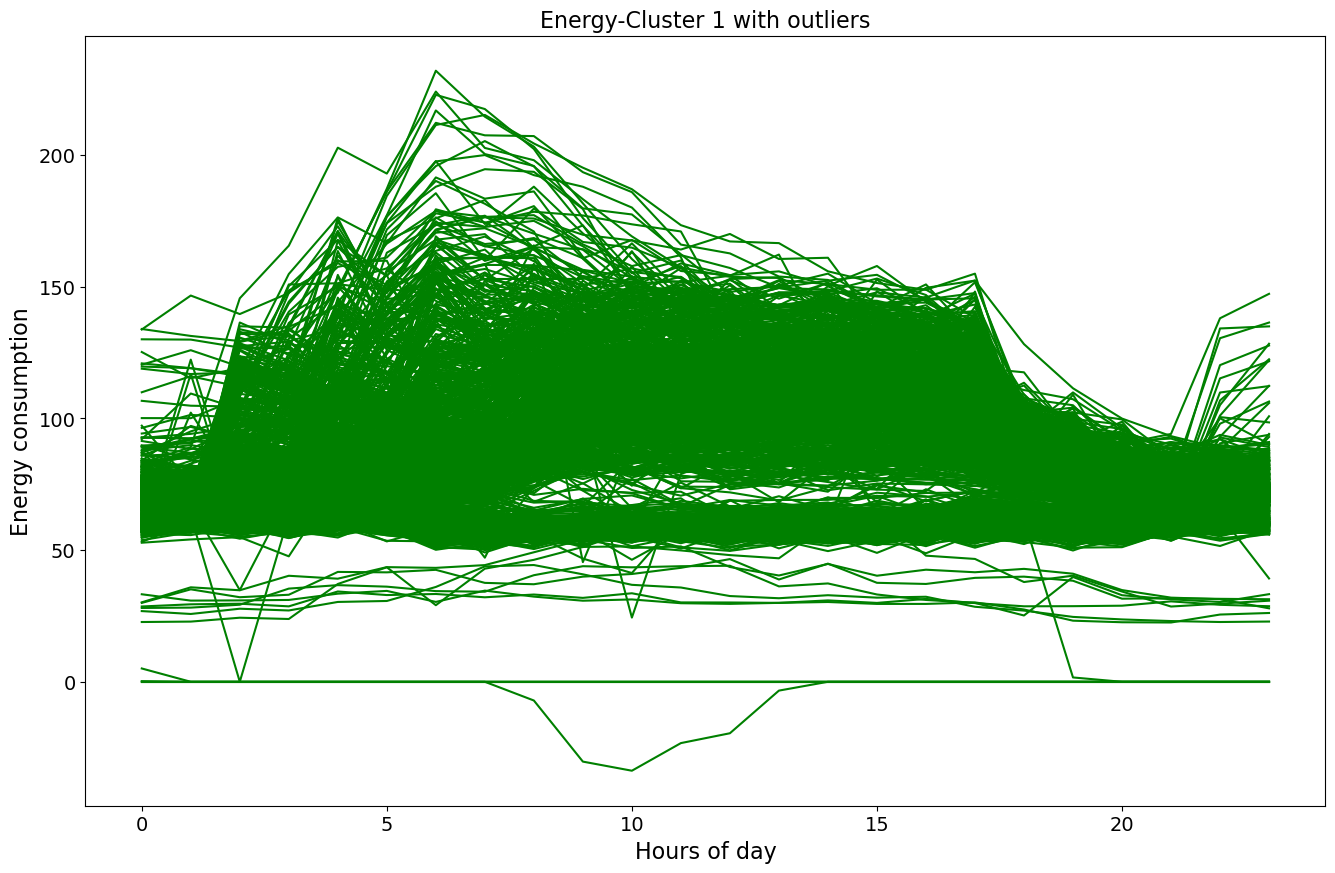

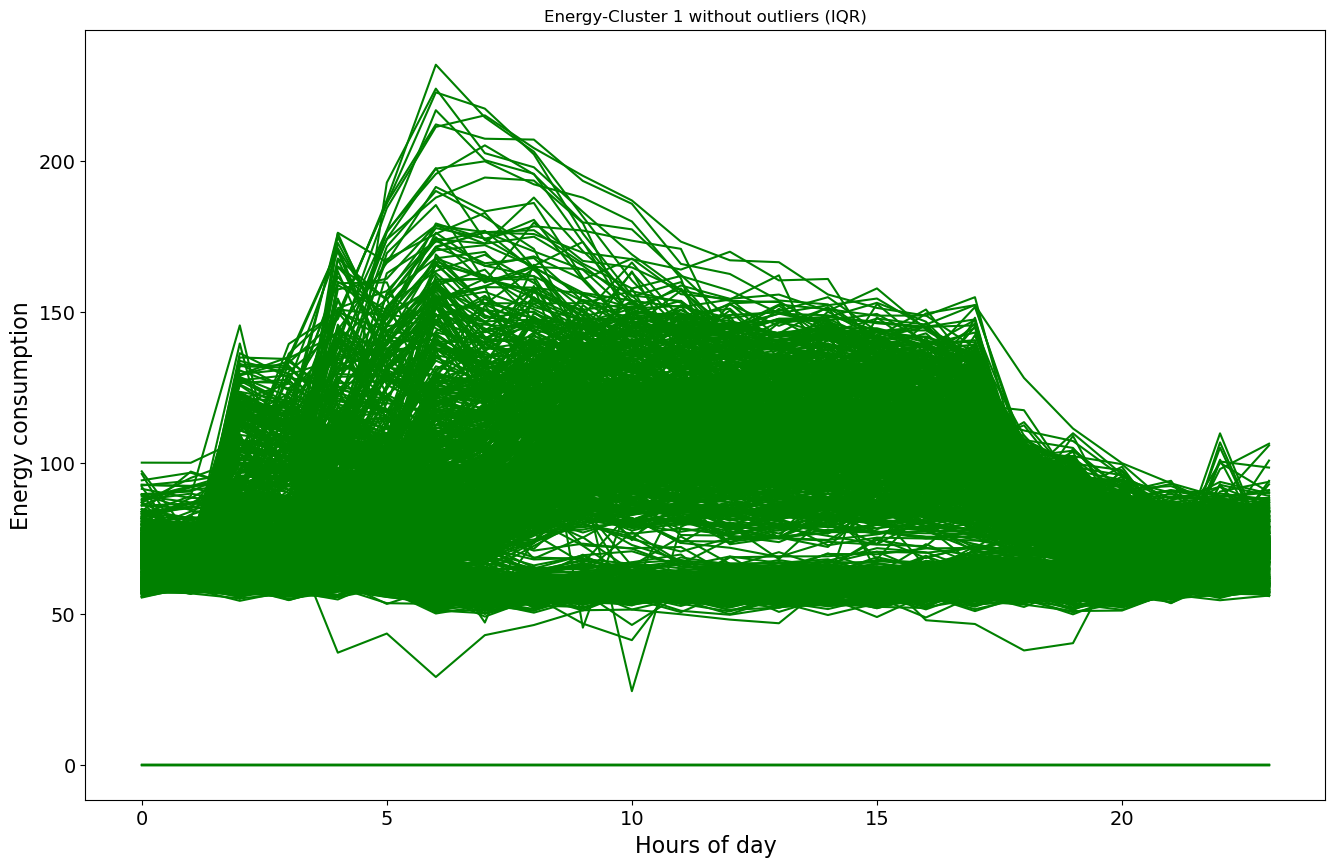

In [37]:
plt.figure(figsize=(16, 10))
for i in range(X_E1.shape[0]):
        plt.plot(X_E1[i], color = 'green') 
#         plt.ylim(0, 0.5)
#         plt.xlabel("Hours of day")
        plt.xlabel('Hours of day', fontsize=16)
        plt.xticks(fontsize=14)
        plt.ylabel("Energy consumption", fontsize=16)
        plt.yticks(fontsize=14)
        plt.title("Energy-Cluster 1 with outliers",fontsize=16)

plt.figure(figsize=(16, 10))
for i in range(cl_clean.shape[0]):
        plt.plot(cl_clean[i], color = 'green') 
#         plt.ylim(0.02, 0.7)
        plt.xlabel('Hours of day', fontsize=16)
        plt.xticks(fontsize=14)
        plt.ylabel("Energy consumption", fontsize=16)
        plt.yticks(fontsize=14)  
        plt.title("Energy-Cluster 1 without outliers (IQR)")


In [38]:
import pandas as pd
import numpy as np

# Assume cl1_df is your DataFrame with columns 'Date', 'Hour_0' to 'Hour_23'

# Function to detect outliers using the IQR method and replace them with zeros
def replace_outliers_with_zeros(data):
    replaced_df = data.copy()

    for hour in range(24):
        column_name = f'Hour_{hour}'
        hour_data = data[column_name]

        Q1 = np.percentile(hour_data, 25)
        Q3 = np.percentile(hour_data, 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 4.5 * IQR

        is_outlier = (hour_data < lower_bound) | (hour_data > upper_bound)

        # Replace outliers with zero
        replaced_df[column_name] = np.where(is_outlier, 0, hour_data)

    return replaced_df

# Function to detect outliers using the IQR method and replace them with the average
def replace_outliers_with_average(data):
    replaced_df = data.copy()

    for hour in range(24):
        column_name = f'Hour_{hour}'
        hour_data = data[column_name]

        Q1 = np.percentile(hour_data, 25)
        Q3 = np.percentile(hour_data, 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 4 * IQR

        is_outlier = (hour_data < lower_bound) | (hour_data > upper_bound)

        # Calculate the mean for each hour
        mean = np.mean(hour_data)

        # Replace outliers with the mean
        replaced_data = hour_data.copy()
        replaced_data[is_outlier] = mean
        replaced_df[column_name] = replaced_data

    return replaced_df

# Detect outliers and replace them with zeros
replaced_with_zeros_N_df = replace_outliers_with_zeros(cl_N_whole_df)

# Detect outliers and replace them with average
replaced_with_average_N_df = replace_outliers_with_average(cl_N_whole_df)

# Output the DataFrame with outliers replaced by zeros
print("Data with Outliers Replaced by Zeros:")
print(replaced_with_zeros_N_df)

# Output the DataFrame with outliers replaced by average
print("Data with Outliers Replaced by Average:")
print(replaced_with_average_N_df)

Data with Outliers Replaced by Zeros:
        Hour_0    Hour_1    Hour_2    Hour_3    Hour_4    Hour_5    Hour_6  \
0     0.426593  0.410241  0.431026  0.512832  0.610942  0.611409  0.571879   
1     0.390288  0.401794  0.391251  0.399108  0.405549  0.370534  0.359950   
2     0.000000  0.349607  0.346574  0.355427  0.359901  0.360251  0.361022   
3     0.000000  0.000000  0.566303  0.539457  0.656993  0.707800  0.563725   
4     0.392831  0.381683  0.393129  0.392177  0.632826  0.584845  0.524745   
...        ...       ...       ...       ...       ...       ...       ...   
1090  0.364638  0.361335  0.388982  0.378605  0.437791  0.399740  0.505883   
1091  0.378225  0.371253  0.388572  0.376028  0.414090  0.397463  0.502410   
1092  0.372619  0.367167  0.397463  0.377213  0.429573  0.405019  0.504002   
1093  0.366685  0.371076  0.374112  0.378530  0.379245  0.369635  0.359995   
1094  0.350630  0.343921  0.344030  0.338695  0.353527  0.348260  0.350638   

        Hour_7    Hour_8 

In [39]:
# Initialize a NumPy array to store the count of zeros for each day
final_replaced_N_df=replaced_with_zeros_N_df
zero_counts = np.zeros(len(replaced_with_zeros_N_df['Date'].unique()))

# Iterate over each unique date
for i, date in enumerate(replaced_with_zeros_N_df['Date'].unique()):
    # Count the number of zeros in each day
    daily_data = replaced_with_zeros_N_df[replaced_with_zeros_N_df['Date'] == date]
    zero_count = (daily_data.iloc[:, 1:] == 0).sum().sum()  # count zeros in all hours of the day
    zero_counts[i] = zero_count
    if zero_count > 4:
        # Make all the values of that day zero
        final_replaced_N_df.loc[final_replaced_N_df['Date'] == date, final_replaced_N_df.columns[0:]] = 0
    else:
        # Replace zeroes with the corresponding values from replaced_with_average_df for this day
        for hour in range(24):
            column_name = f'Hour_{hour}'
            final_replaced_N_df.loc[(final_replaced_N_df['Date'] == date) & (final_replaced_N_df[column_name] == 0), column_name] = replaced_with_average_N_df.loc[replaced_with_average_N_df['Date'] == date, column_name]

# Output the final DataFrame
print("Final DataFrame with replacements based on the number of zeroes:")
print(final_replaced_N_df)

C:\Users\User\AppData\Local\Temp\ipykernel_24248\3211495430.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  final_replaced_N_df.loc[final_replaced_N_df['Date'] == date, final_replaced_N_df.columns[0:]] = 0


Final DataFrame with replacements based on the number of zeroes:
        Hour_0    Hour_1    Hour_2    Hour_3    Hour_4    Hour_5    Hour_6  \
0     0.426593  0.410241  0.431026  0.512832  0.610942  0.611409  0.571879   
1     0.390288  0.401794  0.391251  0.399108  0.405549  0.370534  0.359950   
2     0.388678  0.349607  0.346574  0.355427  0.359901  0.360251  0.361022   
3     0.388678  0.387754  0.566303  0.539457  0.656993  0.707800  0.563725   
4     0.392831  0.381683  0.393129  0.392177  0.632826  0.584845  0.524745   
...        ...       ...       ...       ...       ...       ...       ...   
1090  0.364638  0.361335  0.388982  0.378605  0.437791  0.399740  0.505883   
1091  0.378225  0.371253  0.388572  0.376028  0.414090  0.397463  0.502410   
1092  0.372619  0.367167  0.397463  0.377213  0.429573  0.405019  0.504002   
1093  0.366685  0.371076  0.374112  0.378530  0.379245  0.369635  0.359995   
1094  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   

In [40]:
cl_clean=final_replaced_N_df.drop(columns=['Date']) 
cl_clean=cl_clean.values
X_N_clean=cl_clean

In [41]:
scaled_data_X_E1.shape

(1095, 24)

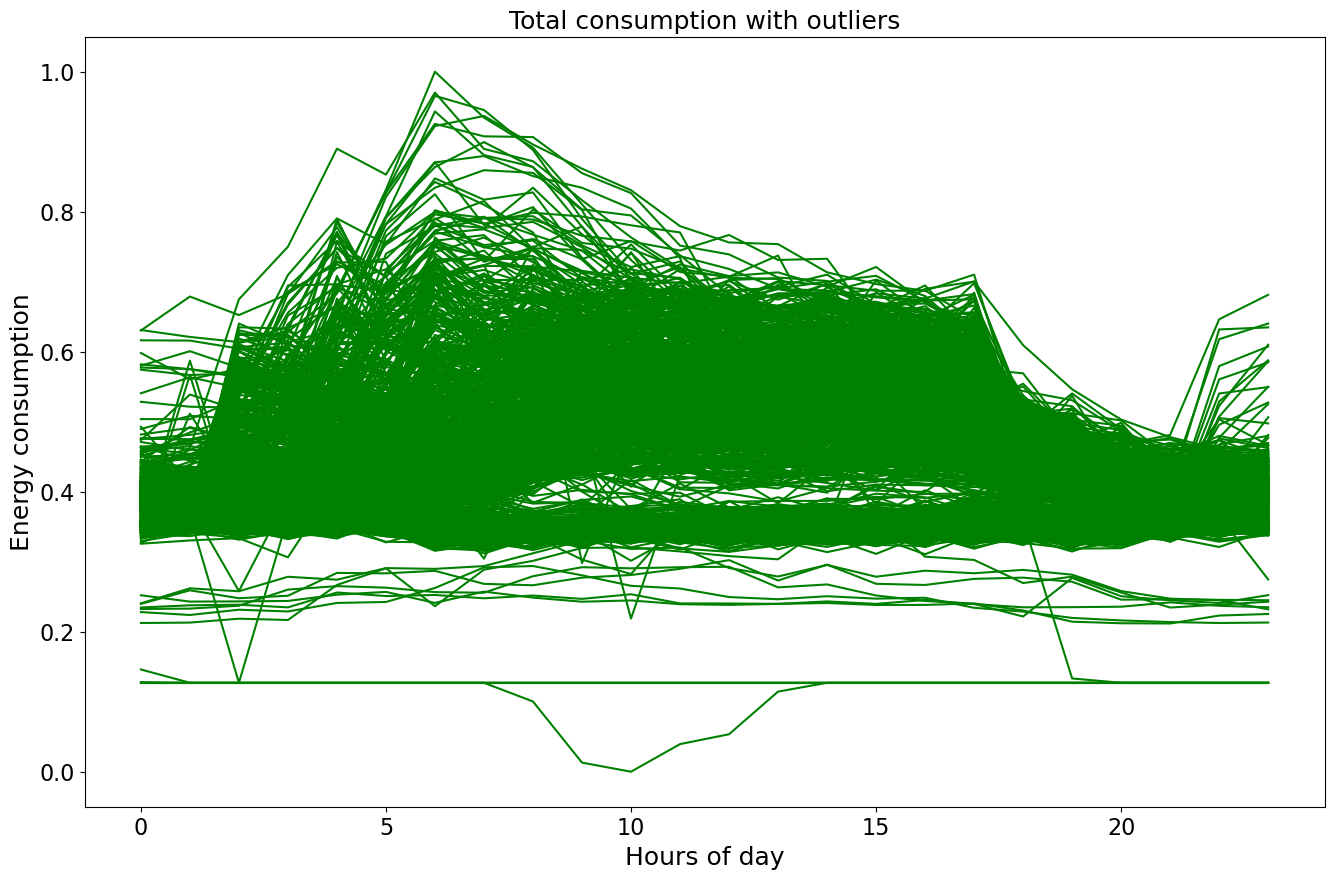

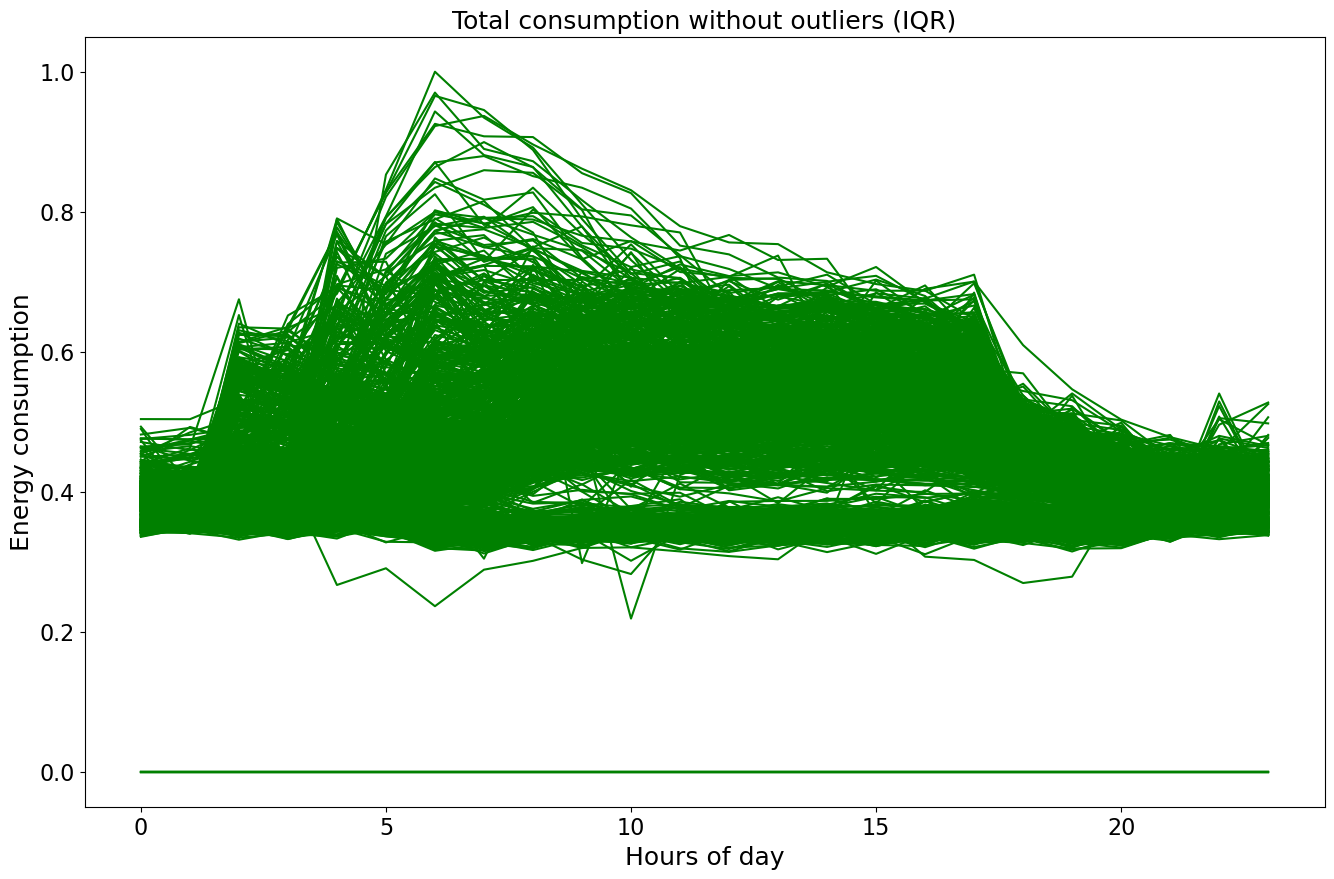

In [42]:
plt.figure(figsize=(16, 10))
for i in range(scaled_data_X_E1.shape[0]):
        plt.plot(scaled_data_X_E1[i], color = 'green') 
#         plt.ylim(0, 0.5)
        plt.xlabel('Hours of day', fontsize=18)
        plt.xticks(fontsize=16)
        plt.ylabel("Energy consumption", fontsize=18)
        plt.yticks(fontsize=16)
        plt.title("Total consumption with outliers",fontsize=18)

plt.figure(figsize=(16, 10))
for i in range(cl_clean.shape[0]):
        plt.plot(cl_clean[i], color = 'green') 
#         plt.ylim(0.02, 0.7)
        plt.xlabel('Hours of day', fontsize=18)
        plt.xticks(fontsize=16)
        plt.ylabel("Energy consumption", fontsize=18)
        plt.yticks(fontsize=16)  
        plt.title("Total consumption without outliers (IQR)",fontsize=18)

In [43]:
def calculate_ssd(x, y, a, b):
    return np.sum((y - (a * x + b))**2)

# Apply the elbow method to find a "breaking point"
def find_breaking_point(x, y):
    ssds = []
    for i in range(1, len(x)):
        a1, b1 = np.polyfit(x[:i], y[:i], 1)
        a2, b2 = np.polyfit(x[i:], y[i:], 1)
        ssd = calculate_ssd(x[:i], y[:i], a1, b1) + calculate_ssd(x[i:], y[i:], a2, b2)
        ssds.append(ssd)
            
    # Apply elbow detection logic to identify the breaking point
    diff_ssds = np.diff(ssds)
    max_diff_index = np.argmax(diff_ssds)
    
    return max_diff_index + 1

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows wi

breaking point = 10


C:\Users\User\AppData\Local\Temp\ipykernel_24248\2570200928.py:9: RankWarning: Polyfit may be poorly conditioned
  a2, b2 = np.polyfit(x[i:], y[i:], 1)
C:\Users\User\AppData\Local\Temp\ipykernel_24248\2570200928.py:8: RankWarning: Polyfit may be poorly conditioned
  a1, b1 = np.polyfit(x[:i], y[:i], 1)
C:\Users\User\AppData\Local\Temp\ipykernel_24248\2570200928.py:9: RankWarning: Polyfit may be poorly conditioned
  a2, b2 = np.polyfit(x[i:], y[i:], 1)


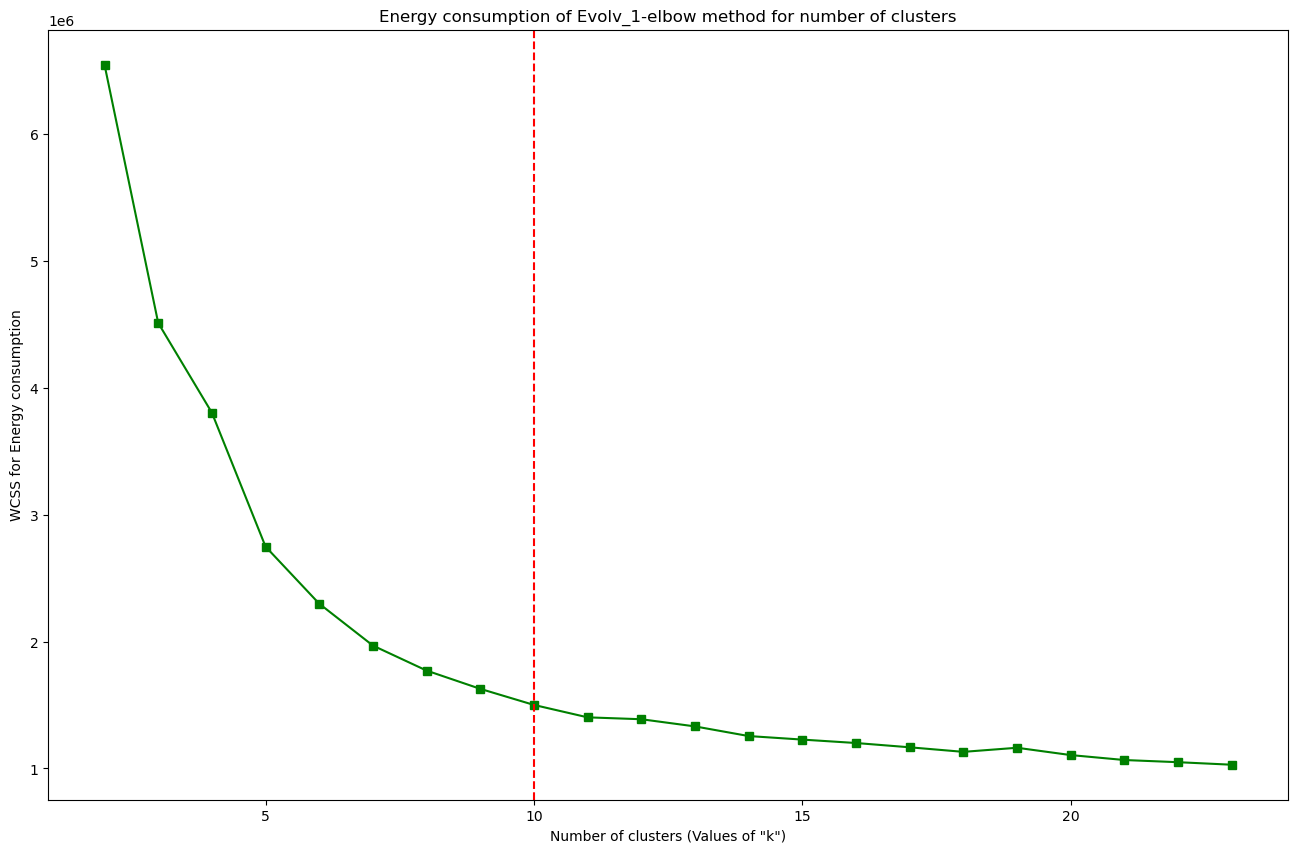

In [44]:
# determining the maximum number of clusters for Energy consumption of Evolv1
# using the elbow method
from sklearn.cluster import KMeans
limit = int((X_clean.shape[0]//2)**0.5)
 
# selecting optimal value of 'k'
# using elbow method
 
# wcss - within cluster sum of
# squared distances
wcss = {}
 
for k in range(2,limit+1):
    model = KMeans(n_clusters=k)
    model.fit(X_clean)
    wcss[k] = model.inertia_
elbow_break_point=find_breaking_point(np.array(list(wcss.keys())), np.array(list(wcss.values())))     
print(f"breaking point = {elbow_break_point}")
# plotting the wcss values
# to find out the elbow value
plt.figure(figsize=(16, 10))
plt.plot(wcss.keys(), wcss.values(), 'gs-')
plt.axvline(x=find_breaking_point(np.array(list(wcss.keys())), np.array(list(wcss.values()))), color='r', linestyle='--', label='Breaking Point')
plt.xlabel('Number of clusters (Values of "k")')
plt.ylabel('WCSS for Energy consumption')
plt.title("Energy consumption of Evolv_1-elbow method for number of clusters")
plt.show()

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows wi

breaking point = 11


C:\Users\User\AppData\Local\Temp\ipykernel_24248\2570200928.py:8: RankWarning: Polyfit may be poorly conditioned
  a1, b1 = np.polyfit(x[:i], y[:i], 1)
C:\Users\User\AppData\Local\Temp\ipykernel_24248\2570200928.py:9: RankWarning: Polyfit may be poorly conditioned
  a2, b2 = np.polyfit(x[i:], y[i:], 1)
C:\Users\User\AppData\Local\Temp\ipykernel_24248\2570200928.py:8: RankWarning: Polyfit may be poorly conditioned
  a1, b1 = np.polyfit(x[:i], y[:i], 1)
C:\Users\User\AppData\Local\Temp\ipykernel_24248\2570200928.py:9: RankWarning: Polyfit may be poorly conditioned
  a2, b2 = np.polyfit(x[i:], y[i:], 1)


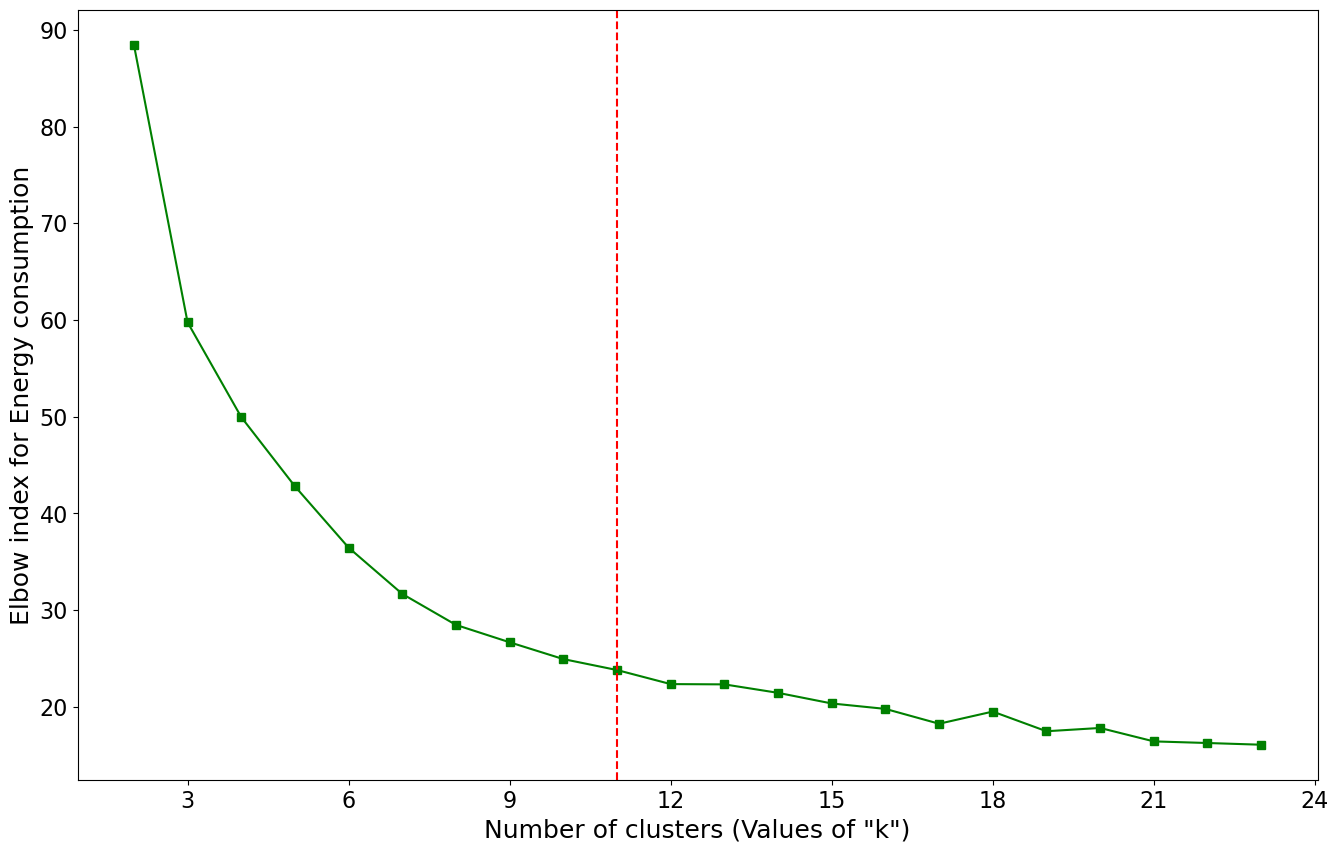

In [45]:
# determining the maximum number of clusters for Energy consumption of Evolv1 Normalized data 
# using the elbow method
from matplotlib.ticker import MaxNLocator
from sklearn.cluster import KMeans
limit = int((scaled_data_X_E1.shape[0]//2)**0.5)
 
# selecting optimal value of 'k'
# using elbow method
 
# wcss - within cluster sum of
# squared distances
wcss = {}
 
for k in range(2,limit+1):
    model = KMeans(n_clusters=k)
    model.fit(scaled_data_X_E1)
    wcss[k] = model.inertia_
elbow_break_point2=find_breaking_point(np.array(list(wcss.keys())), np.array(list(wcss.values())))     
print(f"breaking point = {elbow_break_point2}")
# plotting the wcss values
# to find out the elbow value
plt.figure(figsize=(16, 10))
plt.plot(wcss.keys(), wcss.values(), 'gs-')
plt.axvline(x=find_breaking_point(np.array(list(wcss.keys())), np.array(list(wcss.values()))), color='r', linestyle='--', label='Breaking Point')
# plt.axvline(x=6, color='r', linestyle='--', label='Breaking Point')
plt.xlabel('Number of clusters (Values of "k")',fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel('Elbow index for Energy consumption',fontsize=18)
plt.yticks(fontsize=16)
# plt.title("Energy consumption of Evolv_1-elbow method for number of clusters")
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


Silhouette Score for k = 2: 0.521
Silhouette Score for k = 3: 0.444


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


Silhouette Score for k = 4: 0.462
Silhouette Score for k = 5: 0.364


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


...

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


Silhouette Score for k = 20: 0.233
Silhouette Score for k = 21: 0.235


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


Silhouette Score for k = 22: 0.212
Silhouette Score for k = 23: 0.242


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


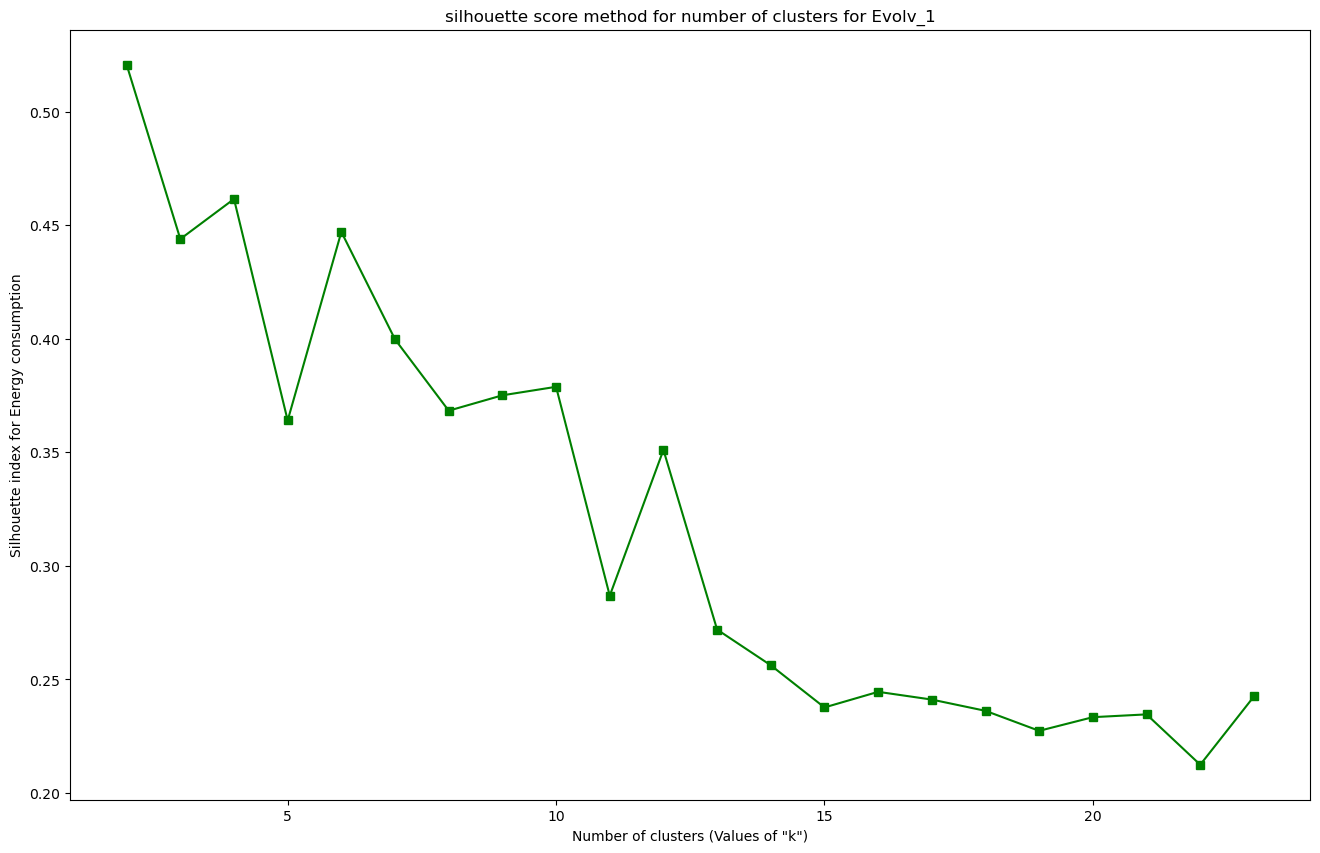

In [59]:
# determining the maximum number of clusters
# using the silhouette index
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
limit = int((X_clean.shape[0]//2)**0.5)
 
# determining number of clusters
# using silhouette score method
Ki=np.zeros(limit-1)
silhouette_index=np.zeros(limit-1)
i=0
for k in range(2, limit+1):
    model = KMeans(n_clusters=k)
    model.fit(X_clean)
    pred = model.predict(X_clean)
    score = silhouette_score(X_clean, pred)
    Ki[i]=k
    silhouette_index[i]=score
    print('Silhouette Score for k = {}: {:<.3f}'.format(k, score))
    i=i+1

plt.figure(figsize=(16, 10))
plt.plot(Ki, silhouette_index, 'gs-')
plt.xlabel('Number of clusters (Values of "k")')
plt.ylabel('Silhouette index for Energy consumption')
plt.title("silhouette score method for number of clusters for Evolv_1")
plt.show()

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


Silhouette Score for k = 2: 0.514
Silhouette Score for k = 3: 0.444


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


Silhouette Score for k = 4: 0.409
Silhouette Score for k = 5: 0.425


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


...

Silhouette Score for k = 19: 0.231
Silhouette Score for k = 20: 0.238


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


Silhouette Score for k = 21: 0.228
Silhouette Score for k = 22: 0.225


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


Silhouette Score for k = 23: 0.217


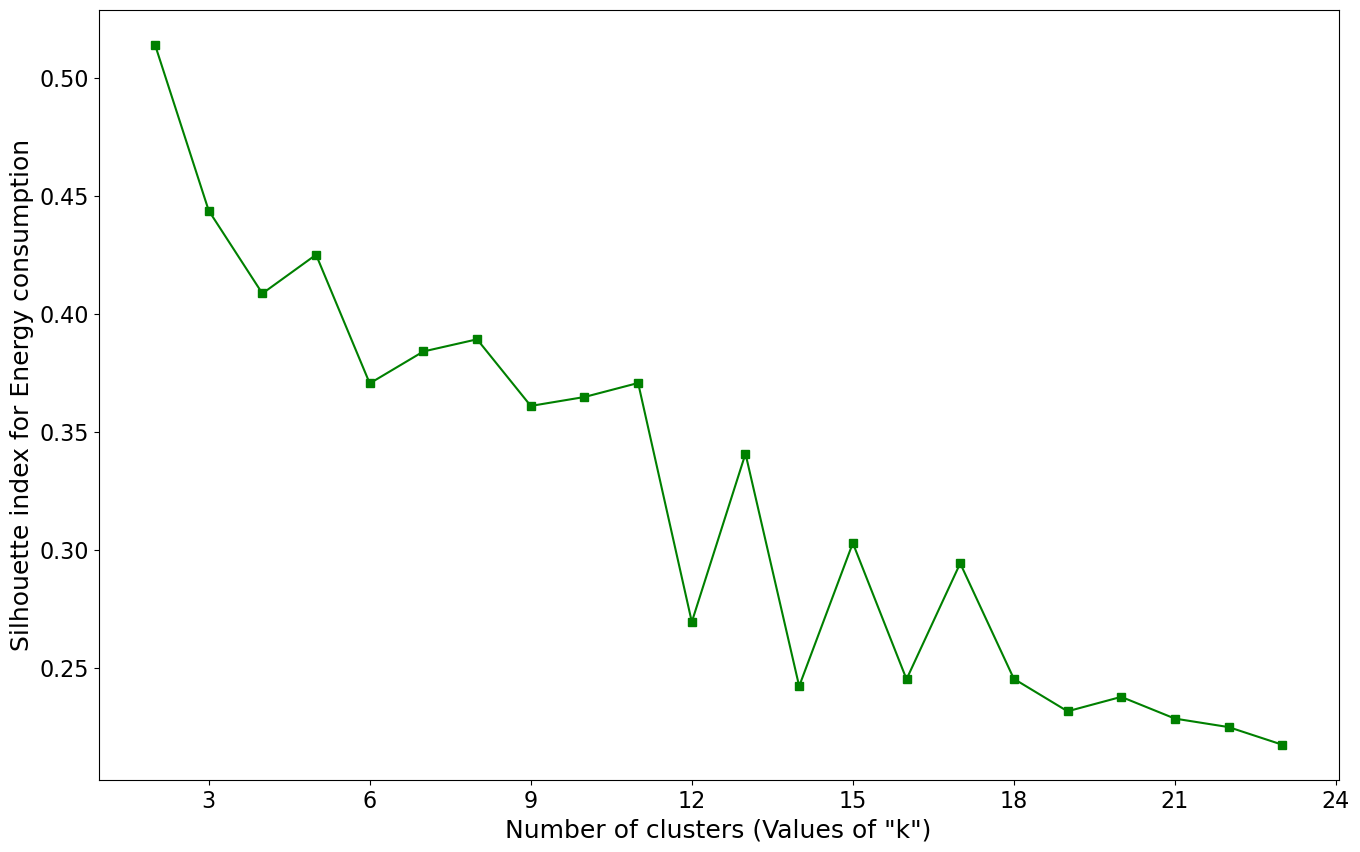

In [63]:
# determining the maximum number of clusters normalized data
# using the silhouette index
from matplotlib.ticker import MaxNLocator
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
limit = int((scaled_data_X_E1.shape[0]//2)**0.5)
 
# determining number of clusters
# using silhouette score method
Ki=np.zeros(limit-1)
silhouette_index=np.zeros(limit-1)
i=0
for k in range(2, limit+1):
    model = KMeans(n_clusters=k)
    model.fit(scaled_data_X_E1)
    pred = model.predict(scaled_data_X_E1)
    score = silhouette_score(scaled_data_X_E1, pred)
    Ki[i]=k
    silhouette_index[i]=score
    print('Silhouette Score for k = {}: {:<.3f}'.format(k, score))
    i=i+1

plt.figure(figsize=(16, 10))
plt.plot(Ki, silhouette_index, 'gs-')
plt.xlabel('Number of clusters (Values of "k")',fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel('Silhouette index for Energy consumption',fontsize=18)
plt.yticks(fontsize=16)
# plt.title("silhouette score method for number of clusters with Normalized data for Evolv_1")
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

In [53]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=8, random_state=3).fit(X_N_clean)

Dayly_Energy_labels1=kmeans.labels_

Dayly_Energy_labels1

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


array([5, 0, 0, ..., 4, 0, 2])

In [54]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=7, random_state=0).fit(X_N_clean)

Dayly_Energy_labels2=kmeans.labels_

Dayly_Energy_labels2

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


array([6, 1, 1, ..., 4, 1, 2])

Text(0.5, 1.0, 'Energy-Cluster 8')

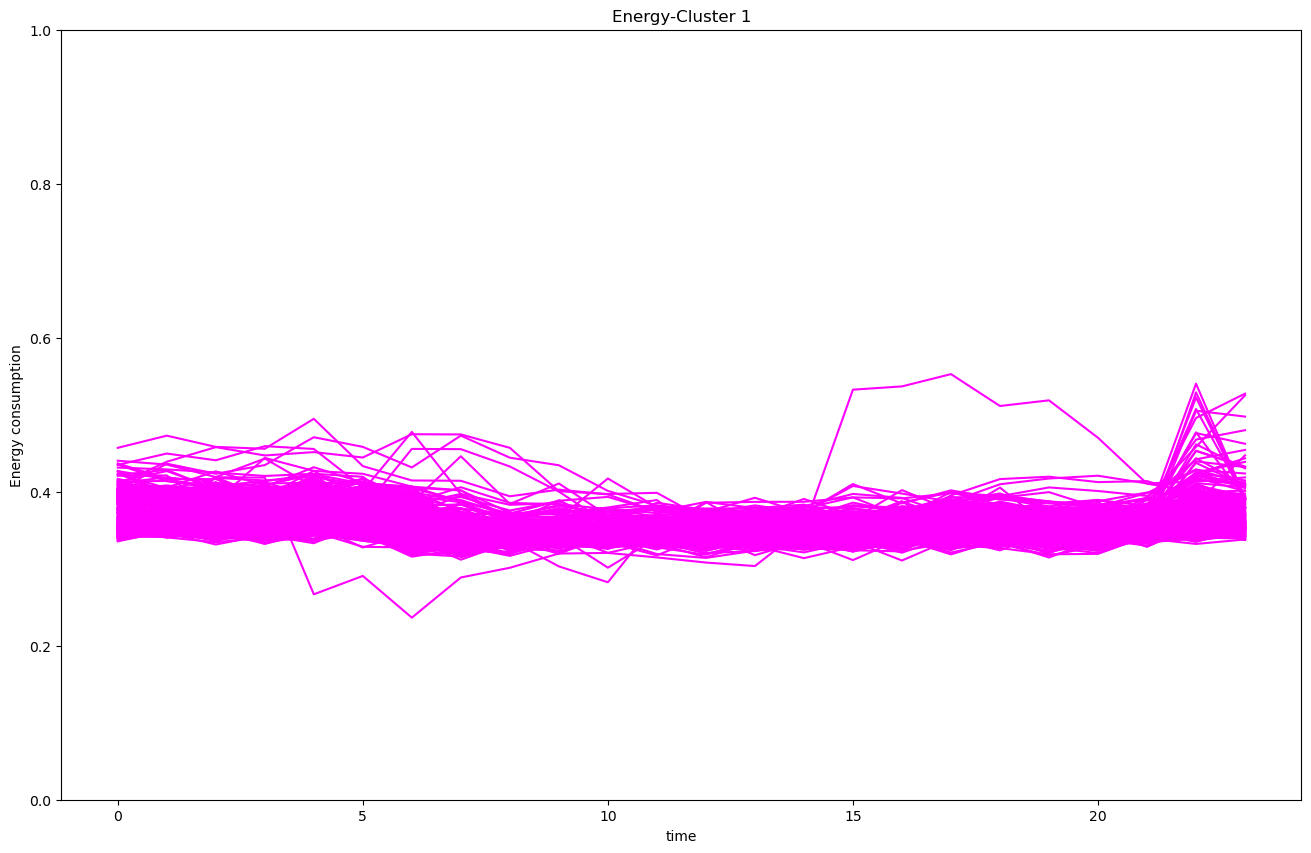

<Figure size 640x480 with 0 Axes>

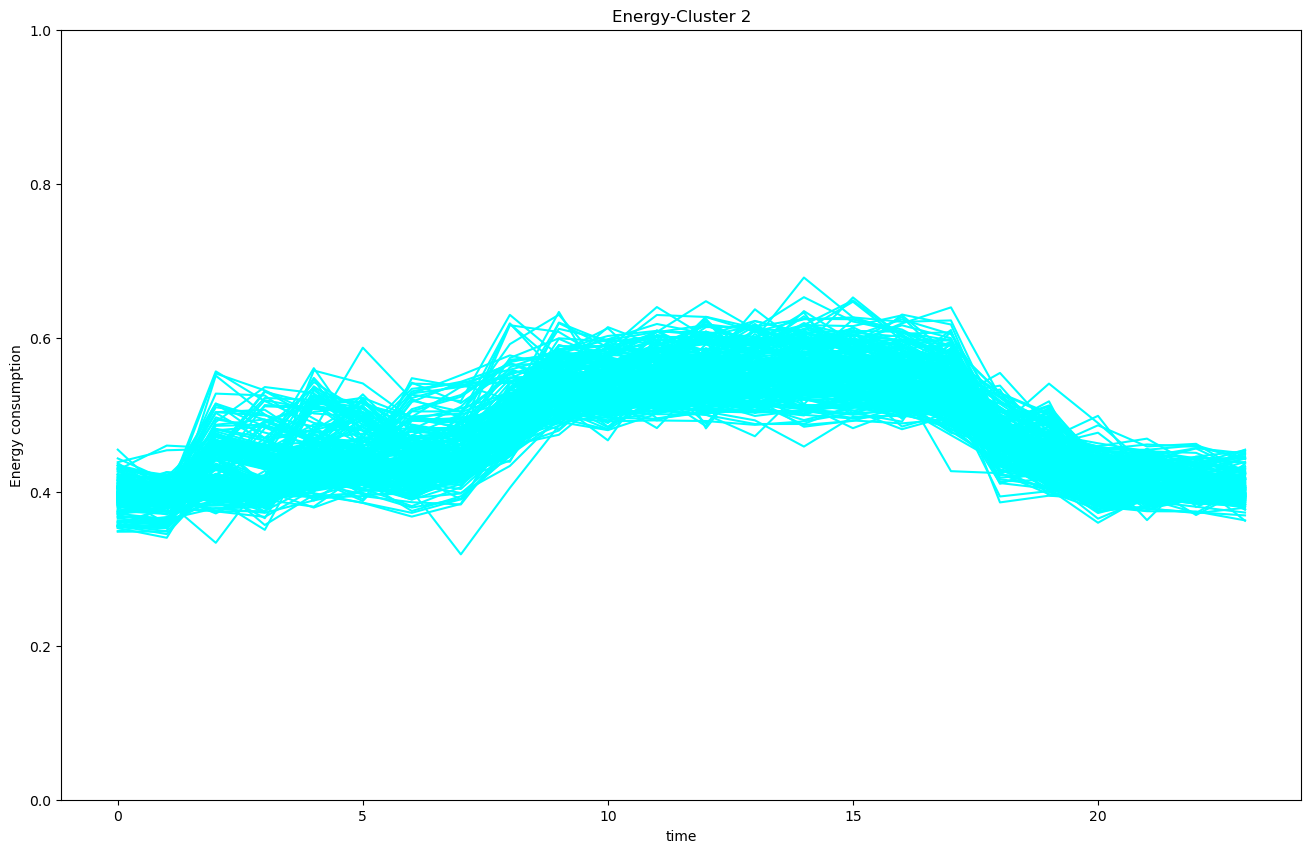

<Figure size 640x480 with 0 Axes>

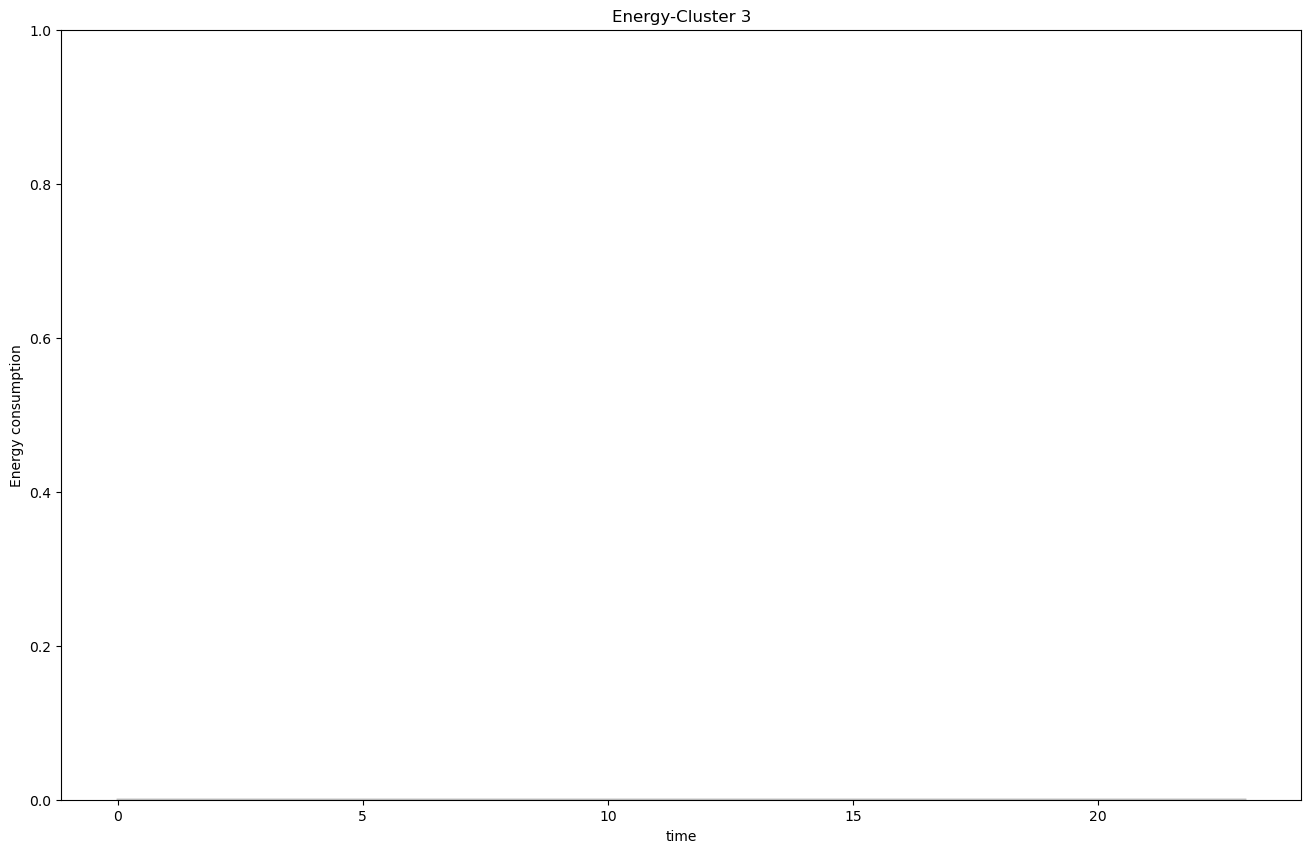

<Figure size 640x480 with 0 Axes>

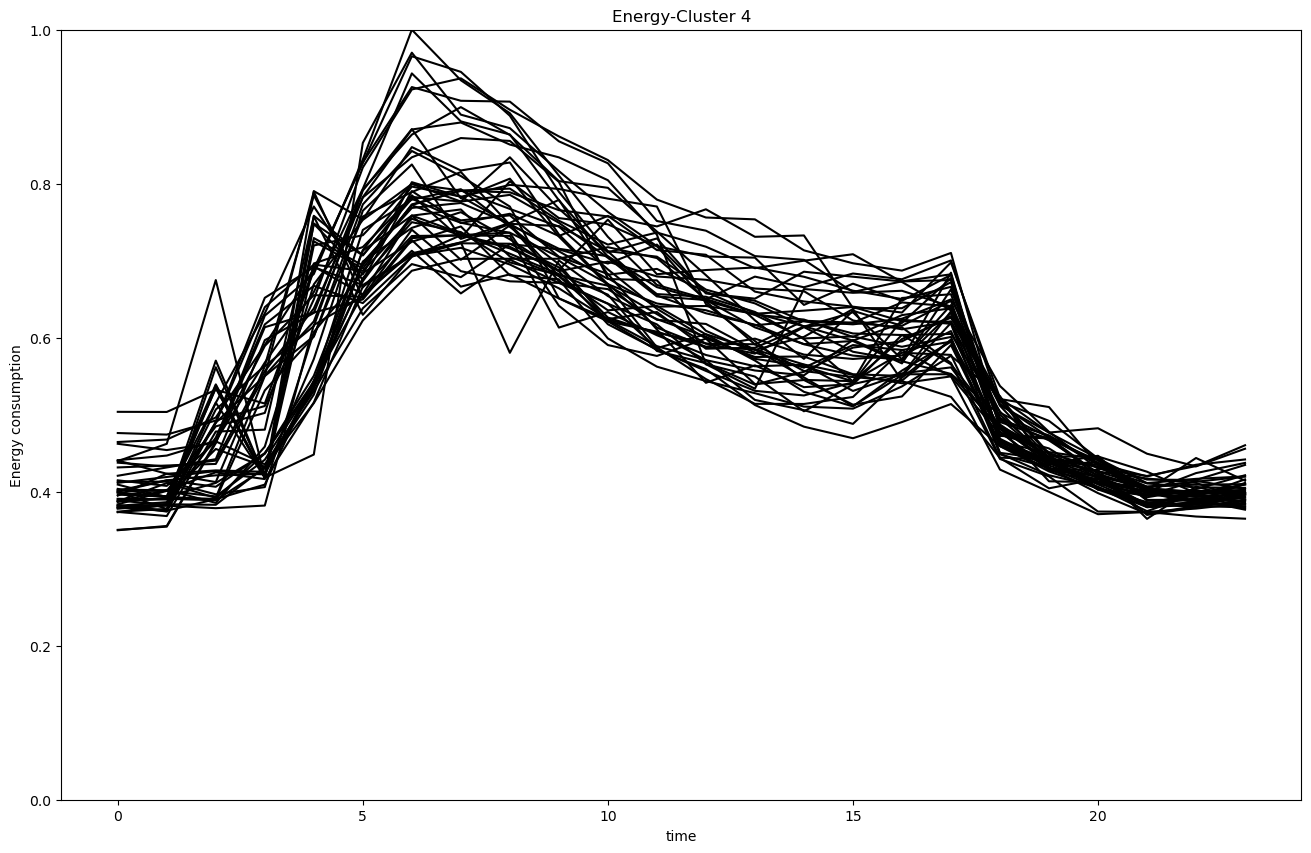

<Figure size 640x480 with 0 Axes>

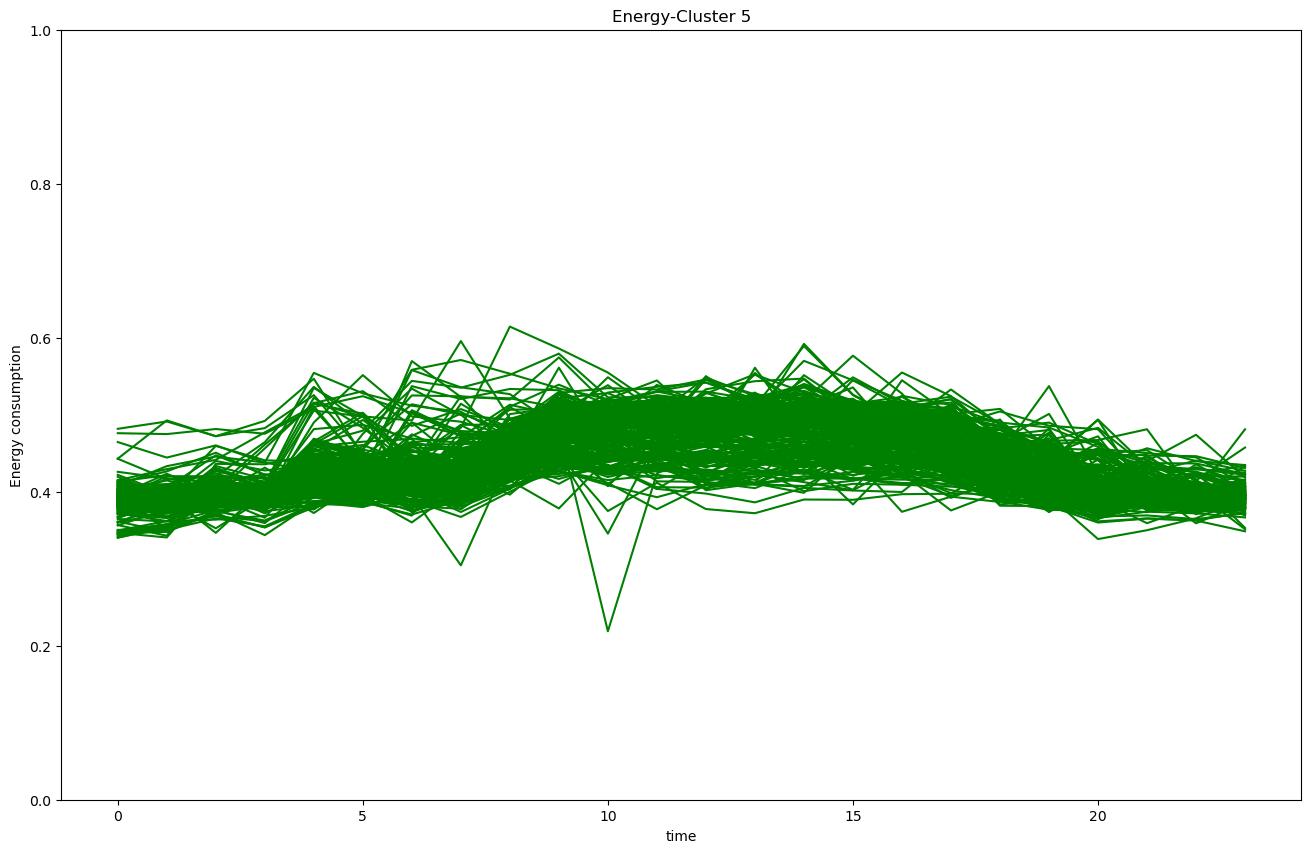

<Figure size 640x480 with 0 Axes>

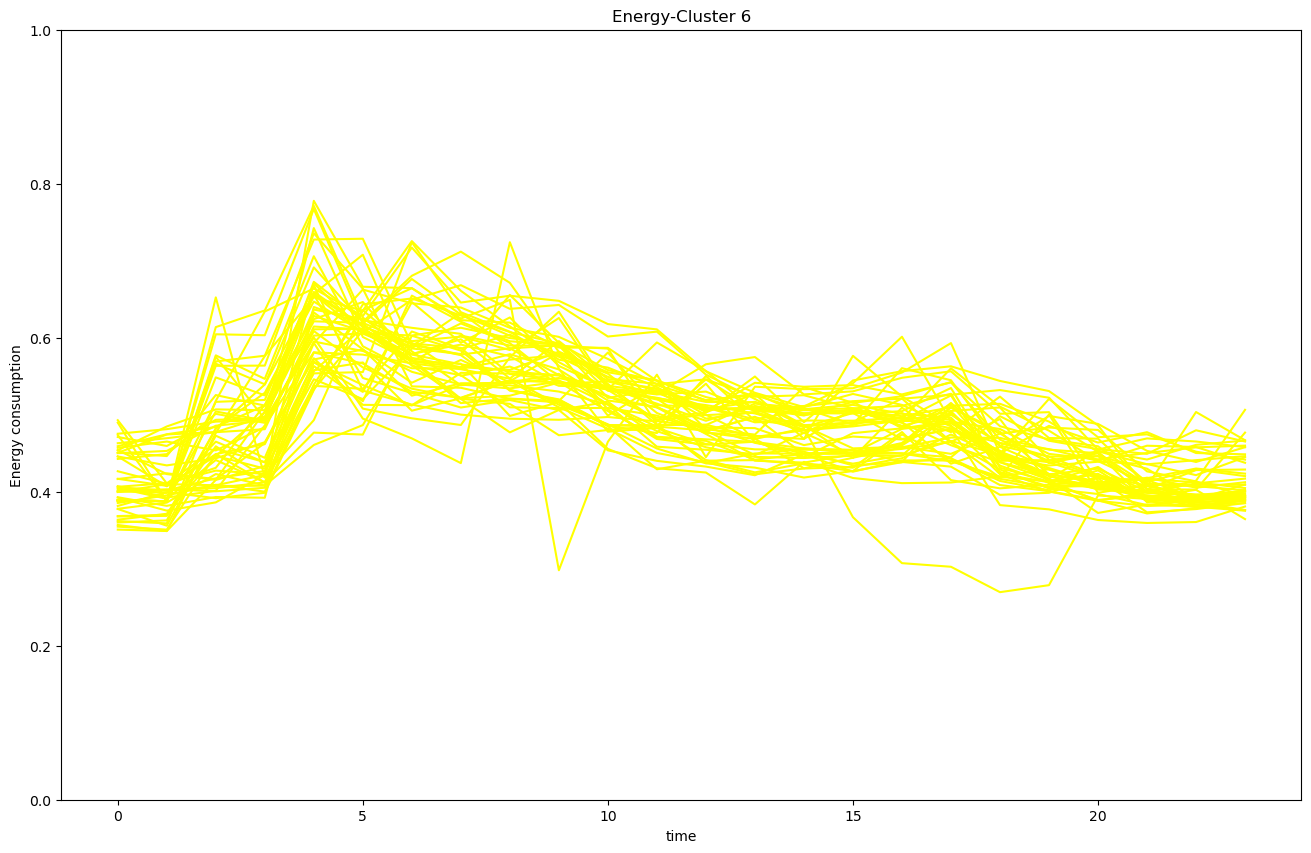

<Figure size 640x480 with 0 Axes>

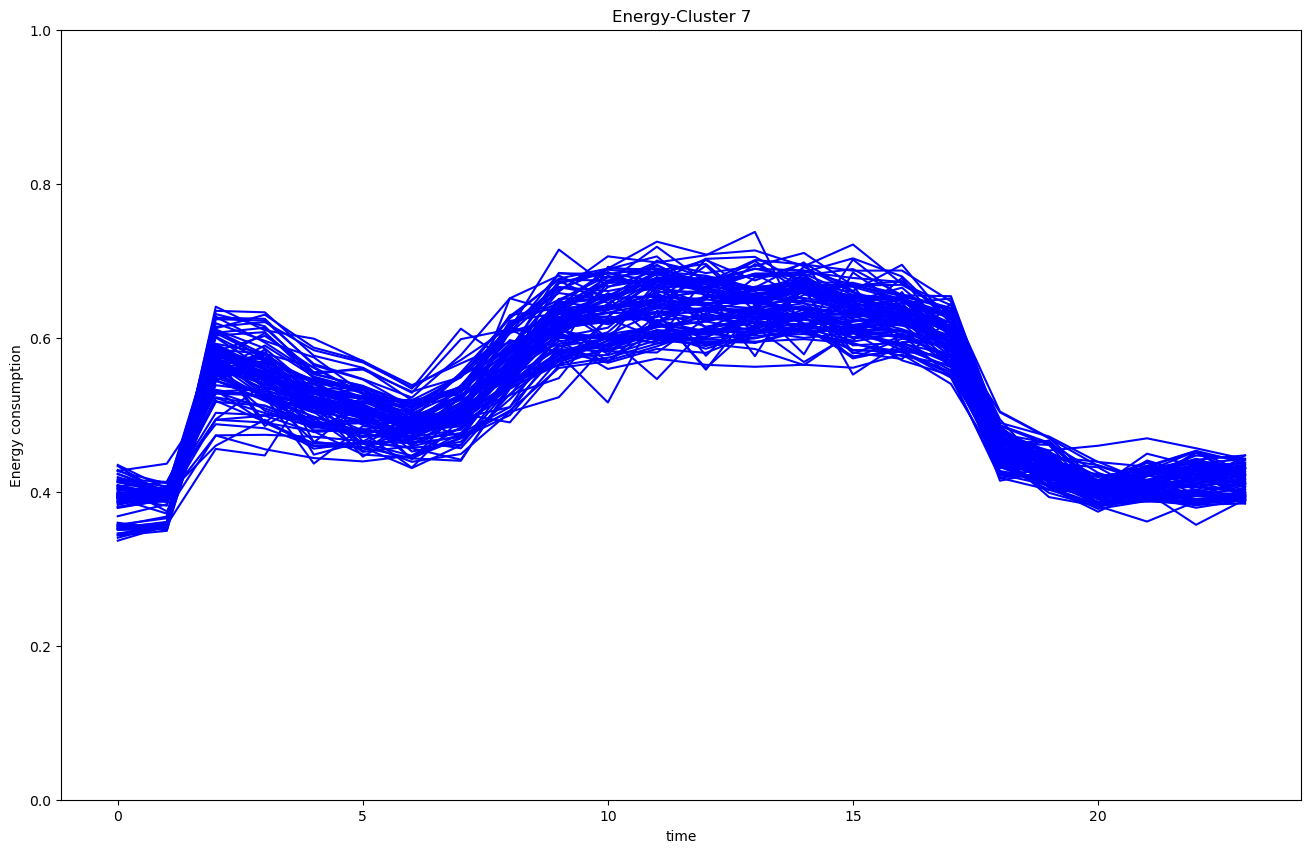

<Figure size 640x480 with 0 Axes>

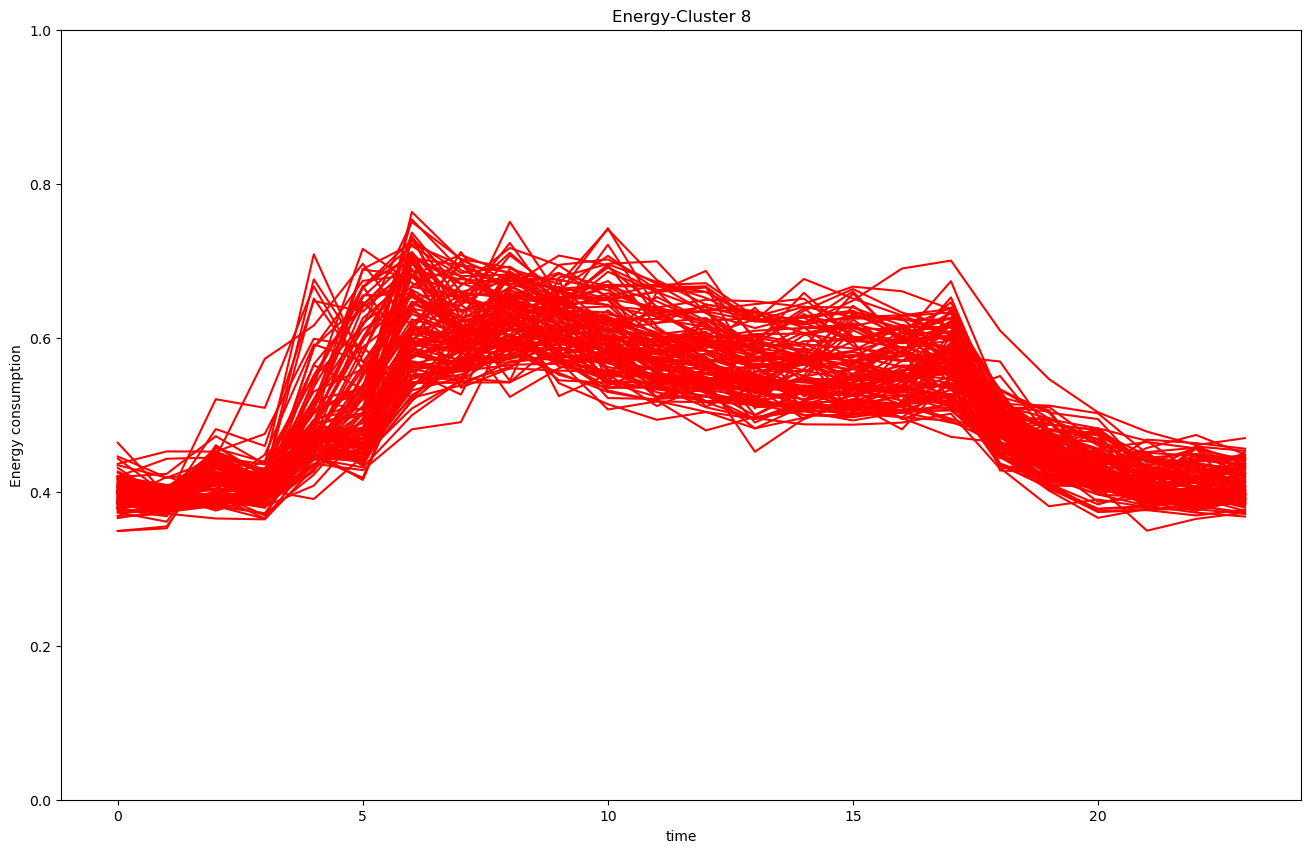

In [61]:
# 8 clusters ['magenta', 'cyan', 'silver', 'black', 'green','yellow', 'blue','red']

plt.figure(figsize=(16, 10))
for i in range(Dayly_Energy_labels1.shape[0]):
    if Dayly_Energy_labels1[i]==0: 
        plt.plot(X_N_clean[i], color = 'magenta') 
        plt.ylim(0, 1)
        plt.xlabel("time") 
        plt.ylabel("Energy consumption")   
        plt.title("Energy-Cluster 1")

plt.figure() 
plt.figure(figsize=(16, 10))
for i in range(Dayly_Energy_labels1.shape[0]): 
    if Dayly_Energy_labels1[i]==1: 
        plt.plot(X_N_clean[i], color = 'cyan') 
        plt.ylim(0, 1)
        plt.xlabel("time") 
        plt.ylabel("Energy consumption")   
        plt.title("Energy-Cluster 2")
       
plt.figure() 
plt.figure(figsize=(16, 10))
for i in range(Dayly_Energy_labels1.shape[0]): 
    if Dayly_Energy_labels1[i]==2: 
        plt.plot(X_N_clean[i], color = 'silver') 
        plt.ylim(0, 1)
        plt.xlabel("time") 
        plt.ylabel("Energy consumption")   
        plt.title("Energy-Cluster 3") 

plt.figure()
plt.figure(figsize=(16, 10))
for i in range(Dayly_Energy_labels1.shape[0]): 
    if Dayly_Energy_labels1[i]==3: 
        plt.plot(X_N_clean[i], color = 'black') 
        plt.ylim(0, 1)
        plt.xlabel("time") 
        plt.ylabel("Energy consumption")   
        plt.title("Energy-Cluster 4")
        
plt.figure()
plt.figure(figsize=(16, 10))
for i in range(Dayly_Energy_labels1.shape[0]): 
    if Dayly_Energy_labels1[i]==4: 
        plt.plot(X_N_clean[i], color = 'green')  
        plt.ylim(0, 1)
        plt.xlabel("time") 
        plt.ylabel("Energy consumption")   
        plt.title("Energy-Cluster 5")
        
plt.figure()
plt.figure(figsize=(16, 10))
for i in range(Dayly_Energy_labels1.shape[0]): 
   if Dayly_Energy_labels1[i]==5: 
       plt.plot(X_N_clean[i], color = 'yellow')  
       plt.ylim(0, 1)
       plt.xlabel("time") 
       plt.ylabel("Energy consumption")   
       plt.title("Energy-Cluster 6")

plt.figure()
plt.figure(figsize=(16, 10))
for i in range(Dayly_Energy_labels1.shape[0]): 
   if Dayly_Energy_labels1[i]==6: 
       plt.plot(X_N_clean[i], color = 'blue') 
       plt.ylim(0, 1)
       plt.xlabel("time") 
       plt.ylabel("Energy consumption")   
       plt.title("Energy-Cluster 7")

plt.figure()
plt.figure(figsize=(16, 10))
for i in range(Dayly_Energy_labels1.shape[0]): 
   if Dayly_Energy_labels1[i]==7: 
       plt.plot(X_N_clean[i], color = 'red') 
       plt.ylim(0, 1)
plt.xlabel("time") 
plt.ylabel("Energy consumption")   
plt.title("Energy-Cluster 8")

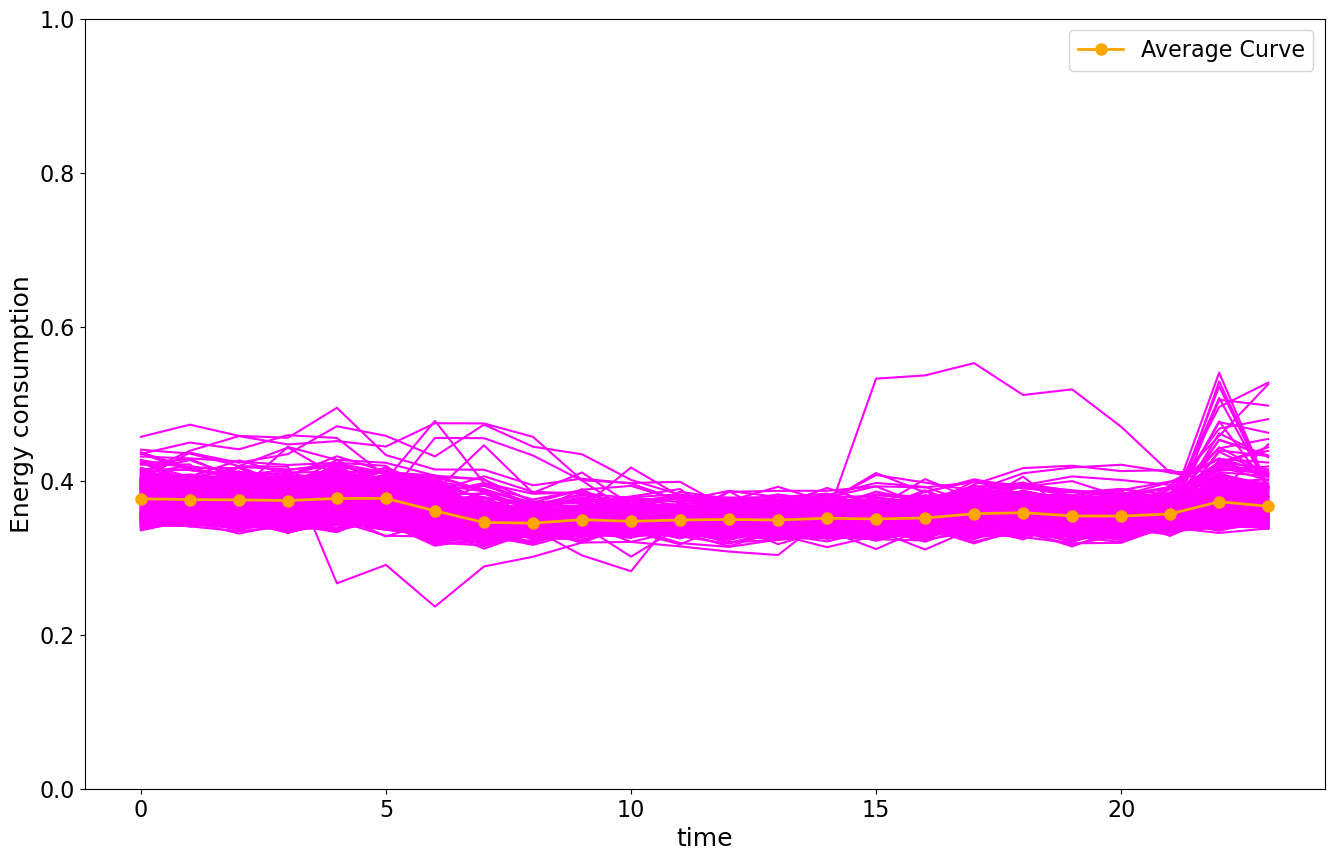

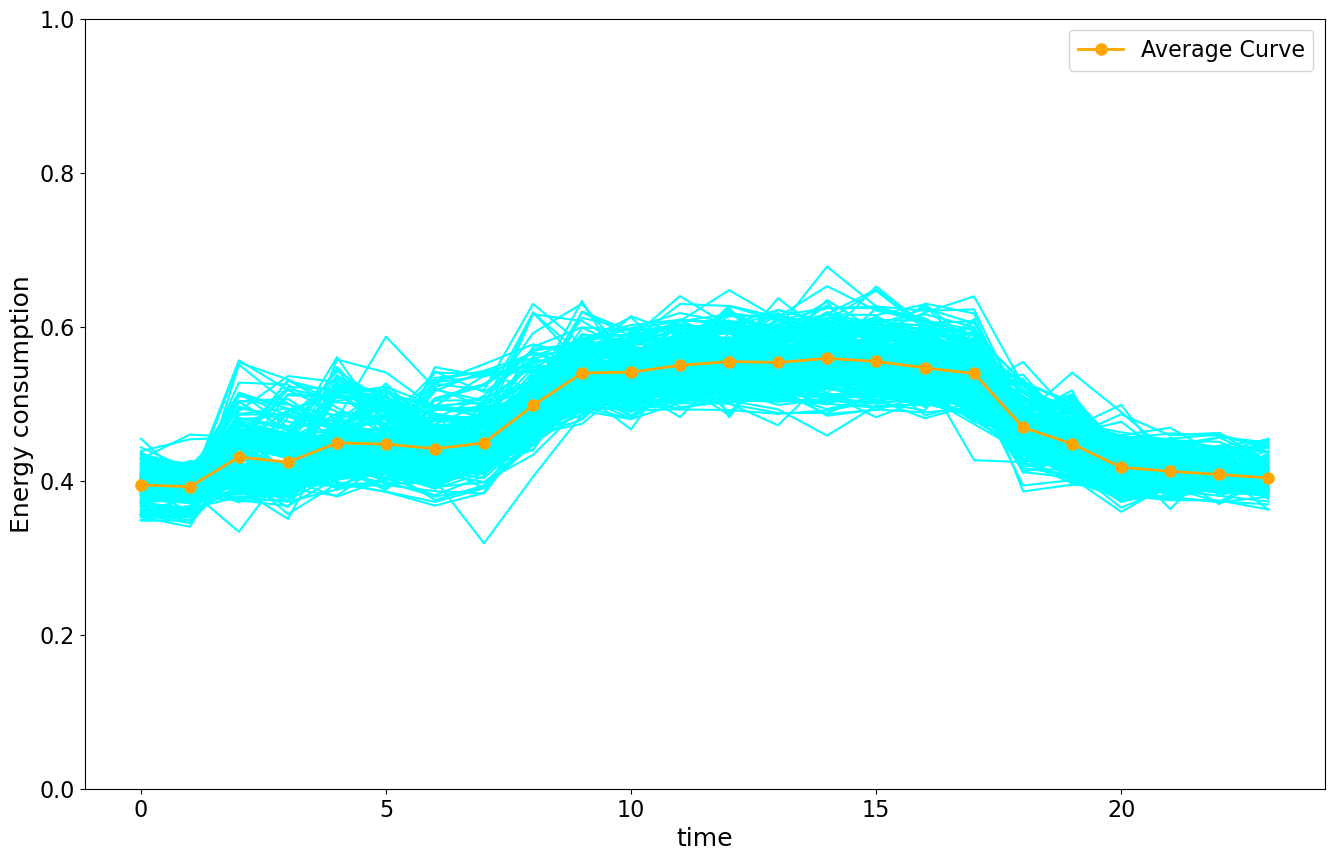

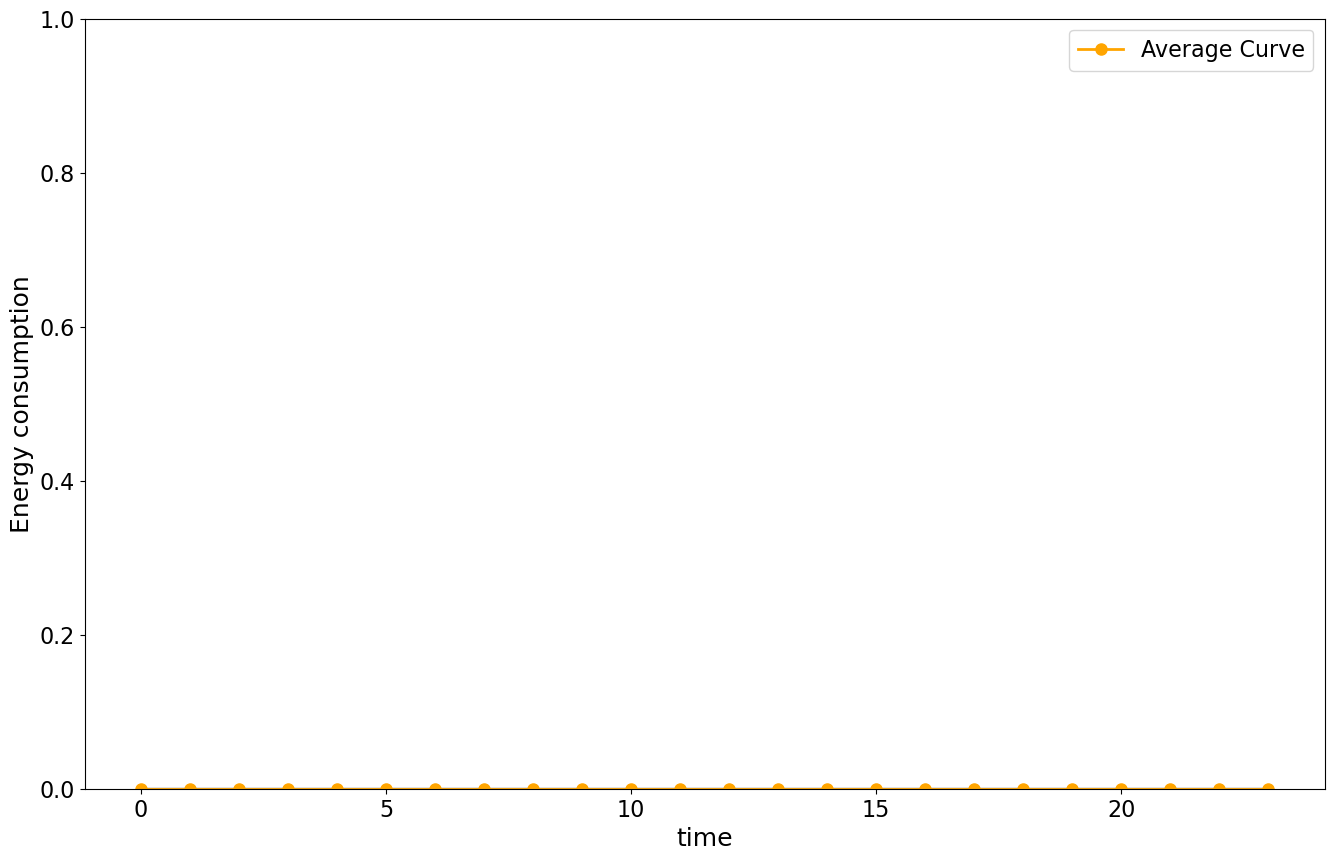

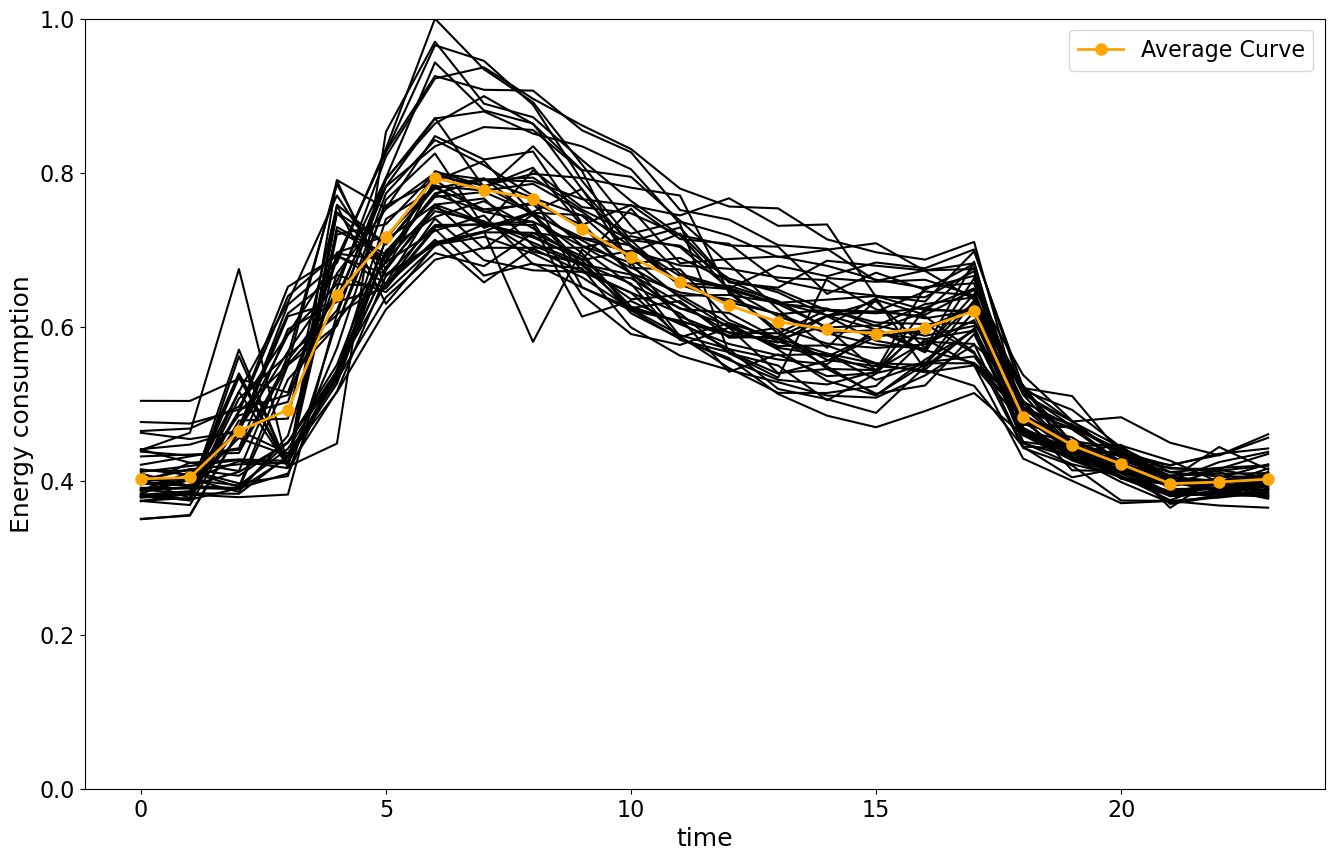

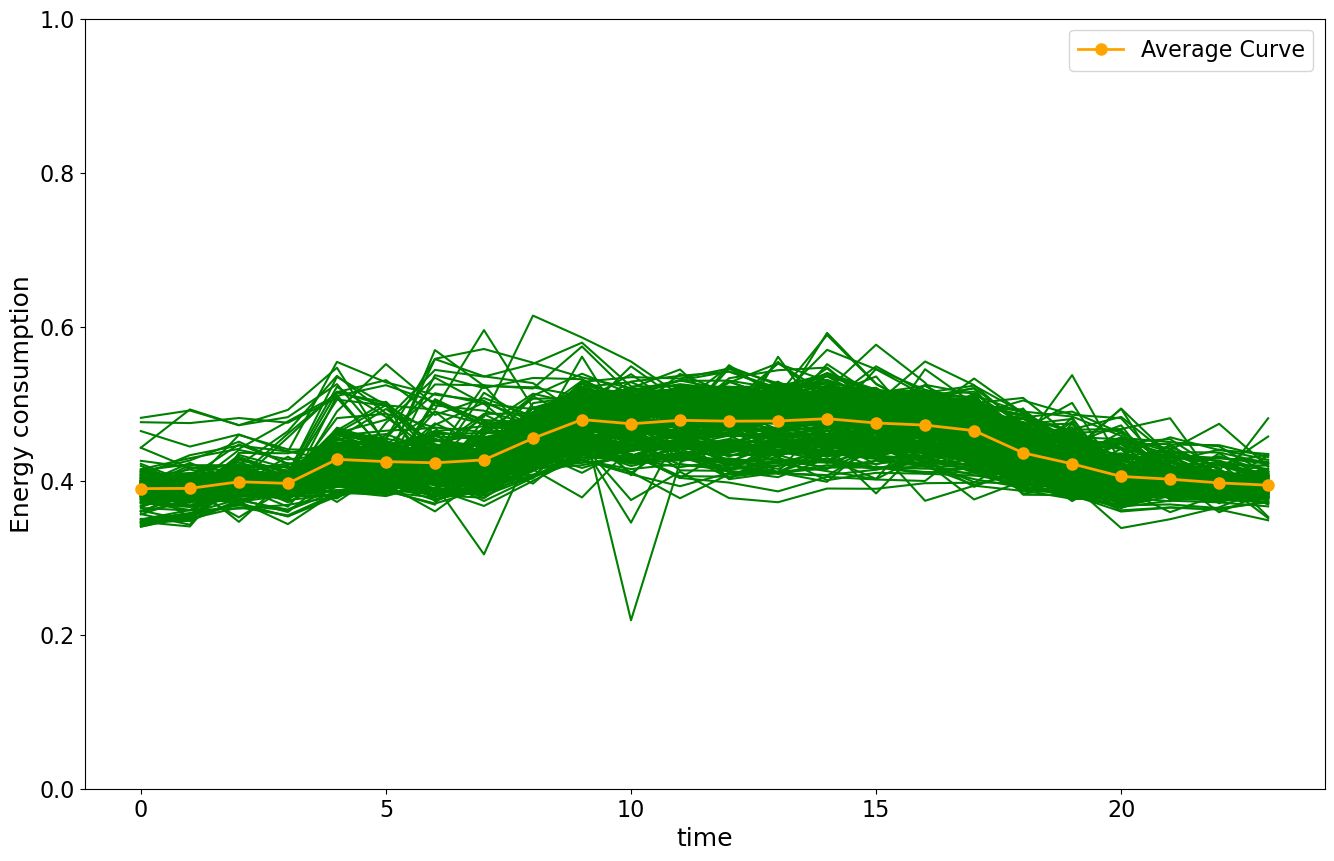

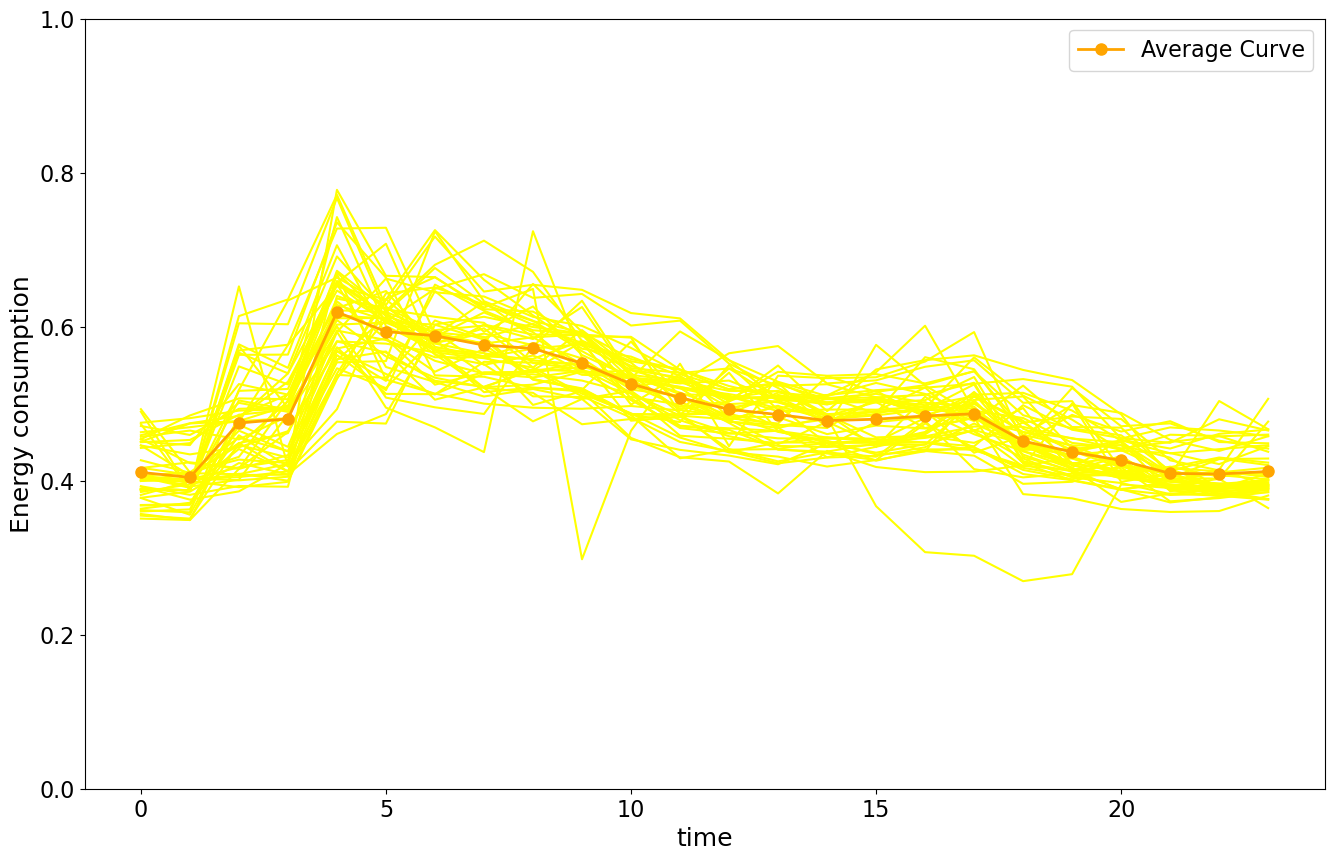

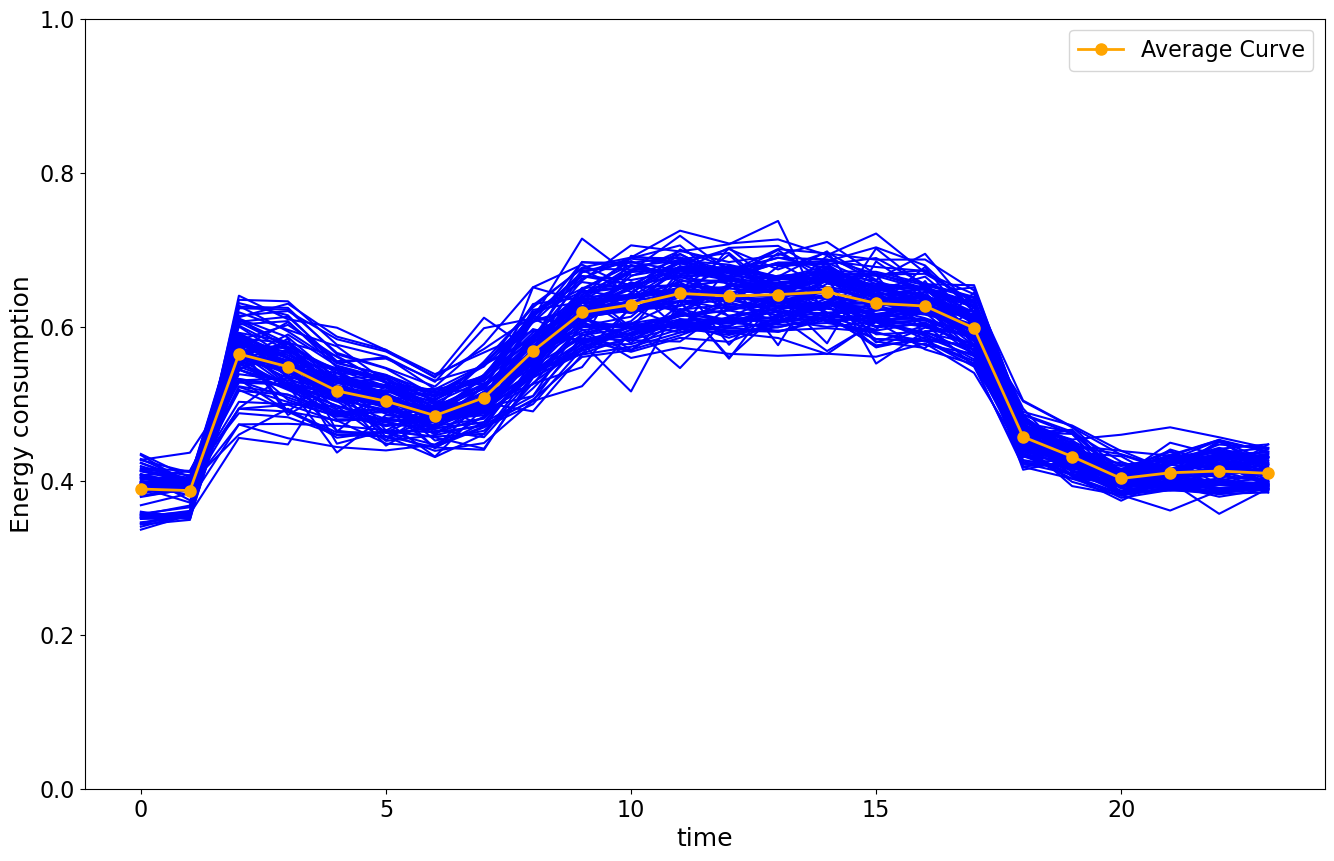

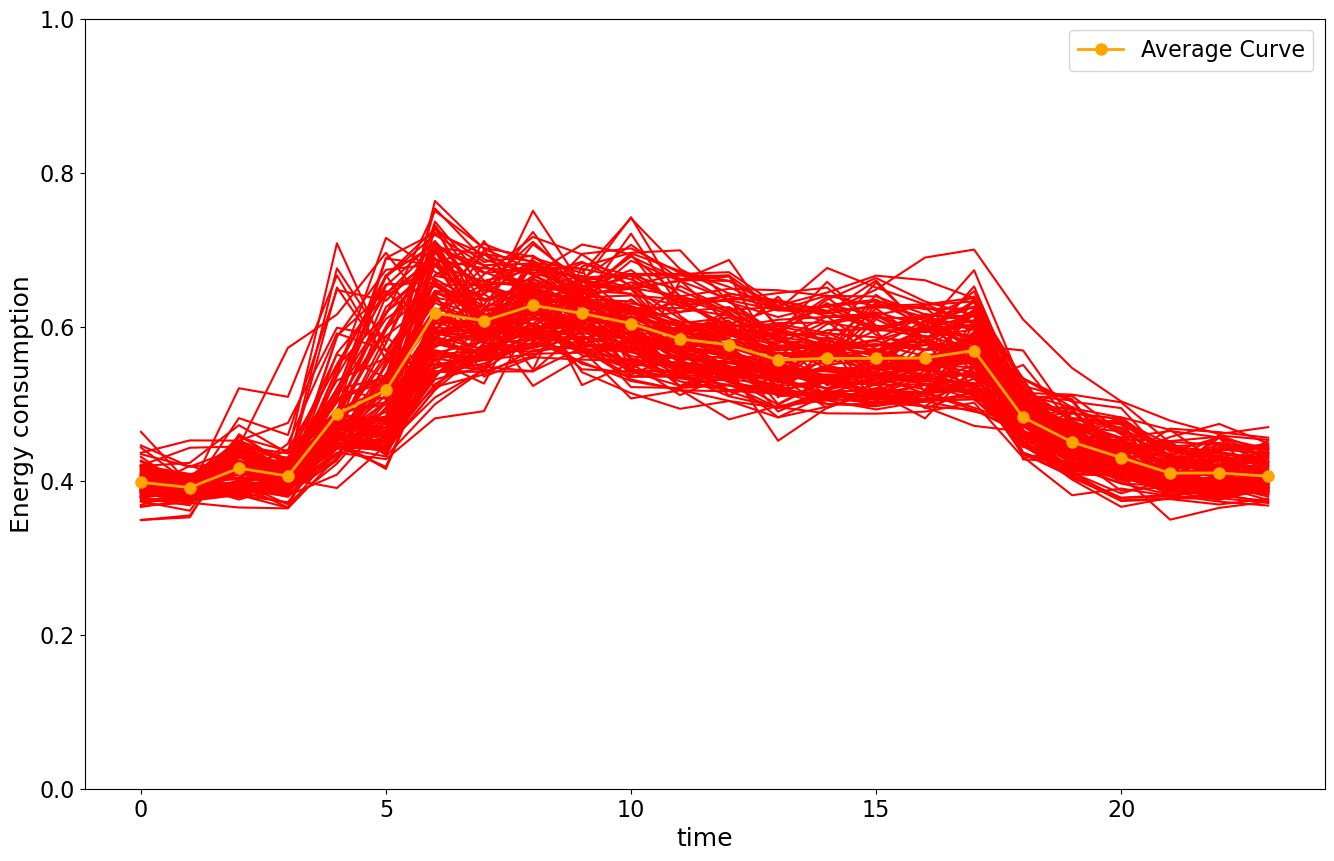

In [63]:
# 8 ['magenta', 'cyan', 'silver', 'black', 'green','yellow', 'blue','red']
plt.figure(figsize=(16, 10))
for i in range(Dayly_Energy_labels1.shape[0]):
    if Dayly_Energy_labels1[i]==0: 
        plt.plot(X_N_clean[i], color = 'magenta') 
        plt.ylim(0, 1)
average_curve = np.mean(X_N_clean[Dayly_Energy_labels1 == 0], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Energy consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()
#plt.title("Energy-Cluster 1")

plt.figure(figsize=(16, 10))
for i in range(Dayly_Energy_labels1.shape[0]): 
    if Dayly_Energy_labels1[i]==1: 
        plt.plot(X_N_clean[i], color = 'cyan') 
        plt.ylim(0, 1)
plt.xlabel("time") 
plt.ylabel("Energy consumption")   
average_curve = np.mean(X_N_clean[Dayly_Energy_labels1 == 1], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Energy consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()
# plt.title("Energy-Cluster 2")
       
plt.figure(figsize=(16, 10))
for i in range(Dayly_Energy_labels1.shape[0]): 
    if Dayly_Energy_labels1[i]==2: 
        plt.plot(X_N_clean[i], color = 'silver') 
        plt.ylim(0, 1)
plt.xlabel("time") 
plt.ylabel("Energy consumption")   
average_curve = np.mean(X_N_clean[Dayly_Energy_labels1 == 2], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in orange with thicker line
# plt.plot(average_curve, color='purple', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Energy consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show() 
# plt.title("Energy-Cluster 3") 

plt.figure(figsize=(16, 10))
for i in range(Dayly_Energy_labels1.shape[0]): 
    if Dayly_Energy_labels1[i]==3: 
        plt.plot(X_N_clean[i], color = 'black') 
        plt.ylim(0, 1)
plt.xlabel("time") 
plt.ylabel("Energy consumption")   
average_curve = np.mean(X_N_clean[Dayly_Energy_labels1 == 3], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in orange with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Energy consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()   
# plt.title("Energy-Cluster 4")
        
plt.figure(figsize=(16, 10))
for i in range(Dayly_Energy_labels1.shape[0]): 
    if Dayly_Energy_labels1[i]==4: 
        plt.plot(X_N_clean[i], color = 'green')  
        plt.ylim(0, 1)
plt.xlabel("time") 
plt.ylabel("Energy consumption")   
average_curve = np.mean(X_N_clean[Dayly_Energy_labels1 == 4], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Energy consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()    
# plt.title("Energy-Cluster 5")
        
plt.figure(figsize=(16, 10))
for i in range(Dayly_Energy_labels1.shape[0]): 
   if Dayly_Energy_labels1[i]==5: 
       plt.plot(X_N_clean[i], color = 'yellow')  
       plt.ylim(0, 1)
plt.xlabel("time") 
plt.ylabel("Energy consumption")   
average_curve = np.mean(X_N_clean[Dayly_Energy_labels1 == 5], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Energy consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()   
# plt.title("Energy-Cluster 6")

plt.figure(figsize=(16, 10))
for i in range(Dayly_Energy_labels1.shape[0]): 
   if Dayly_Energy_labels1[i]==6: 
       plt.plot(X_N_clean[i], color = 'blue') 
       plt.ylim(0, 1)
plt.xlabel("time") 
plt.ylabel("Energy consumption")   
average_curve = np.mean(X_N_clean[Dayly_Energy_labels1 == 6], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Energy consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show() 
# plt.title("Energy-Cluster 7")

plt.figure(figsize=(16, 10))
for i in range(Dayly_Energy_labels1.shape[0]): 
   if Dayly_Energy_labels1[i]==7: 
       plt.plot(X_N_clean[i], color = 'red') 
       plt.ylim(0, 1)
plt.xlabel("time") 
plt.ylabel("Energy consumption")   
average_curve = np.mean(X_N_clean[Dayly_Energy_labels1 == 7], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Energy consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show() 
# # plt.title("Energy-Cluster 8")

In [65]:
dates = pd.date_range(start='2021-01-01', periods=1095, freq='D')
dates = dates.astype(object)

# Concatenate the date column with the original array horizontally
data_with_date = np.hstack((np.expand_dims(dates, axis=1), X_clean))
Data_with_date_normalize = np.hstack((np.expand_dims(dates, axis=1), X_N_clean))
DF_N=pd.DataFrame(Data_with_date_normalize)
DF_=pd.DataFrame(data_with_date)
DF_
# df = pd.DataFrame(data_with_date)
# df1= df.drop(df[df[0]=='2021-04-19'].index[0])
# df1=df1.drop(df1[df1[0]=='2021-04-20'].index[0])
# df1=df1.drop(df1[df1[0]=='2021-06-04'].index[0])
# df1=df1.drop(df1[df1[0]=='2021-12-31'].index[0])
# df1=df1.drop(df1[df1[0]=='2022-02-03'].index[0])
# df1=df1.drop(df1[df1[0]=='2022-07-13'].index[0])
# df1=df1.drop(df1[df1[0]=='2022-12-31'].index[0])
# Df1=df1
# Df1['Cluster_energy'] = Dayly_Energy_labels
# Df1

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,2021-01-01,79.611,75.265,80.789,102.531,128.606,128.73,118.224,104.632,102.867,...,85.69,85.741,87.328,89.711,77.376,99.209,72.159,74.974,69.766,70.948
1,2021-01-02,69.962,73.02,70.218,72.306,74.018,64.712,61.899,62.091,58.56,...,52.897,54.954,58.658,60.534,59.771,59.198,57.344,60.354,58.768,59.6
2,2021-01-03,69.53408,59.15,58.344,60.697,61.886,61.979,62.184,61.617,64.864,...,56.22,58.109,62.138,62.949,60.646,61.431,58.621,57.868,106.823,70.320659
3,2021-01-04,69.53408,69.288499,116.742,109.607,140.845,154.348,116.057,112.742,101.682,...,90.751,119.438,105.397,95.399,78.559,72.612,69.41,67.629,68.096,68.6
4,2021-01-05,70.638,67.675,70.717,70.464,134.422,121.67,105.697,109.976,110.059,...,108.767,109.349,106.13,110.279,95.155,90.572,88.229,75.984,80.205,77.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,2023-12-27,63.145,62.267,69.615,66.857,82.587,72.474,100.684,92.822,91.832,...,82.489,81.456,89.704,84.833,67.715,67.557,61.908,63.283,62.587,58.888
1091,2023-12-28,66.756,64.903,69.506,66.172,76.288,71.869,99.761,93.442,81.087,...,76.603,84.042,80.45,86.02,69.971,67.359,64.013,64.357,63.099,65.096
1092,2023-12-29,65.266,63.817,71.869,66.487,80.403,73.877,100.184,91.857,94.036,...,84.643,85.735,93.618,95.734,76.005,70.521,63.466,65.641,65.08,63.677
1093,2023-12-30,63.689,64.856,65.663,66.837,67.027,64.473,61.911,60.241,57.165,...,56.761,55.865,55.027,58.279,63.192,57.845,59.871,57.718,57.239,58.284


In [67]:
DF_['Cluster_energy'] = Dayly_Energy_labels1
DF_N['Cluster_energy'] = Dayly_Energy_labels1
DF_[DF_['Cluster_energy']==6]

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,Cluster_energy
626,2022-09-19,59.714,61.103,87.317,85.064,111.266,89.799,89.329,91.431,112.312,...,125.628,132.417,122.206,89.757,80.346,75.287,73.385,69.916,69.437,6
860,2023-05-11,71.526,73.043,111.11,116.972,111.267,106.543,103.218,106.876,121.919,...,143.69,143.97,134.551,96.326,91.608,82.796,81.196,78.084,71.656,6
861,2023-05-12,64.087,68.211,114.316,112.219,104.523,100.349,93.627,95.826,114.221,...,133.859,130.444,129.733,92.777,85.376,67.334,71.909,77.163,80.68,6
864,2023-05-15,57.554,61.294,115.142,112.282,106.207,105.072,95.262,103.155,116.988,...,141.341,132.606,121.523,87.306,83.621,75.766,72.482,72.666,75.245,6
865,2023-05-16,73.326,71.541,111.044,103.882,96.177,97.567,83.921,92.721,111.713,...,136.009,131.33,122.55,76.34,79.721,75.498,78.721,85.032,83.891,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004,2023-10-02,57.441,59.027,123.517,114.821,107.039,102.23,94.974,101.728,111.494,...,144.658,140.535,135.977,86.033,82.4,80.98,71.72,69.889,70.035,6
1005,2023-10-03,69.559,70.262,114.666,104.821,100.469,97.067,93.178,98.543,116.855,...,141.877,150.87,130.784,89.473,80.736,76.715,80.273,83.065,80.594,6
1006,2023-10-04,73.27,72.524,111.967,105.627,98.327,93.086,80.845,97.811,114.826,...,153.093,146.849,130.782,94.746,81.809,72.948,74.701,81.053,78.01,6
1007,2023-10-05,74.42,69.867,114.629,100.485,94.624,96.738,93.313,96.262,105.984,...,136.473,133.558,124.671,84.865,79.489,72.957,71.179,73.331,70.05,6


In [69]:
consumption_cl1=DF_[DF_["Cluster_energy"]==0] 
consumption_cl1=consumption_cl1.drop('Cluster_energy', axis=1)
consumption_cl1_df=consumption_cl1
consumption_cl1=consumption_cl1.drop(0, axis=1) 
consumption_cl1=consumption_cl1.values

consumption_cl2=DF_[DF_["Cluster_energy"]==1] 
consumption_cl2=consumption_cl2.drop('Cluster_energy', axis=1)
consumption_cl2_df=consumption_cl2
consumption_cl2=consumption_cl2.drop(0, axis=1) 
consumption_cl2=consumption_cl2.values

consumption_cl3=DF_[DF_["Cluster_energy"]==3] 
consumption_cl3=consumption_cl3.drop('Cluster_energy', axis=1)
consumption_cl3_df=consumption_cl3
consumption_cl3=consumption_cl3.drop(0, axis=1) 
consumption_cl3=consumption_cl3.values

consumption_cl4=DF_[DF_["Cluster_energy"]==4] 
consumption_cl4=consumption_cl4.drop('Cluster_energy', axis=1)
consumption_cl4_df=consumption_cl4
consumption_cl4=consumption_cl4.drop(0, axis=1) 
consumption_cl4=consumption_cl4.values

consumption_cl5=DF_[DF_["Cluster_energy"]==5] 
consumption_cl5=consumption_cl5.drop('Cluster_energy', axis=1)
consumption_cl5_df=consumption_cl5
consumption_cl5=consumption_cl5.drop(0, axis=1) 
consumption_cl5=consumption_cl5.values

consumption_cl6=DF_[DF_["Cluster_energy"]==6] 
consumption_cl6=consumption_cl6.drop('Cluster_energy', axis=1)
consumption_cl6_df=consumption_cl6
consumption_cl6=consumption_cl6.drop(0, axis=1) 
consumption_cl6=consumption_cl6.values

consumption_cl7=DF_[DF_["Cluster_energy"]==7] 
consumption_cl7=consumption_cl7.drop('Cluster_energy', axis=1)
consumption_cl7_df=consumption_cl7
consumption_cl7=consumption_cl7.drop(0, axis=1) 
consumption_cl7=consumption_cl7.values
consumption_cl7_df

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
11,2021-01-12,82.188,86.462,86.381,92.493,125.349,122.205,109.121,119.039,118.381,...,119.02,116.221,110.34,116.479,107.817,99.84,97.616,79.295,88.149,86.657
332,2021-11-29,69.53408,69.288499,104.467,101.498,143.44,114.286,108.755,123.052,147.043,...,123.53,116.589,107.49,109.876,98.569,97.555,94.376,80.758,75.586,74.494
333,2021-11-30,73.614,72.769,73.02,85.332,123.399,117.597,104.93,109.244,117.552,...,116.306,117.319,112.142,114.776,98.414,87.727,84.762,73.34,73.585,72.685
339,2021-12-06,77.81,83.923,84.352,118.409,129.923,151.216,129.381,121.05,130.381,...,112.587,133.701,129.002,132.562,95.634,82.397,86.442,73.261,71.917,73.022
340,2021-12-07,72.256,72.323,71.603,71.854,122.539,138.018,121.667,115.836,126.648,...,130.67,138.532,149.574,152.321,128.204,111.436,99.939,93.275,88.635,91.041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1081,2023-12-18,58.966,60.578,84.5,81.967,154.486,117.274,140.635,129.908,132.195,...,119.716,115.399,106.865,106.272,85.042,72.943,63.535,66.674,67.593,65.438
1082,2023-12-19,66.384,65.608,81.07,74.313,97.477,101.44,159.776,132.605,138.624,...,103.948,116.521,122.548,118.081,84.891,80.32,72.773,74.011,78.154,75.844
1083,2023-12-20,69.703,65.64,80.524,75.21,93.429,85.939,123.984,128.304,130.387,...,116.942,109.371,111.311,105.527,85.97,74.691,76.911,72.939,69.0,69.91
1084,2023-12-21,72.387,68.187,71.557,71.11,86.262,76.618,115.895,117.906,117.074,...,106.396,112.66,111.641,113.324,80.78,67.53,69.846,67.198,70.653,65.882


In [71]:
consumption_cl1_N=DF_N[DF_N["Cluster_energy"]==0] 
consumption_cl1_N=consumption_cl1_N.drop('Cluster_energy', axis=1)
consumption_cl1_df_N=consumption_cl1_N
consumption_cl1_N=consumption_cl1_N.drop(0, axis=1) 
consumption_cl1_N=consumption_cl1_N.values

consumption_cl2_N=DF_N[DF_N["Cluster_energy"]==1] 
consumption_cl2_N=consumption_cl2_N.drop('Cluster_energy', axis=1)
consumption_cl2_df_N=consumption_cl2_N
consumption_cl2_N=consumption_cl2_N.drop(0, axis=1) 
consumption_cl2_N=consumption_cl2_N.values

consumption_cl3_N=DF_N[DF_N["Cluster_energy"]==3] 
consumption_cl3_N=consumption_cl3_N.drop('Cluster_energy', axis=1)
consumption_cl3_N_df=consumption_cl3_N
consumption_cl3_N=consumption_cl3_N.drop(0, axis=1) 
consumption_cl3_N=consumption_cl3_N.values

consumption_cl4_N=DF_N[DF_N["Cluster_energy"]==4] 
consumption_cl4_N=consumption_cl4_N.drop('Cluster_energy', axis=1)
consumption_cl4_N_df=consumption_cl4_N
consumption_cl4_N=consumption_cl4_N.drop(0, axis=1) 
consumption_cl4_N=consumption_cl4_N.values

consumption_cl5_N=DF_N[DF_N["Cluster_energy"]==5] 
consumption_cl5_N=consumption_cl5_N.drop('Cluster_energy', axis=1)
consumption_cl5_N_df=consumption_cl5_N
consumption_cl5_N=consumption_cl5_N.drop(0, axis=1) 
consumption_cl5_N=consumption_cl5_N.values

consumption_cl6_N=DF_N[DF_N["Cluster_energy"]==6] 
consumption_cl6_N=consumption_cl6_N.drop('Cluster_energy', axis=1)
consumption_cl6_N_df=consumption_cl6_N
consumption_cl6_N=consumption_cl6_N.drop(0, axis=1) 
consumption_cl6_N=consumption_cl6_N.values

consumption_cl7_N=DF_N[DF_N["Cluster_energy"]==7] 
consumption_cl7_N=consumption_cl7_N.drop('Cluster_energy', axis=1)
consumption_cl7_N_df=consumption_cl7_N
consumption_cl7_N=consumption_cl7_N.drop(0, axis=1) 
consumption_cl7_N=consumption_cl7_N.values

consumption_cl7_N_df

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
11,2021-01-12,0.43629,0.452371,0.452066,0.475063,0.598688,0.586858,0.537628,0.574946,0.57247,...,0.574874,0.564343,0.542215,0.565313,0.532722,0.502707,0.494339,0.425404,0.458719,0.453105
332,2021-11-29,0.388678,0.387754,0.520117,0.508946,0.666757,0.557062,0.536251,0.590045,0.680314,...,0.591843,0.565727,0.531491,0.540469,0.497925,0.49411,0.482148,0.430909,0.411449,0.40734
333,2021-11-30,0.404029,0.40085,0.401794,0.448119,0.591351,0.56952,0.521859,0.538091,0.569351,...,0.564662,0.568474,0.548995,0.558906,0.497342,0.457131,0.445975,0.402998,0.40392,0.400534
339,2021-12-06,0.419817,0.442818,0.444432,0.572575,0.615898,0.696015,0.613858,0.582512,0.617621,...,0.550669,0.630113,0.612432,0.625827,0.486882,0.437076,0.452296,0.402701,0.397644,0.401802
340,2021-12-07,0.398919,0.399171,0.396462,0.397407,0.588115,0.646356,0.584834,0.562894,0.603575,...,0.618708,0.64829,0.689837,0.700173,0.60943,0.546338,0.50308,0.478006,0.460547,0.4696
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1081,2023-12-18,0.348914,0.35498,0.444989,0.435458,0.708319,0.568305,0.656203,0.615841,0.624446,...,0.577493,0.56125,0.52914,0.526908,0.447028,0.401504,0.366106,0.377916,0.381374,0.373266
1082,2023-12-19,0.376825,0.373906,0.432083,0.406659,0.493816,0.508727,0.728223,0.625989,0.648636,...,0.518164,0.565471,0.588149,0.571341,0.44646,0.429261,0.400865,0.405523,0.421111,0.41242
1083,2023-12-20,0.389313,0.374026,0.430029,0.410034,0.478585,0.450403,0.593552,0.609806,0.617644,...,0.567055,0.538569,0.545868,0.524105,0.45052,0.408081,0.416434,0.401489,0.386668,0.390092
1084,2023-12-21,0.399412,0.383609,0.396289,0.394607,0.451618,0.415332,0.563116,0.570682,0.567552,...,0.527375,0.550944,0.54711,0.553442,0.430992,0.381137,0.389851,0.379888,0.392888,0.374937


In [73]:
Temprature_cluster=pd.DataFrame(Temp_2)
Temprature_cluster['Cluster_energy'] = Dayly_Energy_labels1

Temp_cl1=Temprature_cluster[Temprature_cluster["Cluster_energy"]==0]
Temp_cl1=Temp_cl1.drop('Cluster_energy', axis=1)
Temp_cl1=Temp_cl1.values

Temp_cl2=Temprature_cluster[Temprature_cluster["Cluster_energy"]==1]
Temp_cl2=Temp_cl2.drop('Cluster_energy', axis=1)
Temp_cl2=Temp_cl2.values

Temp_cl3=Temprature_cluster[Temprature_cluster["Cluster_energy"]==3]
Temp_cl3=Temp_cl3.drop('Cluster_energy', axis=1)
Temp_cl3=Temp_cl3.values

Temp_cl4=Temprature_cluster[Temprature_cluster["Cluster_energy"]==4]
Temp_cl4=Temp_cl4.drop('Cluster_energy', axis=1)
Temp_cl4=Temp_cl4.values

Temp_cl5=Temprature_cluster[Temprature_cluster["Cluster_energy"]==5]
Temp_cl5=Temp_cl5.drop('Cluster_energy', axis=1)
Temp_cl5=Temp_cl5.values

Temp_cl6=Temprature_cluster[Temprature_cluster["Cluster_energy"]==6]
Temp_cl6=Temp_cl6.drop('Cluster_energy', axis=1)
Temp_cl6=Temp_cl6.values

Temp_cl7=Temprature_cluster[Temprature_cluster["Cluster_energy"]==7]
Temp_cl7=Temp_cl7.drop('Cluster_energy', axis=1)
Temp_cl7=Temp_cl7.values
Temp_cl4.shape

(224, 24)

In [75]:
Temp_cl8=Temprature_cluster[Temprature_cluster["Cluster_energy"]==2]
Temp_cl8=Temp_cl8.drop('Cluster_energy', axis=1)
Temp_cl8=Temp_cl8.values
Temp_cl8.shape

(12, 24)

In [77]:
PK_Rad=Radiation_2/504
Total_Radiation_cluster=pd.DataFrame(PK_Rad)
Total_Radiation_cluster['Cluster_energy'] = Dayly_Energy_labels1

Total_Rad_cl1=Total_Radiation_cluster[Total_Radiation_cluster["Cluster_energy"]==0]
Total_Rad_cl1=Total_Rad_cl1.drop('Cluster_energy', axis=1)
Total_Rad_cl1=Total_Rad_cl1.values

Total_Rad_cl2=Total_Radiation_cluster[Total_Radiation_cluster["Cluster_energy"]==1]
Total_Rad_cl2=Total_Rad_cl2.drop('Cluster_energy', axis=1)
Total_Rad_cl2=Total_Rad_cl2.values

Total_Rad_cl3=Total_Radiation_cluster[Total_Radiation_cluster["Cluster_energy"]==3]
Total_Rad_cl3=Total_Rad_cl3.drop('Cluster_energy', axis=1)
Total_Rad_cl3=Total_Rad_cl3.values

Total_Rad_cl4=Total_Radiation_cluster[Total_Radiation_cluster["Cluster_energy"]==4]
Total_Rad_cl4=Total_Rad_cl4.drop('Cluster_energy', axis=1)
Total_Rad_cl4=Total_Rad_cl4.values

Total_Rad_cl5=Total_Radiation_cluster[Total_Radiation_cluster["Cluster_energy"]==5]
Total_Rad_cl5=Total_Rad_cl5.drop('Cluster_energy', axis=1)
Total_Rad_cl5=Total_Rad_cl5.values

Total_Rad_cl6=Total_Radiation_cluster[Total_Radiation_cluster["Cluster_energy"]==6]
Total_Rad_cl6=Total_Rad_cl6.drop('Cluster_energy', axis=1)
Total_Rad_cl6=Total_Rad_cl6.values

Total_Rad_cl7=Total_Radiation_cluster[Total_Radiation_cluster["Cluster_energy"]==7]
Total_Rad_cl7=Total_Rad_cl7.drop('Cluster_energy', axis=1)
Total_Rad_cl7=Total_Rad_cl7.values
Total_Rad_cl7.shape

(125, 24)

In [79]:
Total_Radiation_cluster[Total_Radiation_cluster["Cluster_energy"]==7]

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,Cluster_energy
11,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000405,0.006127,...,0.004754,0.000381,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
332,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.001048,...,0.000008,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
333,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
339,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
340,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1081,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000524,0.008587,0.037516,...,0.004286,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
1082,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.008183,0.040849,0.186571,...,0.021452,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
1083,0.0,0.0,0.0,0.0,0.0,0.0,0.000056,0.050079,0.175841,0.280159,...,0.001865,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
1084,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.002992,0.026000,0.060063,...,0.001603,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7


In [81]:
# #
# Radiation_cluster=pd.DataFrame(GHI)
# Radiation_cluster['Cluster_energy'] = Dayly_Energy_labels1

# Rad_cl1=Radiation_cluster[Radiation_cluster["Cluster_energy"]==0]
# Rad_cl1=Rad_cl1.drop('Cluster_energy', axis=1)
# Rad_cl1=Rad_cl1.values

# Rad_cl2=Radiation_cluster[Radiation_cluster["Cluster_energy"]==1]
# Rad_cl2=Rad_cl2.drop('Cluster_energy', axis=1)
# Rad_cl2=Rad_cl2.values

# Rad_cl3=Radiation_cluster[Radiation_cluster["Cluster_energy"]==3]
# Rad_cl3=Rad_cl3.drop('Cluster_energy', axis=1)
# Rad_cl3=Rad_cl3.values

# Rad_cl4=Radiation_cluster[Radiation_cluster["Cluster_energy"]==4]
# Rad_cl4=Rad_cl4.drop('Cluster_energy', axis=1)
# Rad_cl4=Rad_cl4.values

# Rad_cl5=Radiation_cluster[Radiation_cluster["Cluster_energy"]==5]
# Rad_cl5=Rad_cl5.drop('Cluster_energy', axis=1)
# Rad_cl5=Rad_cl5.values

# Rad_cl6=Radiation_cluster[Radiation_cluster["Cluster_energy"]==6]
# Rad_cl6=Rad_cl6.drop('Cluster_energy', axis=1)
# Rad_cl6=Rad_cl6.values

# Rad_cl7=Radiation_cluster[Radiation_cluster["Cluster_energy"]==7]
# Rad_cl7=Rad_cl7.drop('Cluster_energy', axis=1)
# Rad_cl7=Rad_cl7.values



# Rad_cl5.shape

In [83]:
import calmap

all_days = pd.date_range('01/01/2021', periods=X_clean.shape[0], freq='D')
days = np.random.choice(all_days, 1095)
#events = pd.Series(Dayly_Energy_labels, index=all_days)
# events = pd.Series(df1["Cluster_energy"].values, index=df1[0])
events1 = pd.Series(DF_["Cluster_energy"].values, index=DF_[0])
events1

0
2021-01-01    5
2021-01-02    0
2021-01-03    0
2021-01-04    5
2021-01-05    5
             ..
2023-12-27    4
2023-12-28    4
2023-12-29    4
2023-12-30    0
2023-12-31    2
Length: 1095, dtype: int32

In [85]:
# plt.figure(figsize=(16, 10))
# calmap.yearplot(events1, year=2021)

# plt.figure()
# plt.figure(figsize=(16, 10))
# calmap.yearplot(events1, year=2022)

# plt.figure()
# plt.figure(figsize=(16, 10))
# calmap.yearplot(events1, year=2023)

C:\Users\User\anaconda3\Lib\site-packages\calmap\__init__.py:151: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  by_day = data.groupby(level=0).agg(how).squeeze()
C:\Users\User\anaconda3\Lib\site-packages\calmap\__init__.py:151: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  by_day = data.groupby(level=0).agg(how).squeeze()
C:\Users\User\anaconda3\Lib\site-packages\calmap\__init__.py:151: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  

Text(0.5, 1.0, 'Energy profile of  2023')

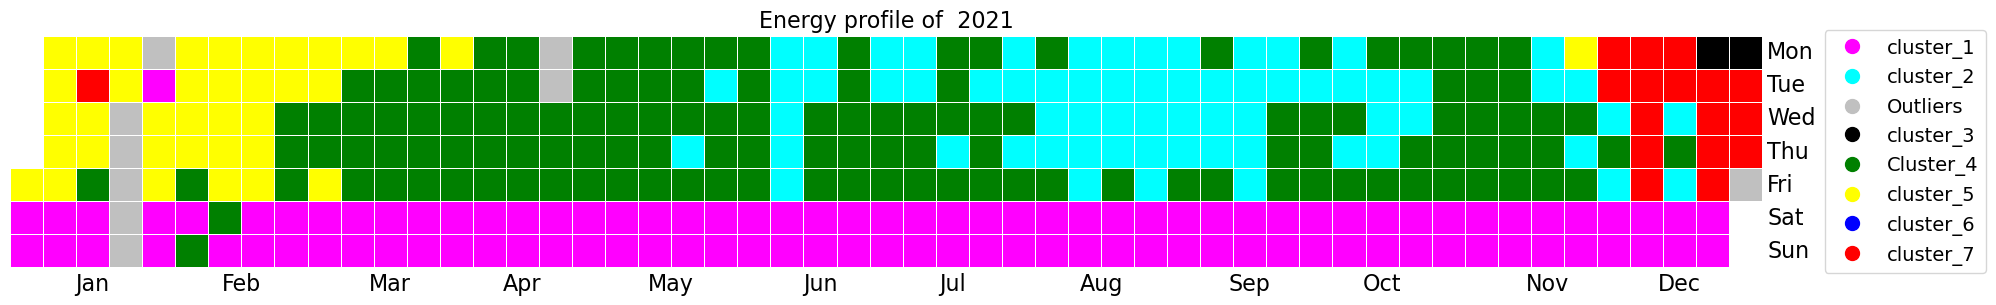

<Figure size 640x480 with 0 Axes>

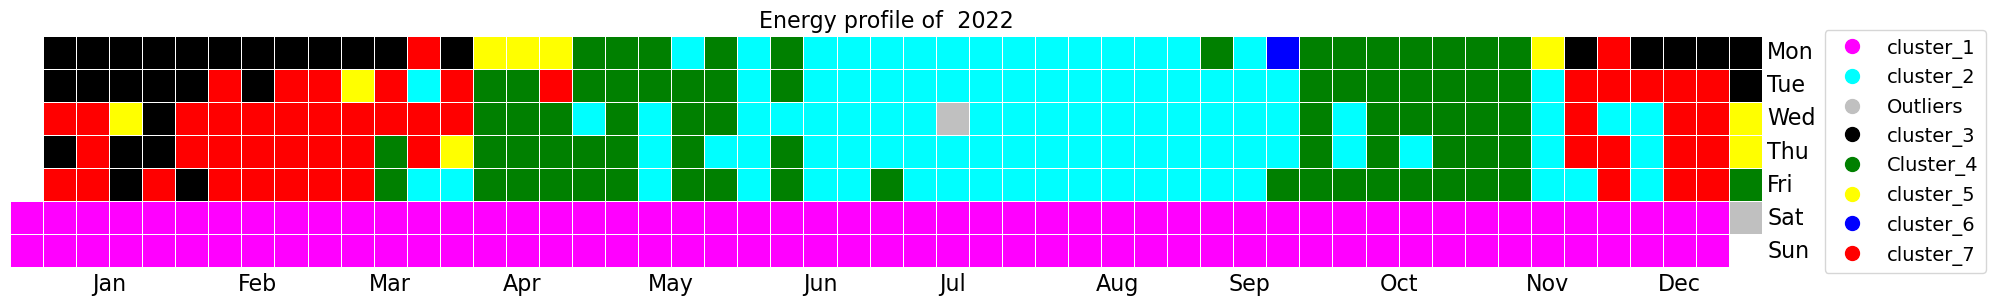

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 2400x1600 with 0 Axes>

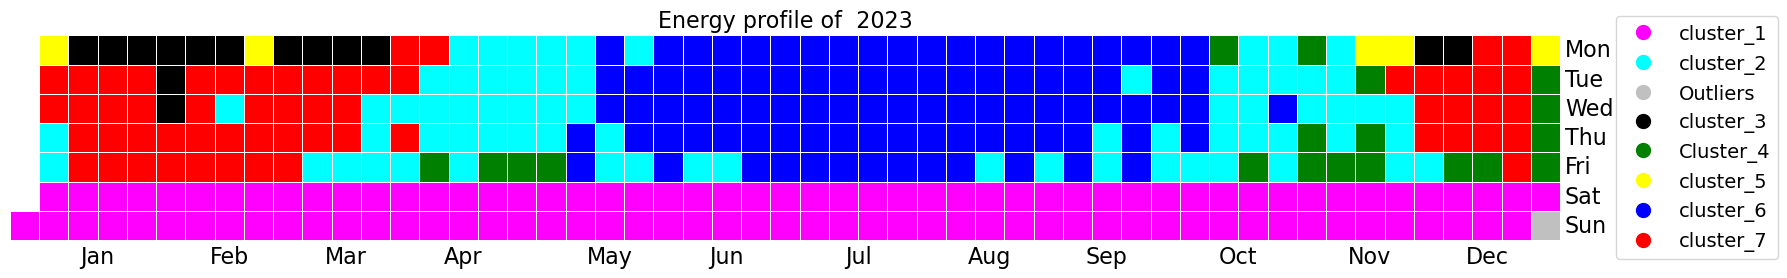

In [87]:
#Colmap for 7 clusters and outliers as another cluster
from matplotlib import colors

#Heat mape for 2023
# The colors and labels could be used from elsewhere as long as they are of the same size
cm_colors =  ['magenta', 'cyan', 'silver', 'black', 'green','yellow', 'blue','red']
cm_labels = ['cluster_1', 'cluster_2','Outliers','cluster_3', 'Cluster_4','cluster_5','cluster_6','cluster_7']
cmap = colors.ListedColormap(cm_colors)
fig, ax = plt.subplots(figsize=(20, 12))
#calmap.yearplot(events, year=2021, cmap=cmap, vmin=events.min(), vmax=events.max(), linewidth=0.3, ax=ax)
calmap.yearplot(events1, year=2021, cmap=cmap, vmin=events1.min(), vmax=events1.max(), linewidth=0.4, ax=ax)
# Adjust the size of the month names and day names
# ax.set_title('Energy profile of 2021', fontsize=24)  # Increase the title font size
# ax.set_xlabel('Months', fontsize=18)  # Label for x-axis (if you want to add it)
# ax.set_ylabel('Days', fontsize=18)    # Label for y-axis (if you want to add it)

# Set the font size of the month names and days of the week
ax.xaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the month names (x-axis)
ax.yaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the days of the week (y-axis)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
# ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
order = [0,1,2,4,5,6,7,3]
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left',fontsize=14)
# Create a legend with circles (markers) only
legend_handles = []
handles, labels = plt.gca().get_legend_handles_labels()
for i in range(len(cm_colors)):
    # Use dummy plot with markers only for the legend
    legend_handles.append(plt.Line2D([], [], color=cmap.colors[i], marker='o', linestyle='None', markersize=10, label=cm_labels[i]))
# Add the legend to the plot
ax.legend(handles=legend_handles, bbox_to_anchor=(1.03, 0.5), loc='center left',fontsize=14)
plt.title('Energy profile of  2021',fontsize=16)
fig.tight_layout()


#Heat mape for 2022
plt.figure()
cm_colors =  ['magenta', 'cyan', 'silver', 'black', 'green','yellow', 'blue','red']
cm_labels = ['cluster_1', 'cluster_2','Outliers','cluster_3', 'Cluster_4','cluster_5','cluster_6','cluster_7']
cmap = colors.ListedColormap(cm_colors)
fig, ax = plt.subplots(figsize=(20, 12))
calmap.yearplot(events1, year=2022, cmap=cmap, vmin=events1.min(), vmax=events1.max(), linewidth=0.4, ax=ax)
# Set the font size of the month names and days of the week
ax.xaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the month names (x-axis)
ax.yaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the days of the week (y-axis)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])

handles, labels = plt.gca().get_legend_handles_labels()
order = [0,1,2,4,5,6,7,3]
#ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left',fontsize=14)
# Create a legend with circles (markers) only
legend_handles = []
handles, labels = plt.gca().get_legend_handles_labels()
for i in range(len(cm_colors)):
    # Use dummy plot with markers only for the legend
    legend_handles.append(plt.Line2D([], [], color=cmap.colors[i], marker='o', linestyle='None', markersize=10, label=cm_labels[i]))
# Add the legend to the plot
ax.legend(handles=legend_handles, bbox_to_anchor=(1.03, 0.5), loc='center left',fontsize=14)
plt.title('Energy profile of  2022',fontsize=16)
fig.tight_layout()


#Heat mape for 2023
plt.figure()
plt.figure()
cm_colors =  ['magenta', 'cyan', 'silver', 'black', 'green','yellow', 'blue','red']
cm_labels = ['cluster_1', 'cluster_2','Outliers','cluster_3', 'Cluster_4','cluster_5','cluster_6','cluster_7']
cmap = colors.ListedColormap(cm_colors)
plt.figure(figsize=(24, 16))
fig, ax = plt.subplots(figsize=(20, 12))
calmap.yearplot(events1, year=2023, cmap=cmap, vmin=events1.min(), vmax=events1.max(), linewidth=0.4, ax=ax)
# Set the font size of the month names and days of the week
ax.xaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the month names (x-axis)
ax.yaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the days of the week (y-axis)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])

handles, labels = plt.gca().get_legend_handles_labels()
order = [0,1,2,4,5,6,7,3]
#ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left',fontsize=14)
# Create a legend with circles (markers) only
legend_handles = []
handles, labels = plt.gca().get_legend_handles_labels()
for i in range(len(cm_colors)):
    # Use dummy plot with markers only for the legend
    legend_handles.append(plt.Line2D([], [], color=cmap.colors[i], marker='o', linestyle='None', markersize=10, label=cm_labels[i]))
# Add the legend to the plot
ax.legend(handles=legend_handles, bbox_to_anchor=(1.03, 0.5), loc='center left',fontsize=14)
plt.title('Energy profile of  2023',fontsize=16)

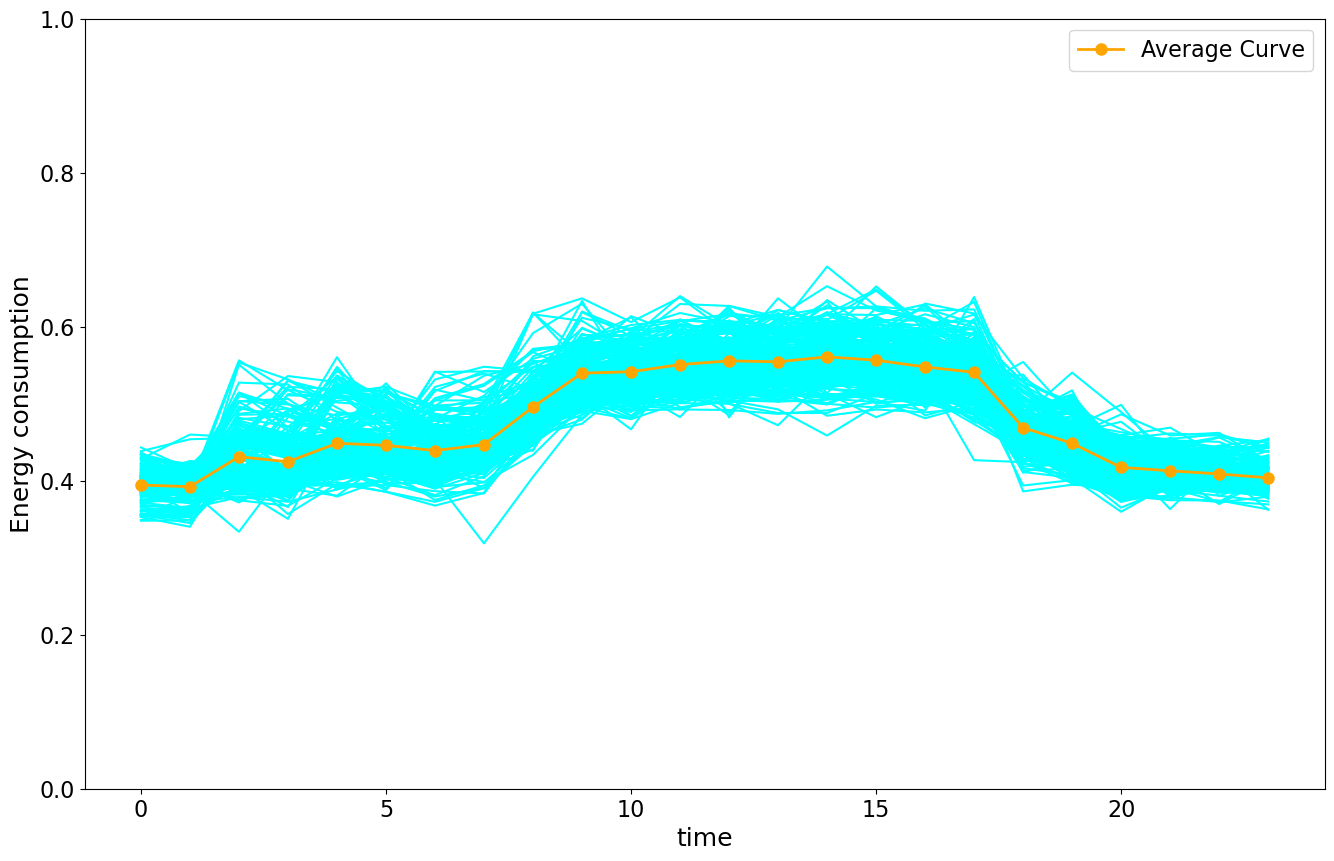

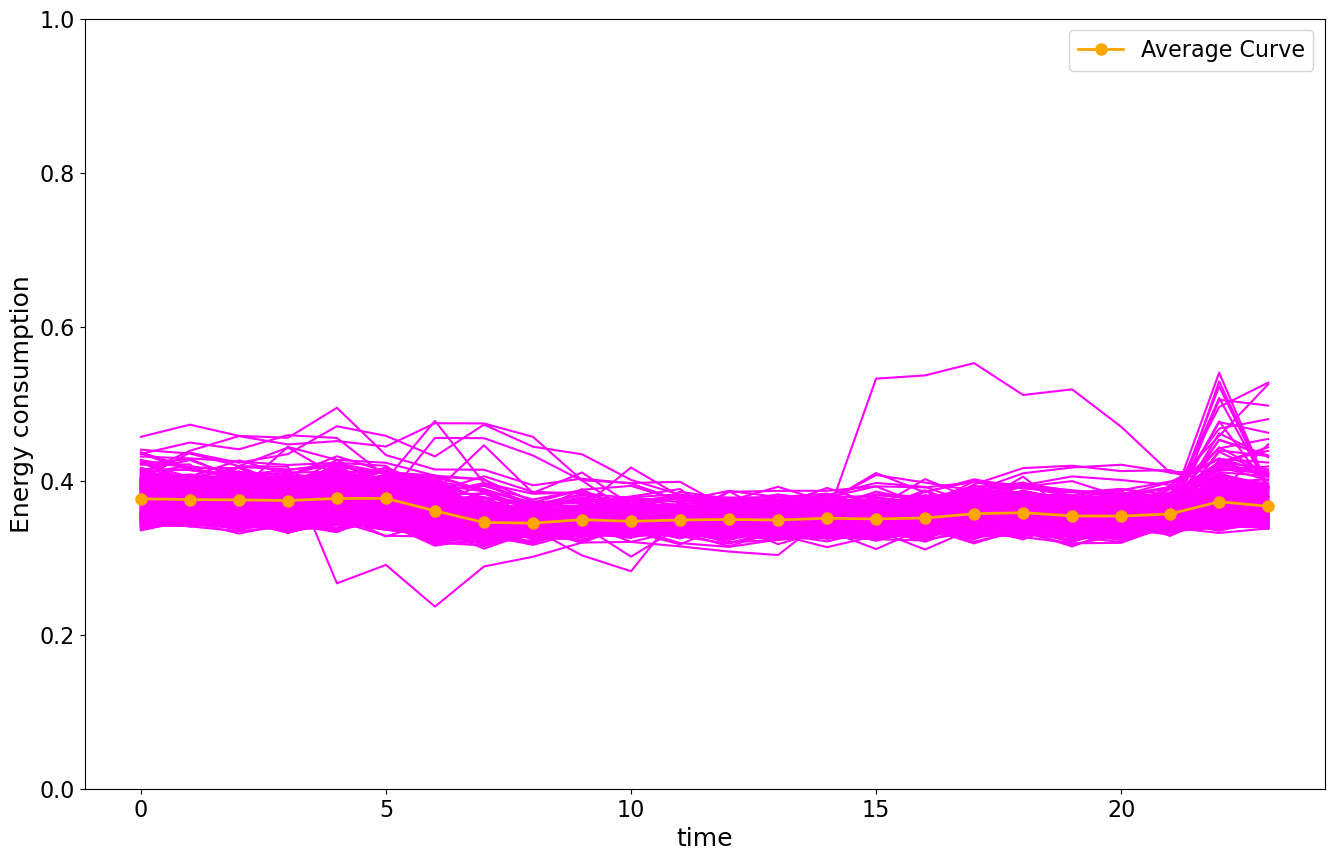

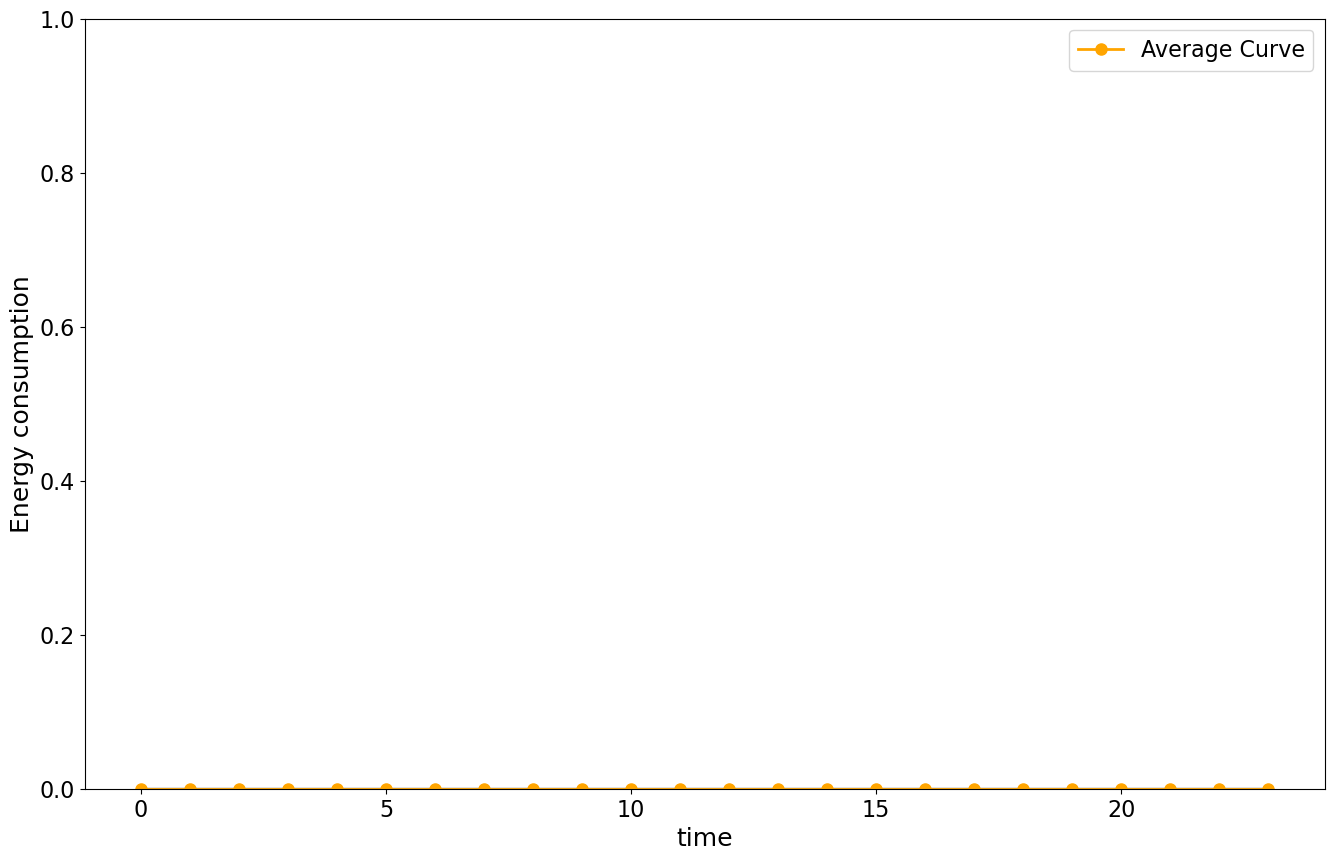

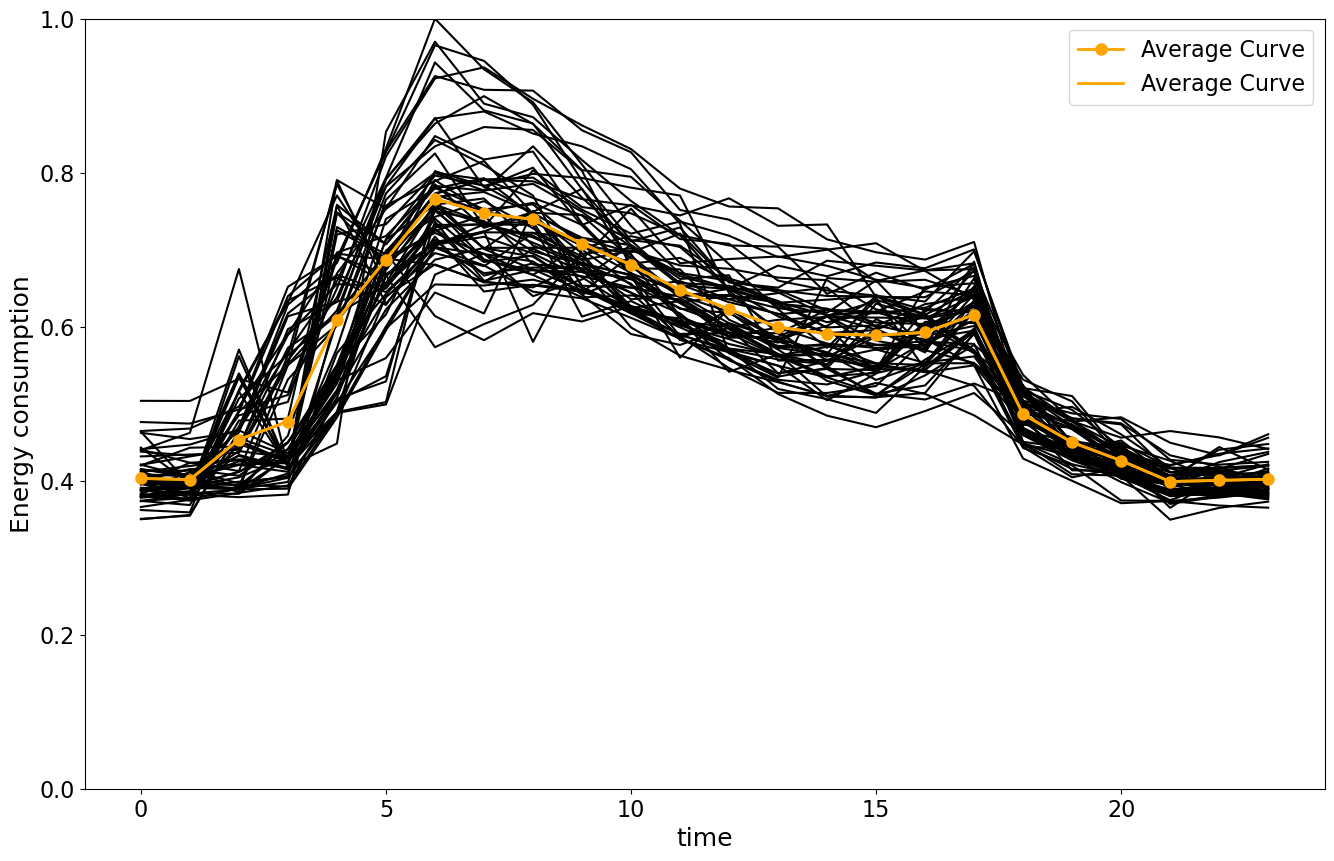

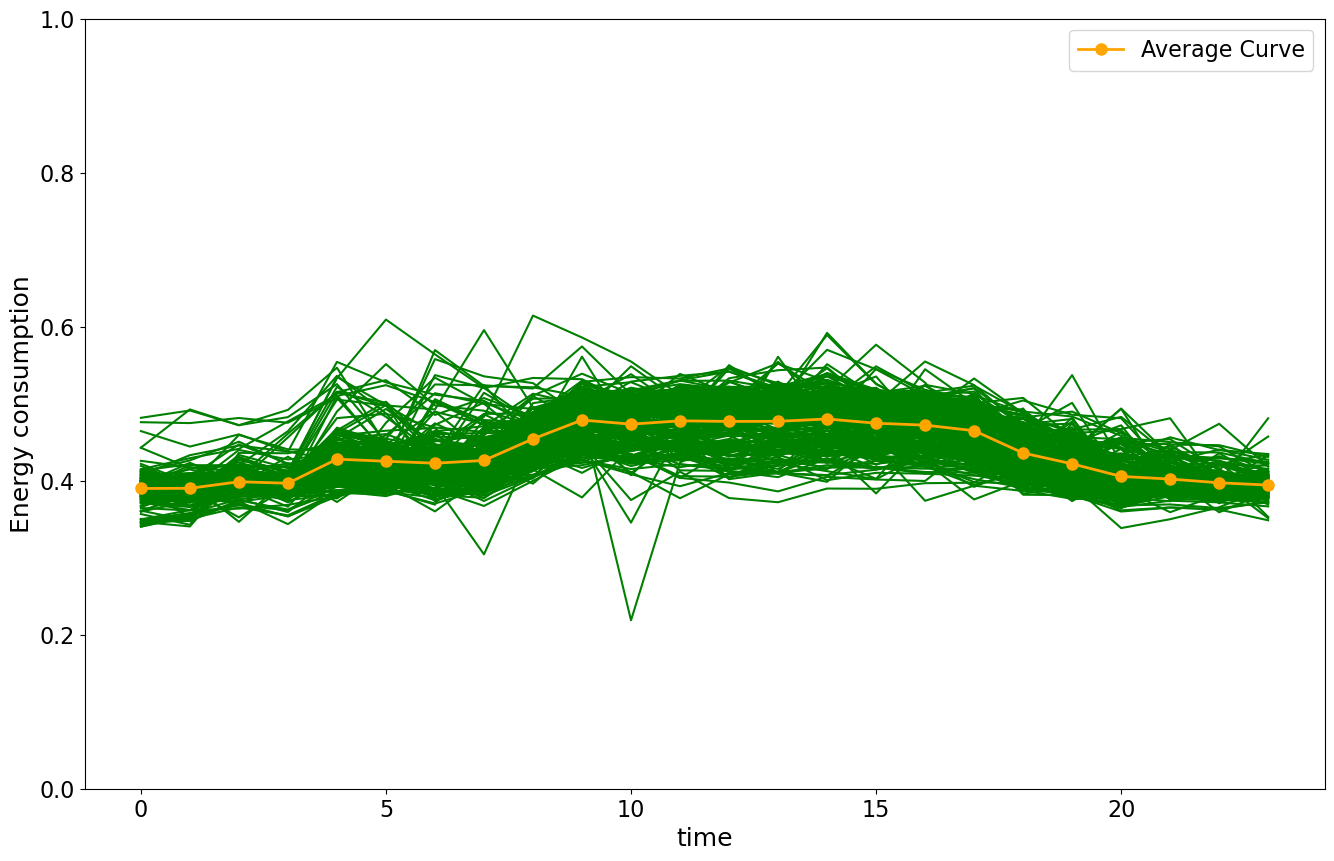

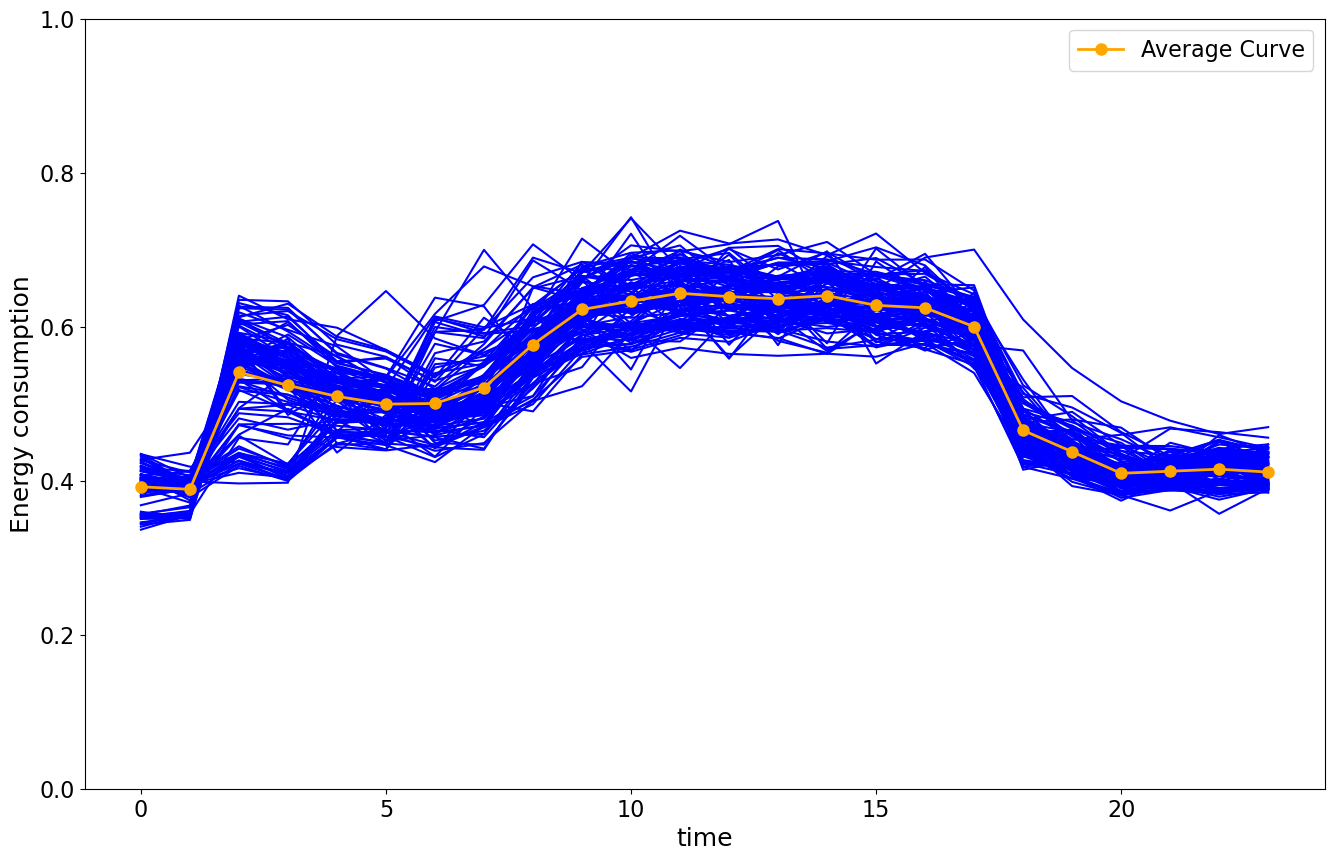

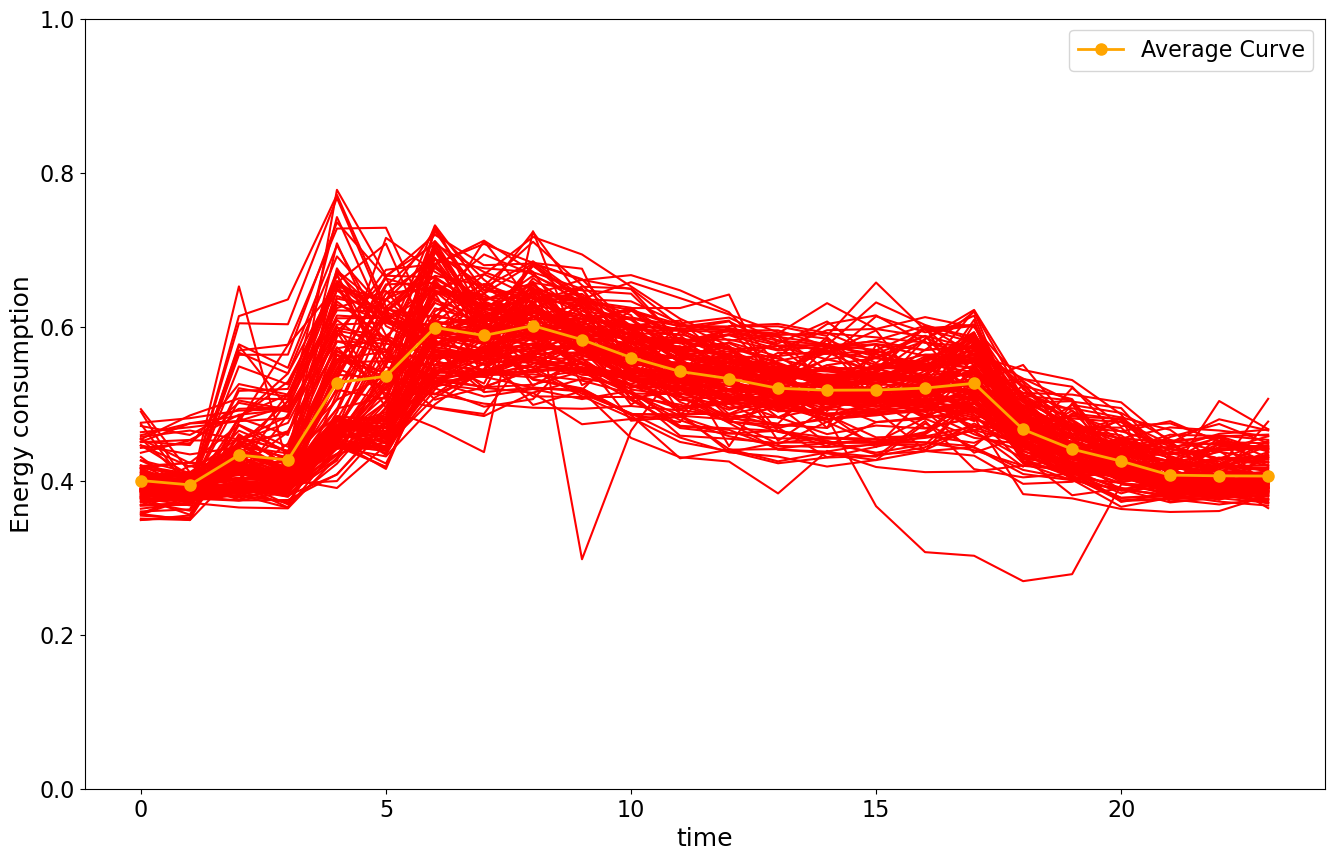

In [88]:
#clusters shape for having 6 clusters and outliers as another clusters
plt.figure(figsize=(16, 10))
for i in range(Dayly_Energy_labels2.shape[0]):
    if Dayly_Energy_labels2[i]==0: 
        plt.plot(X_N_clean[i], color = 'cyan') 
        plt.ylim(0, 1)
average_curve = np.mean(X_N_clean[Dayly_Energy_labels2 == 0], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Energy consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()
#plt.title("Energy-Cluster 1")

plt.figure(figsize=(16, 10))
for i in range(Dayly_Energy_labels2.shape[0]): 
    if Dayly_Energy_labels2[i]==1: 
        plt.plot(X_N_clean[i], color = 'magenta') 
        plt.ylim(0, 1)
plt.xlabel("time") 
plt.ylabel("Energy consumption")   
average_curve = np.mean(X_N_clean[Dayly_Energy_labels2 == 1], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Energy consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()
# plt.title("Energy-Cluster 2")
       
plt.figure(figsize=(16, 10))
for i in range(Dayly_Energy_labels2.shape[0]): 
    if Dayly_Energy_labels2[i]==2: 
        plt.plot(X_N_clean[i], color = 'silver') 
        plt.ylim(0, 1)
plt.xlabel("time") 
plt.ylabel("Energy consumption")   
average_curve = np.mean(X_N_clean[Dayly_Energy_labels2 == 2], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='purple', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Energy consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show() 
# plt.title("Energy-Cluster 3") 

plt.figure(figsize=(16, 10))
for i in range(Dayly_Energy_labels2.shape[0]): 
    if Dayly_Energy_labels2[i]==3: 
        plt.plot(X_N_clean[i], color = 'black') 
        plt.ylim(0, 1)
plt.xlabel("time") 
plt.ylabel("Energy consumption")   
average_curve = np.mean(X_N_clean[Dayly_Energy_labels2 == 3], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')
plt.plot(average_curve, color='orange', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Energy consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()   
# plt.title("Energy-Cluster 4")
        
plt.figure(figsize=(16, 10))
for i in range(Dayly_Energy_labels2.shape[0]): 
    if Dayly_Energy_labels2[i]==4: 
        plt.plot(X_N_clean[i], color = 'green')  
        plt.ylim(0, 1)
plt.xlabel("time") 
plt.ylabel("Energy consumption")   
average_curve = np.mean(X_N_clean[Dayly_Energy_labels2 == 4], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Energy consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()    
# plt.title("Energy-Cluster 5")
        
plt.figure(figsize=(16, 10))
for i in range(Dayly_Energy_labels2.shape[0]): 
   if Dayly_Energy_labels2[i]==5: 
       plt.plot(X_N_clean[i], color = 'blue')  
       plt.ylim(0, 1)
plt.xlabel("time") 
plt.ylabel("Energy consumption")   
average_curve = np.mean(X_N_clean[Dayly_Energy_labels2 == 5], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Energy consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()   
# plt.title("Energy-Cluster 6")

plt.figure(figsize=(16, 10))
for i in range(Dayly_Energy_labels2.shape[0]): 
   if Dayly_Energy_labels2[i]==6: 
       plt.plot(X_N_clean[i], color = 'red') 
       plt.ylim(0, 1)
plt.xlabel("time") 
plt.ylabel("Energy consumption")   
average_curve = np.mean(X_N_clean[Dayly_Energy_labels2 == 6], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Energy consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show() 
# plt.title("Energy-Cluster 7")


In [91]:
all_days = pd.date_range('01/01/2021', periods=X_clean.shape[0], freq='D')
days = np.random.choice(all_days, 1095)
#events = pd.Series(Dayly_Energy_labels, index=all_days)
# events = pd.Series(df1["Cluster_energy"].values, index=df1[0])
events2 = pd.Series(Dayly_Energy_labels2, index=DF_[0])
events1

0
2021-01-01    5
2021-01-02    0
2021-01-03    0
2021-01-04    5
2021-01-05    5
             ..
2023-12-27    4
2023-12-28    4
2023-12-29    4
2023-12-30    0
2023-12-31    2
Length: 1095, dtype: int32

C:\Users\User\anaconda3\Lib\site-packages\calmap\__init__.py:151: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  by_day = data.groupby(level=0).agg(how).squeeze()
C:\Users\User\anaconda3\Lib\site-packages\calmap\__init__.py:151: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  by_day = data.groupby(level=0).agg(how).squeeze()
C:\Users\User\anaconda3\Lib\site-packages\calmap\__init__.py:151: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  

Text(0.5, 1.0, 'Energy profile of  2023')

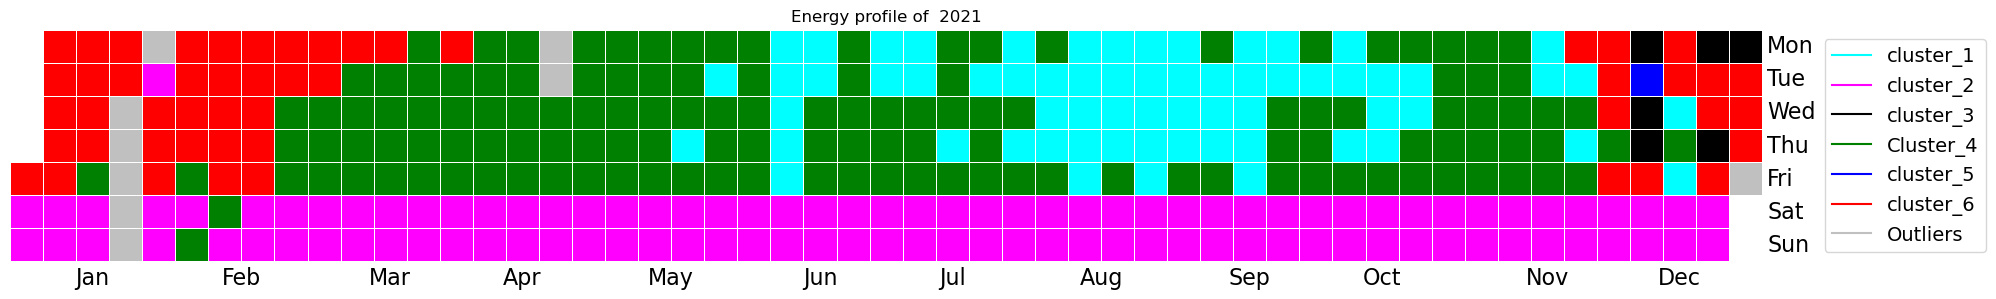

<Figure size 640x480 with 0 Axes>

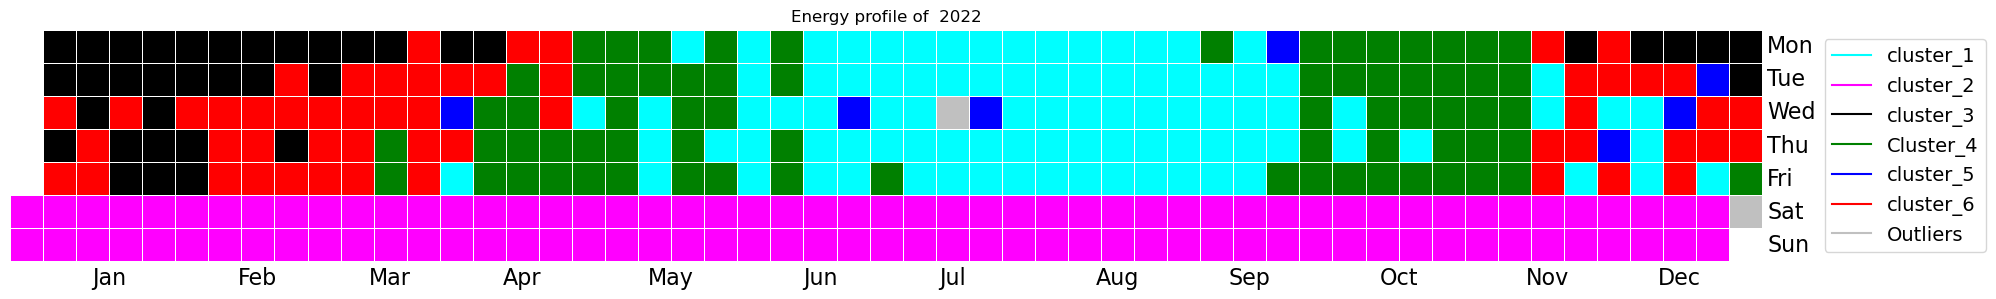

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 2400x1600 with 0 Axes>

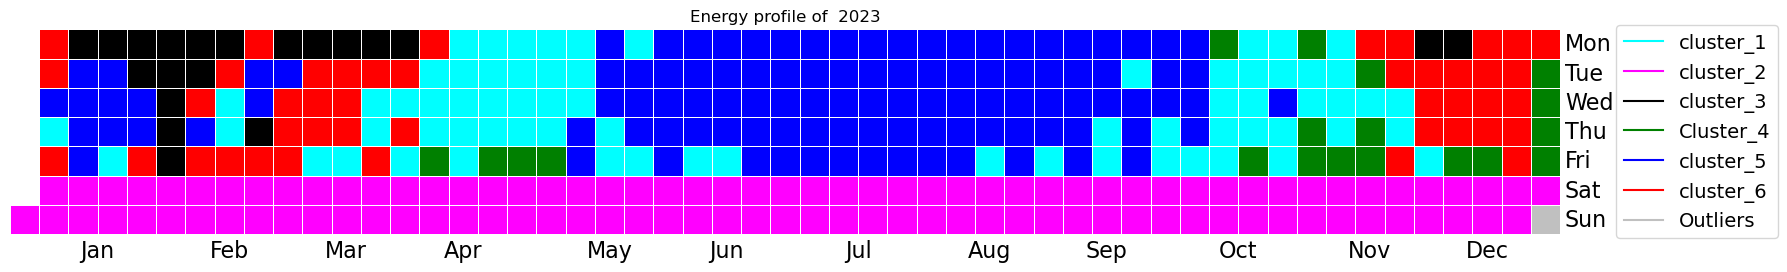

In [93]:
#Colmap for 6 clusters and outlier as another cluster
from matplotlib import colors

#Heat mape for 2023
# The colors and labels could be used from elsewhere as long as they are of the same size
cm_colors = [ 'cyan', 'magenta', 'silver', 'black', 'green', 'blue', 'red']
cm_labels = ['cluster_1', 'cluster_2','Outliers','cluster_3', 'Cluster_4','cluster_5','cluster_6']
cmap = colors.ListedColormap(cm_colors)
fig, ax = plt.subplots(figsize=(20, 12))
#calmap.yearplot(events, year=2021, cmap=cmap, vmin=events.min(), vmax=events.max(), linewidth=0.3, ax=ax)
calmap.yearplot(events2, year=2021, cmap=cmap, vmin=events2.min(), vmax=events2.max(), linewidth=0.4, ax=ax)
# Adjust the size of the month names and day names
# ax.set_title('Energy profile of 2021', fontsize=24)  # Increase the title font size
# ax.set_xlabel('Months', fontsize=18)  # Label for x-axis (if you want to add it)
# ax.set_ylabel('Days', fontsize=18)    # Label for y-axis (if you want to add it)

# Set the font size of the month names and days of the week
ax.xaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the month names (x-axis)
ax.yaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the days of the week (y-axis)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
# ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
handles, labels = plt.gca().get_legend_handles_labels()
order = [0,1,3,4,5,6,2]
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left',fontsize=14)
plt.title('Energy profile of  2021')
fig.tight_layout()


#Heat mape for 2022
plt.figure()
cm_colors = [ 'cyan', 'magenta', 'silver', 'black', 'green', 'blue', 'red']
cm_labels = ['cluster_1', 'cluster_2','Outliers','cluster_3', 'Cluster_4','cluster_5','cluster_6']
cmap = colors.ListedColormap(cm_colors)
fig, ax = plt.subplots(figsize=(20, 12))
calmap.yearplot(events2, year=2022, cmap=cmap, vmin=events2.min(), vmax=events2.max(), linewidth=0.4, ax=ax)
# Set the font size of the month names and days of the week
ax.xaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the month names (x-axis)
ax.yaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the days of the week (y-axis)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])

handles, labels = plt.gca().get_legend_handles_labels()
order = [0,1,3,4,5,6,2]
#ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left',fontsize=14)
plt.title('Energy profile of  2022')
fig.tight_layout()


#Heat mape for 2023
plt.figure()
plt.figure()
cm_colors = [ 'cyan', 'magenta', 'silver', 'black', 'green', 'blue', 'red']
cm_labels = ['cluster_1', 'cluster_2','Outliers','cluster_3', 'Cluster_4','cluster_5','cluster_6']
cmap = colors.ListedColormap(cm_colors)
plt.figure(figsize=(24, 16))
fig, ax = plt.subplots(figsize=(20, 12))
calmap.yearplot(events2, year=2023, cmap=cmap, vmin=events2.min(), vmax=events2.max(), linewidth=0.4, ax=ax)
# Set the font size of the month names and days of the week
ax.xaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the month names (x-axis)
ax.yaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the days of the week (y-axis)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])

handles, labels = plt.gca().get_legend_handles_labels()
order = [0,1,3,4,5,6,2]
#ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left',fontsize=14)
plt.title('Energy profile of  2023')

In [94]:
X1=[]  

for i in range(Dayly_Energy_labels1.shape[0]):
    if Dayly_Energy_labels1[i]==0:  
        X1.append(X_N_clean[i])
np.array(X1).shape        
#X1

(309, 24)

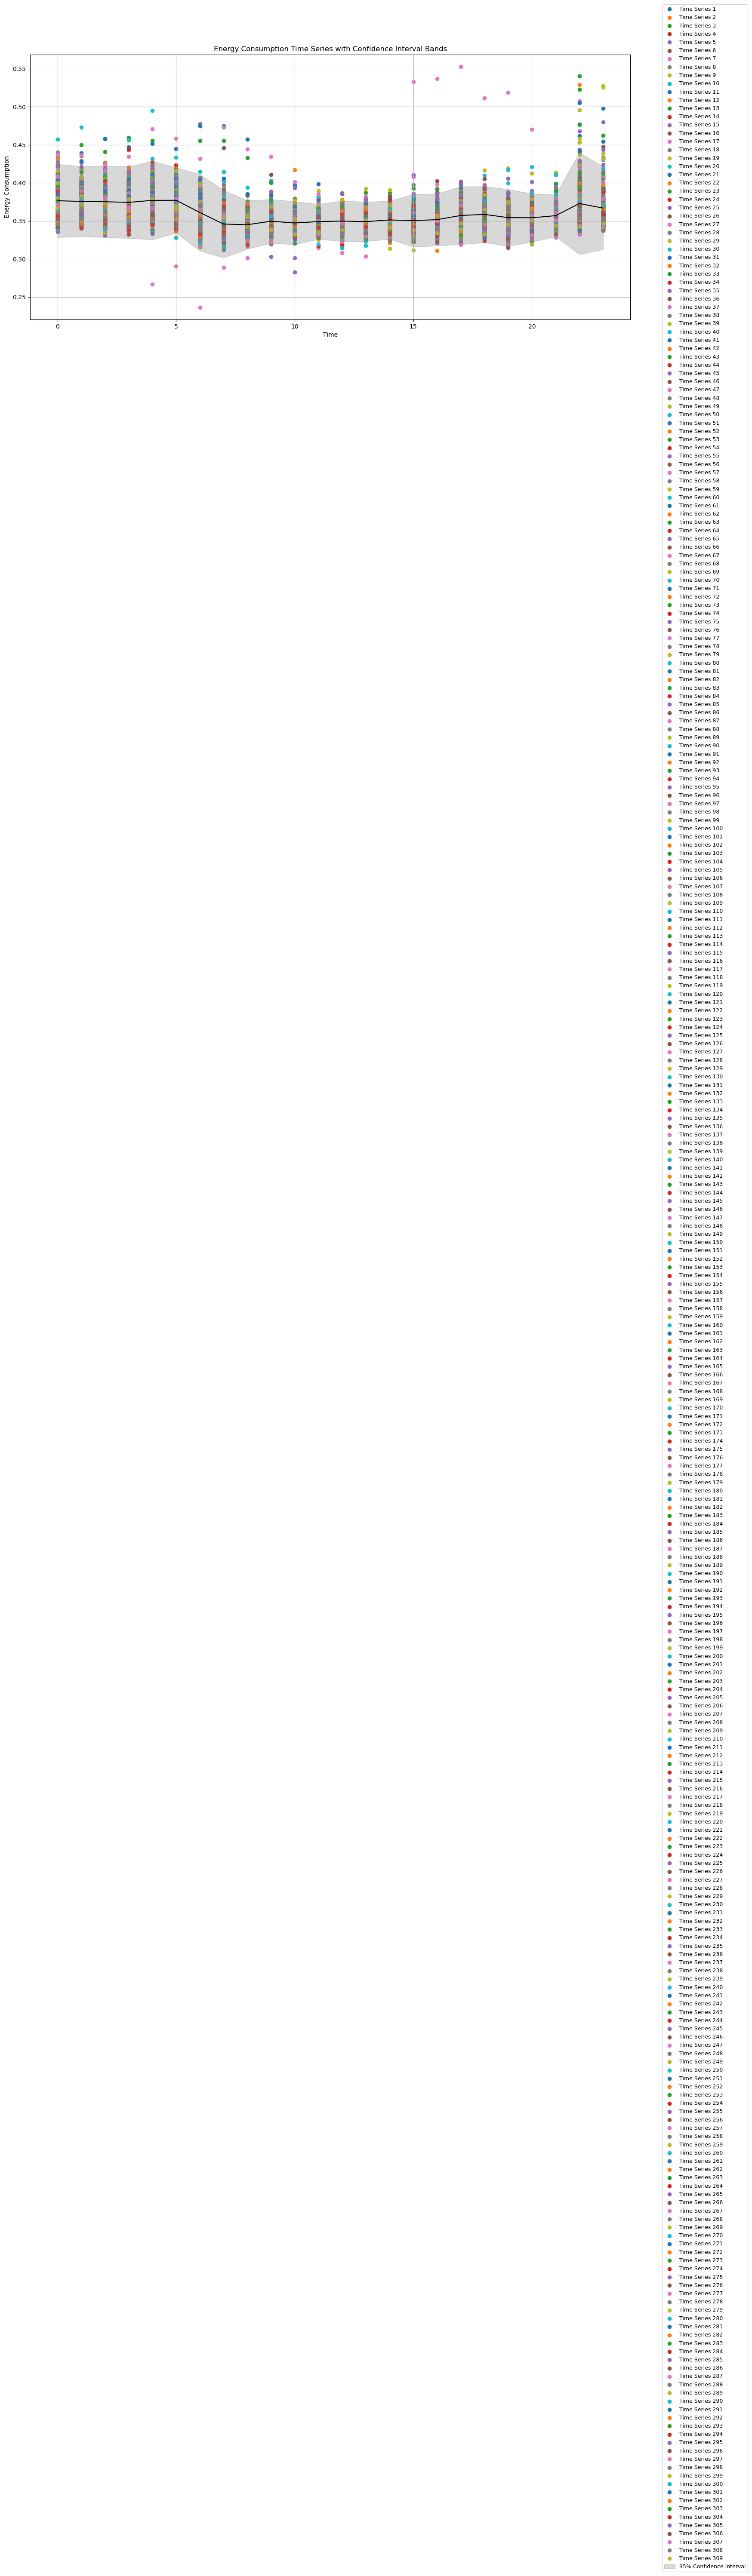

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Sample multiple time series data (replace with your own data)
n_time_series = np.array(X1).shape[0]
time = np.arange(0, 24)
energy_consumption_data = np.array(X1)
mean_all = []
# Calculate confidence interval band for each time
lower_cis = np.zeros(len(time))
upper_cis = np.zeros(len(time))
for i, t in enumerate(time):
    data = energy_consumption_data[:, i]  # Select data at time t from all time series
    n = len(data)
    mean = np.mean(data) 
    mean_all.append(mean) 
    
    std = np.std(data, ddof=1)
    alpha = 0.05  # 1 - confidence level
    t_value = stats.t.ppf(1 - alpha / 2, df=n - 1)
    margin_of_error = t_value * std / np.sqrt(n)
    lower_ci = mean - 2*std #margin_of_error
    upper_ci = mean + 2*std  #margin_of_error
    lower_cis[i] = lower_ci
    upper_cis[i] = upper_ci
mean_all = np.array(mean_all)
# Plot the data and confidence interval bands
plt.figure(figsize=(18, 8))
for i in range(n_time_series):
   plt.scatter(time, energy_consumption_data[i], label=f'Time Series {i+1}')
plt.fill_between(time, lower_cis, upper_cis, alpha=0.3, color='gray', label='95% Confidence Interval') 
plt.plot(time, mean_all, color = "black")
plt.xlabel('Time')
plt.ylabel('Energy Consumption')
plt.title('Energy Consumption Time Series with Confidence Interval Bands')
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.2),prop={'size': 9})
plt.grid(True)
plt.show()

In [98]:
mean_all

array([0.3764516 , 0.37556553, 0.37511654, 0.37428311, 0.37696576,
       0.37705636, 0.36097491, 0.34581317, 0.34494227, 0.34950234,
       0.3472234 , 0.34902309, 0.3497384 , 0.3490147 , 0.35124483,
       0.35039929, 0.35159027, 0.3570862 , 0.35848384, 0.35426049,
       0.35406182, 0.35683413, 0.37279061, 0.36678947])

# start of Regration and fitting 

In [101]:
cl1_clean=consumption_cl1_N
cl2_clean=consumption_cl2_N
cl3_clean=consumption_cl3_N
cl4_clean=consumption_cl4_N
cl5_clean=consumption_cl5_N
cl6_clean=consumption_cl6_N
cl7_clean=consumption_cl7_N

In [103]:
cl1_N=consumption_cl1_N
cl2_N=consumption_cl2_N
cl3_N=consumption_cl3_N
cl4_N=consumption_cl4_N
cl5_N=consumption_cl5_N
cl6_N=consumption_cl6_N
cl7_N=consumption_cl7_N

In [105]:
cl1=consumption_cl1
cl2=consumption_cl2
cl3=consumption_cl3
cl4=consumption_cl4
cl5=consumption_cl5
cl6=consumption_cl6
cl7=consumption_cl7

In [107]:
32%7
int(28/7)

4

In [109]:
def average_finder(x, y):
    x_y=np.zeros(y)
    m=int(x.shape[0]/y)
    k=0
    if x.shape[0]%y==0:
        x1=np.zeros(m).reshape(m,1)
        for i in range (m):
            for j in range (y):
                x_y[j]=x[k]
                k=k+1
            x1[i]=np.average(x_y)
    else:
        x_r=np.zeros(x.shape[0]%y)
        x1=np.zeros(m+1).reshape(m+1,1)
        for i in range (m):
            for j in range (y):
                x_y[j]=x[k]
                k=k+1
            x1[i]=np.average(x_y)
        for i in range (x.shape[0]%y):
            x_r[i]=x[i+k]
        x1[m,0]=np.average(x_r)
    return x1

In [111]:
def sum_finder(x, y):
    x_y=np.zeros(y)
    m=int(x.shape[0]/y)
    k=0
    if x.shape[0]%y==0:
        x1=np.zeros(m).reshape(m,1)
        for i in range (m):
            for j in range (y):
                x_y[j]=x[k]
                k=k+1
            x1[i]=np.sum(x_y)
    else:
        x_r=np.zeros(x.shape[0]%y)
        x1=np.zeros(m+1).reshape(m+1,1)
        for i in range (m):
            for j in range (y):
                x_y[j]=x[k]
                k=k+1
            x1[i]=np.sum(x_y)
        for i in range (x.shape[0]%y):
            x_r[i]=x[i+k]
        x1[m,0]=np.sum(x_r)
    return x1

In [113]:
#Fitting for Cluster 1

Text(0, 0.5, 'Operation Ration for Equipment')

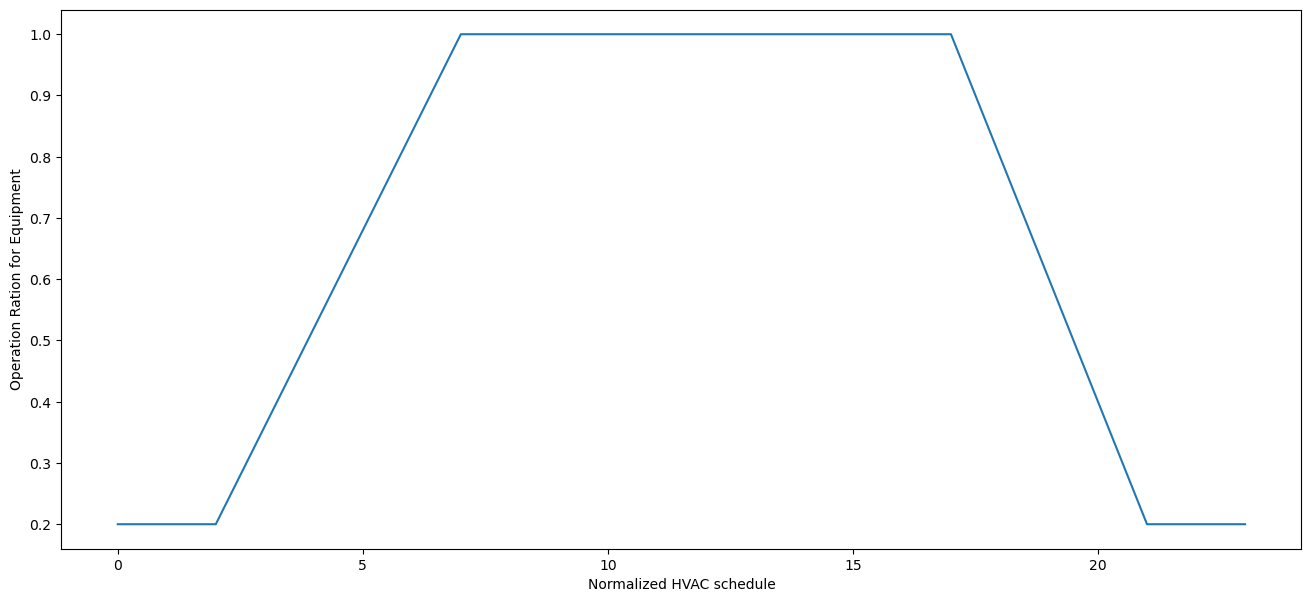

In [115]:
schadule11=np.arange(24)
schadule=np.zeros(24)

for i in range (24):
    if (schadule11[i]<=2):
        schadule[i]=0.2
    if (schadule11[i]>2 and schadule11[i]<=7 ):
        schadule[i]=0.16*schadule11[i]-0.12
    if (schadule11[i]>7 and schadule11[i]<=17 ):
        schadule[i]=1
    if (schadule11[i]>17 and schadule11[i]<=21 ):
        schadule[i]=-0.2*schadule11[i]+4.4
schadule[22]=0.2
schadule[23]=0.2

plt.figure(figsize=(16, 7))
plt.plot(schadule)
plt.xlabel("Normalized HVAC schedule") 
plt.ylabel("Operation Ration for Equipment")   
# plt.title("Operation schadule of the building")

Text(0.5, 1.0, 'Operation schadule of the building')

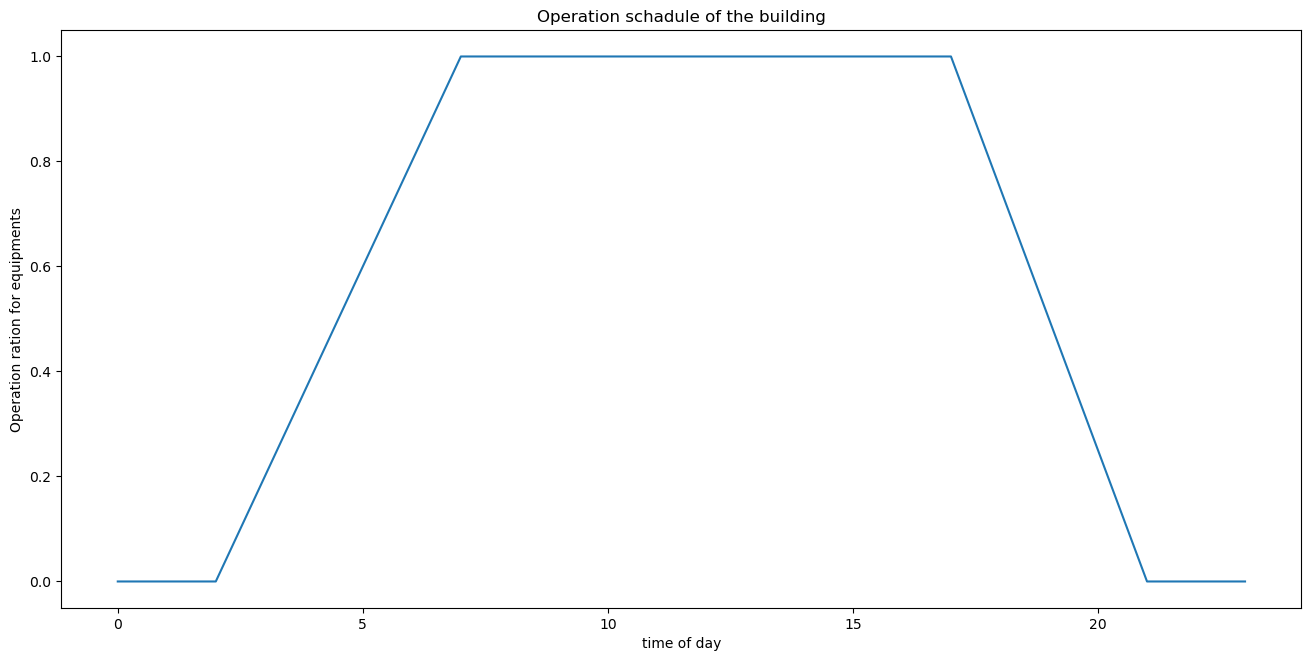

In [117]:
schadule11=np.arange(24)
schadule2=np.zeros(24)

for i in range (24):
    if (schadule11[i]<=2):
        schadule2[i]=0
    if (schadule11[i]>2 and schadule11[i]<=8 ):
        schadule2[i]=0.2*schadule11[i]-0.4
    if (schadule11[i]>7 and schadule11[i]<=17 ):
        schadule2[i]=1
    if (schadule11[i]>17 and schadule11[i]<=21 ):
        schadule2[i]=-0.25*schadule11[i]+5.25
# schadule2[22]=0
# schadule2[23]=0

plt.figure(figsize=(16, 7.5))
plt.plot(schadule2)
plt.xlabel("time of day") 
plt.ylabel("Operation ration for equipments")   
plt.title("Operation schadule of the building")

Text(0.5, 1.0, 'Occupancy schadule of the building')

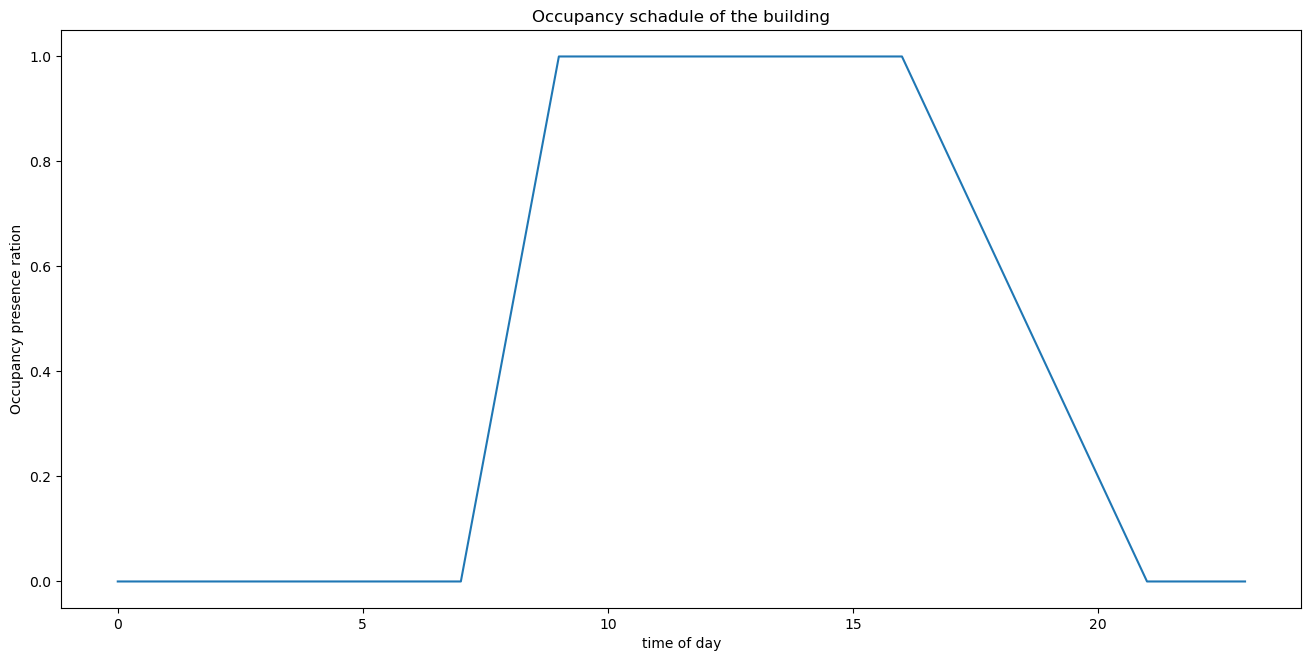

In [119]:
#occupancy schedule
Ocu1=np.arange(24)
Ocu_schadule=np.zeros(24)

for i in range (24):
    if (Ocu1[i]<=7):
        Ocu_schadule[i]=0
    if (Ocu1[i]>7 and Ocu1[i]<=9 ):
        Ocu_schadule[i]=0.5*Ocu1[i]-3.5
    if (Ocu1[i]>9 and Ocu1[i]<=16 ):
        Ocu_schadule[i]=1
    if (Ocu1[i]>16 and Ocu1[i]<=21 ):
        Ocu_schadule[i]=-0.2*Ocu1[i]+4.2
# schadule2[22]=0
# schadule2[23]=0

plt.figure(figsize=(16, 7.5))
plt.plot(Ocu_schadule)
plt.xlabel("time of day") 
plt.ylabel("Occupancy presence ration")   
plt.title("Occupancy schadule of the building")

In [121]:
schadule1=np.zeros(24)
Ev1_consumption1=np.zeros(consumption_cl1.shape[0]*consumption_cl1.shape[1]).reshape(consumption_cl1.shape[0]*consumption_cl1.shape[1],1)
Ev1_consumption1_clean=np.zeros(consumption_cl1.shape[0]*consumption_cl1.shape[1]).reshape(consumption_cl1.shape[0]*consumption_cl1.shape[1],1)
Time1=np.zeros(consumption_cl1.shape[0]*consumption_cl1.shape[1]).reshape(consumption_cl1.shape[0]*consumption_cl1.shape[1],1)
Time1_1=np.zeros(consumption_cl1.shape[0]*consumption_cl1.shape[1]).reshape(consumption_cl1.shape[0]*consumption_cl1.shape[1],1)
Sch1=np.zeros(consumption_cl1.shape[0]*consumption_cl1.shape[1]).reshape(consumption_cl1.shape[0]*consumption_cl1.shape[1],1)
Sch1_2=np.zeros(consumption_cl1.shape[0]*consumption_cl1.shape[1]).reshape(consumption_cl1.shape[0]*consumption_cl1.shape[1],1)
Temprature1=np.zeros(consumption_cl1.shape[0]*consumption_cl1.shape[1]).reshape(consumption_cl1.shape[0]*consumption_cl1.shape[1],1)
Rad1=np.zeros(consumption_cl1.shape[0]*consumption_cl1.shape[1]).reshape(consumption_cl1.shape[0]*consumption_cl1.shape[1],1)
k=0
for i in range (consumption_cl1.shape[0]):
    t=0
    for j in range (consumption_cl1.shape[1]):
        Time1[k,0]=t
        Time1_1[k,0]=1-abs(t-12)/12
        Sch1[k,0]=schadule2[j]
        Sch1_2[k,0]=schadule[j]
#         Ev1_consumption1[k,0]=consumption_cl1[i,j]
        Ev1_consumption1[k,0]=consumption_cl1_N[i,j]
#         Ev1_consumption1_clean[k,0]=cl1_N[i,j]
        Temprature1[k,0]=Temp_cl1[i,j]
        Rad1[k,0]=Total_Rad_cl1[i,j]
        k=k+1
        t=t+1

Sch1[10,0]

1.0

In [125]:
temp_daily_1=average_finder(Temprature1,24)
min_temp1=temp_daily_1.min()
max_temp1=temp_daily_1.max()
print('min temprature=',min_temp1)
print('max temprature=',max_temp1)
av_temp_1=np.average(temp_daily_1)
print ("average temperature clusterav_temp_1=",av_temp_1)
# Consumption_daily_cl1=sum_finder(Ev1_consumption1,24)
# Ev1_consumption1=sum_finder(Ev1_consumption1,24)

min temprature= -17.583333333333332
max temprature= 25.458333333333332
average temperature clusterav_temp_1= 8.162216828478964


C:\Users\User\AppData\Local\Temp\ipykernel_24248\3814052515.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x_y[j]=x[k]


In [129]:
# input_ev1=temp_daily_1
# input_ev1=Temprature1
input_ev1=np.c_[Temprature1, Rad1]
# input_ev1=np.c_[Sch1, Rad1]
# input_ev1=np.c_[input_ev1, Time1]
# input_ev1=np.c_[input_ev1, Sch1]
input_ev1

array([[-1.,  0.],
       [-1.,  0.],
       [ 0.,  0.],
       ...,
       [ 0.,  0.],
       [-1.,  0.],
       [ 0.,  0.]])

In [131]:
# np.isnan(GHI).sum()
Ev1_consumption1

array([[0.39028795],
       [0.40179401],
       [0.39125118],
       ...,
       [0.34421856],
       [0.34241627],
       [0.3463482 ]])

In [133]:
#Linear Regression
from sklearn.linear_model import LinearRegression
regr = LinearRegression()
actual = Ev1_consumption1
#in x get all columns except goals column

regr.fit(input_ev1,Ev1_consumption1)
#regr.predict(x)  

predict = regr.predict(input_ev1)
from sklearn.metrics import mean_squared_error
rms = mean_squared_error(actual, predict, squared=False)
print ("Mean square error=",rms)

from sklearn.metrics import r2_score 
r2 = r2_score(actual, predict) 
print("R^2=",r2)

from sklearn.metrics import mean_absolute_percentage_error 
err=mean_absolute_percentage_error(actual, predict)
print ("Mean absolute percentage error=", err*100)

Mean square error= 0.0215796362569482
R^2= 0.12322490311049727
Mean absolute percentage error= 4.3799698673306064


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [135]:
regr.coef_

array([[-0.00052949, -0.02111997]])

In [137]:
regr.intercept_

array([0.3662358])

In [139]:
# #Linear Regression
# from sklearn.linear_model import LinearRegression
# regr = LinearRegression()
# # actual = Ev1_consumption1_clean
# actual = Ev1_consumption1_clean
# #in x get all columns except goals column

# # regr.fit(input_ev1,Ev1_consumption1_clean)
# regr.fit(input_ev1,Ev1_consumption1_clean)
# #regr.predict(x)  

# predict = regr.predict(input_ev1)
# from sklearn.metrics import mean_squared_error
# rms = mean_squared_error(actual, predict, squared=False)
# print ("Mean square erro=",rms)

# from sklearn.metrics import r2_score 
# r2 = r2_score(actual, predict) 
# print("R^2=",r2)

# from sklearn.metrics import mean_absolute_percentage_error 
# err=mean_absolute_percentage_error(actual, predict)
# print ("error=", err*100)

In [141]:
# regr.coef_

In [143]:
# nn=Ev1_consumption1_clean.shape[0]
# ev1=average_finder(Ev1_consumption1_clean.reshape(nn),12)
# input_ev1=average_finder(Temprature1.reshape(nn),12)

In [145]:
# p=predict 
# r=Ev1_consumption1
# err=(abs(p-r)/r)*100
# err.mean()


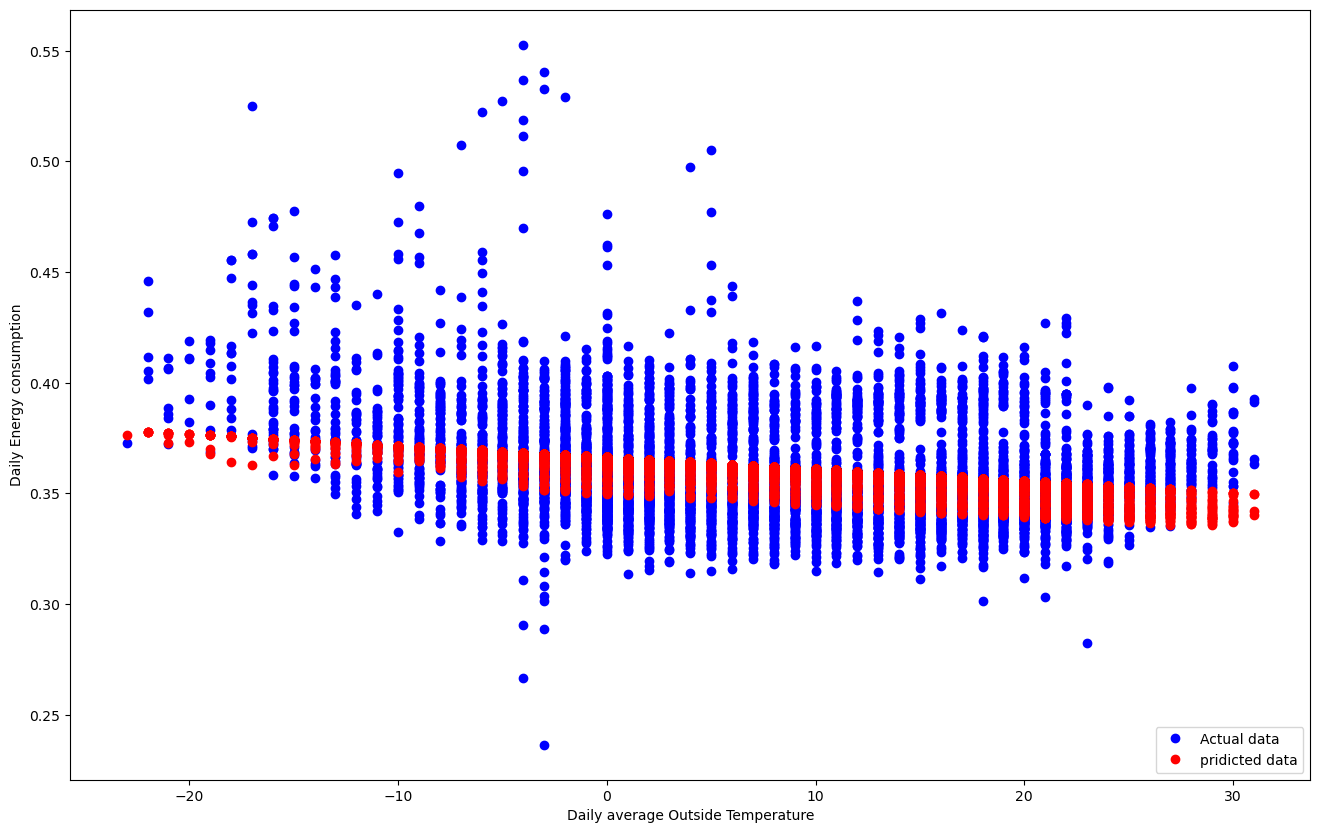

In [140]:
plt.figure(figsize=(16, 10))
plt.plot(Temprature1,actual,'bo')
plt.plot(Temprature1,predict,'ro')
plt.legend(["Actual data", "pridicted data"], loc ="lower right") 
plt.xlabel("Daily average Outside Temperature") 
plt.ylabel("Daily Energy consumption") 
plt.show() 
# plt.title("Operation schadule of the building")

In [147]:
# Polynomial fitting 
from sklearn.preprocessing import PolynomialFeatures
regr = PolynomialFeatures(degree=2, include_bias=False)
actual = Ev1_consumption1
#in x get all columns except goals column


#regr.fit(fit_1[["Time","Temperature (C)"]],fit_1[["Energy consumption (kWh)"]])
#regr.predict(x)  
X_poly  = regr.fit_transform(input_ev1)
model = LinearRegression()
model.fit(X_poly, actual) 
y_pred = model.predict(X_poly)

#from sklearn.metrics import mean_squared_error
rms = mean_squared_error(actual, y_pred, squared=False)  
print ("meant square error=",rms)

from sklearn.metrics import r2_score 
r2 = r2_score(actual, y_pred) 
print( "R^2=",r2)

from sklearn.metrics import mean_absolute_percentage_error 
err=mean_absolute_percentage_error(actual, y_pred)
print ("Mean absolute percentage error=", err*100)

meant square error= 0.020071013504446567
R^2= 0.2415297125149154
Mean absolute percentage error= 4.007995345009825


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [149]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

# Assuming:
# input_ev1 = your features (X)
# Ev1_consumption1 = your target (y)

# 1. Split data into train/test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    input_ev1,
    Ev1_consumption1, 
    test_size=0.2, 
    random_state=42
)

# # 2. Scale features (critical for polynomial regression)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# 3. Generate polynomial features (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)  # Important: use transform(), not fit_transform()

# 4. Train model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# 5. Evaluate
train_pred = model.predict(X_train_poly)
test_pred = model.predict(X_test_poly)

# Metrics for training set (for reference)
print("=== Training Set ===")
print(f"MSE: {mean_squared_error(y_train, train_pred):.4f}")
print(f"R²: {r2_score(y_train, train_pred):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_train, train_pred)*100:.2f}%")

# Metrics for test set (true performance)
print("\n=== Test Set ===")
print(f"MSE: {mean_squared_error(y_test, test_pred):.4f}")
print(f"R²: {r2_score(y_test, test_pred):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, test_pred)*100:.2f}%")

# # 6. Diagnostic Plot (Actual vs Predicted)
# import matplotlib.pyplot as plt
# plt.scatter(y_test, test_pred, alpha=0.5)
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
# plt.xlabel("Actual Energy Consumption")
# plt.ylabel("Predicted Energy Consumption")
# plt.title("Polynomial Regression (Degree=2)")
# plt.show()

=== Training Set ===
MSE: 0.0004
R²: 0.2373
MAPE: 3.95%

=== Test Set ===
MSE: 0.0004
R²: 0.2495
MAPE: 4.10%


In [151]:
model.coef_

array([[-1.27557764e-03, -1.02543815e-01,  4.74583257e-05,
         6.45387607e-04,  1.19108995e-01]])

In [153]:
model.intercept_

array([0.36549737])

In [155]:
# from sklearn.preprocessing import PolynomialFeatures
# regr = PolynomialFeatures(degree=2, include_bias=False)
# actual = Ev1_consumption1_clean
# #in x get all columns except goals column


# #regr.fit(fit_1[["Time","Temperature (C)"]],fit_1[["Energy consumption (kWh)"]])
# #regr.predict(x)  
# X_poly  = regr.fit_transform(input_ev1)
# model = LinearRegression()
# model.fit(X_poly, actual) 
# y_pred = model.predict(X_poly)

# #from sklearn.metrics import mean_squared_error
# rms = mean_squared_error(actual, y_pred, squared=False)  
# print ("meant square error=",rms)

# from sklearn.metrics import r2_score 
# r2 = r2_score(actual, y_pred) 
# print( "R^2=",r2)

# from sklearn.metrics import mean_absolute_percentage_error 
# err=mean_absolute_percentage_error(actual, y_pred)
# print ("error=", err*100)

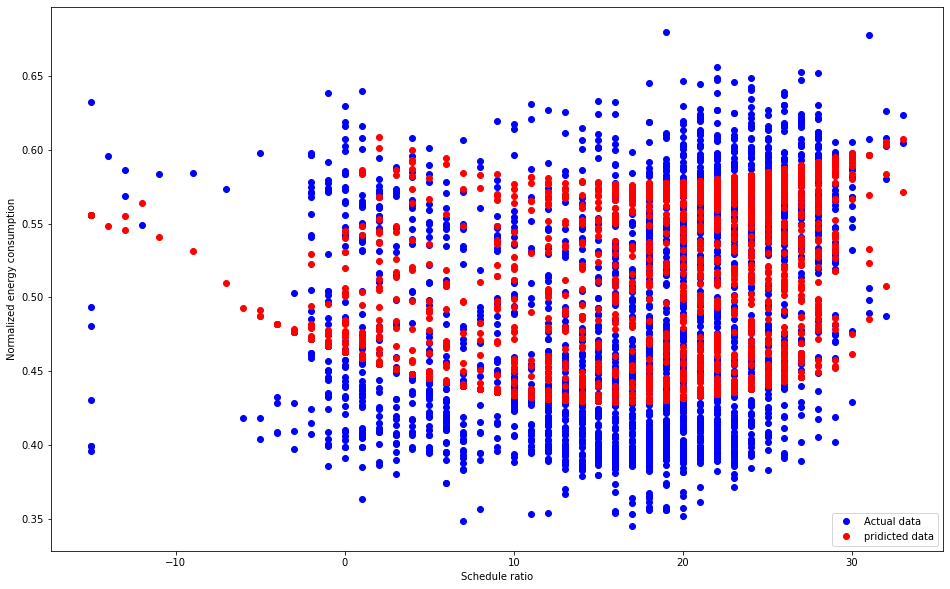

In [219]:
plt.figure(figsize=(16, 10))
plt.plot(Temprature1,actual,'bo')
plt.plot(Temprature1,y_pred,'ro')
plt.legend(["Actual data", "pridicted data"], loc ="lower right") 
plt.xlabel("Schedule ratio")
plt.ylabel("Normalized energy consumption") 
plt.show() 

In [214]:
# input_ev1=np.c_[ Rad1,Temprature1]

In [157]:
#Neural network
from sklearn.neural_network import MLPRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
#mlp = MLPRegressor(hidden_layer_sizes=(200, 100))
#X, y = make_regression(n_samples=200, random_state=1)
X =input_ev1
y =Ev1_consumption1
X_train, X_test, y_train, y_test = train_test_split(X, y,random_state=1)
regr = MLPRegressor(random_state=1, max_iter=500).fit(X_train, y_train)
#regr=mlp.fit(X_train, y_train)
regr.predict(X_test[:2])
regr.score(X_test, y_test)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1624: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.06155790063594746

In [196]:
pre=regr.predict(X)
from sklearn.metrics import mean_squared_error
rms = mean_squared_error(y, pre, squared=False)  
print ("Mean square error=", rms)

from sklearn.metrics import mean_absolute_percentage_error 
err=mean_absolute_percentage_error(y, pre)*100
print ("error=", err)

Mean square error= 0.02201353223865881
error= 4.481632837684274


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [200]:
### Grid search with Cross-Validation for optimiing MLP
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

X =input_ev1
y =Ev1_consumption1
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

# # Scale the data (important for neural networks)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# Define the parameter grid
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50,50), (100,50), (200,100)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['adam', 'lbfgs'],
    'alpha': [0.0001, 0.001, 0.01],  # L2 regularization
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [500, 1000],
    'early_stopping': [True],
    'validation_fraction': [0.1]
}

# Create the MLPRegressor
mlp = MLPRegressor(random_state=1)

# Create GridSearchCV object
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

# Evaluate on test set
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test, y_test)
print("Test score: ", test_score)

Fitting 5 folds for each of 720 candidates, totalling 3600 fits


C:\Users\User\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1624: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters found:  {'activation': 'relu', 'alpha': 0.0001, 'early_stopping': True, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'learning_rate_init': 0.01, 'max_iter': 500, 'solver': 'adam', 'validation_fraction': 0.1}
Best score:  0.20954575217188703
Test score:  0.1945939571744093


In [170]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred = best_model.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

MSE: 0.1382
MAE: 0.3339
RMSE: 0.3718


In [146]:
X_E1.max()

232.007

In [159]:
###MPL optimization using optuna

import optuna
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import numpy as np

# Load your data
X = input_ev1
y = Ev1_consumption1

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def objective(trial):
    # Define hyperparameter search space
    params = {
        'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes', 
                                      [(50,), (100,), (1000,), (50,50), (100,50), (200,100)]),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh', 'logistic']),
        'solver': trial.suggest_categorical('solver', ['adam', 'lbfgs']),
        'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        'learning_rate': trial.suggest_categorical('learning_rate', ['constant', 'adaptive']),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [16, 32, 64, 128]),
        # 'max_iter': trial.suggest_int('max_iter', 300, 2000),
        'max_iter': 10000,
        'early_stopping': True,
        'random_state': 42
    }
    
    # Create and evaluate model
    model = MLPRegressor(**params)
    
    # Use cross-validation instead of a single train/validation split
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2', n_jobs=-1)
    # scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    
    # Return the mean validation score
    return np.mean(scores)

# Create Optuna study
study = optuna.create_study(direction='maximize')  # We maximize R² score
study.optimize(objective, n_trials=250)  # Number of trials

# Best trial results
print(f"Best trial R² score: {study.best_value:.4f}")
print("Best parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Train final model with best parameters
best_model_1 = MLPRegressor(**study.best_params)
best_model_1.fit(X_train_scaled, y_train)
# best_model.fit(X_train, y_train)

# Evaluate on test set
test_r2 = best_model_1.score(X_test_scaled, y_test)
# test_r2 = best_model.score(X_test, y_test)
print(f"\nTest R² score: {test_r2:.4f}")

[I 2025-10-25 17:12:28,546] A new study created in memory with name: no-name-5e39df7f-3bab-4f8d-b01b-680aa6433388
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50,) which is of type tuple.
  warnings.warn(message)
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  warnings.warn(message)
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1000,) which is of type tuple.
  warnings.warn(message)
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: C

Best trial R² score: 0.2848
Best parameters:
  hidden_layer_sizes: (1000,)
  activation: relu
  solver: adam
  alpha: 0.00021114900572632574
  learning_rate: constant
  learning_rate_init: 0.0012423672852572907
  batch_size: 128

Test R² score: 0.2800


In [190]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

# Assuming you've already run Optuna and have:
# - best_model (the optimized MLPRegressor)
# - X_train_scaled, y_train (scaled training data)
# - X_test_scaled, y_test (scaled test data)

# 1. Get predictions for both sets
y_train_pred = best_model_1.predict(X_train_scaled)
y_test_pred = best_model_1.predict(X_test_scaled)

# 2. Calculate metrics
metrics = {
    'MSE': {
        'train': mean_squared_error(y_train, y_train_pred),
        'test': mean_squared_error(y_test, y_test_pred)
    },
    'RMSE': {
        'train': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'test': np.sqrt(mean_squared_error(y_test, y_test_pred))
    },
    'R²': {
        'train': r2_score(y_train, y_train_pred),
        'test': r2_score(y_test, y_test_pred)
    },
    'MAPE (%)': {
        'train': mean_absolute_percentage_error(y_train, y_train_pred) * 100,
        'test': mean_absolute_percentage_error(y_test, y_test_pred) * 100
    }
}

# 3. Print results in a clean table
print("\n" + "="*50)
print(f"{'Metric':<20}{'Training Set':>15}{'Test Set':>15}")
print("="*50)
for metric_name, values in metrics.items():
    print(f"{metric_name:<20}{values['train']:>15.4f}{values['test']:>15.4f}")
print("="*50)


Metric                 Training Set       Test Set
MSE                          0.0004         0.0004
RMSE                         0.0192         0.0203
R²                           0.2872         0.2928
MAPE (%)                     3.7803         3.9488


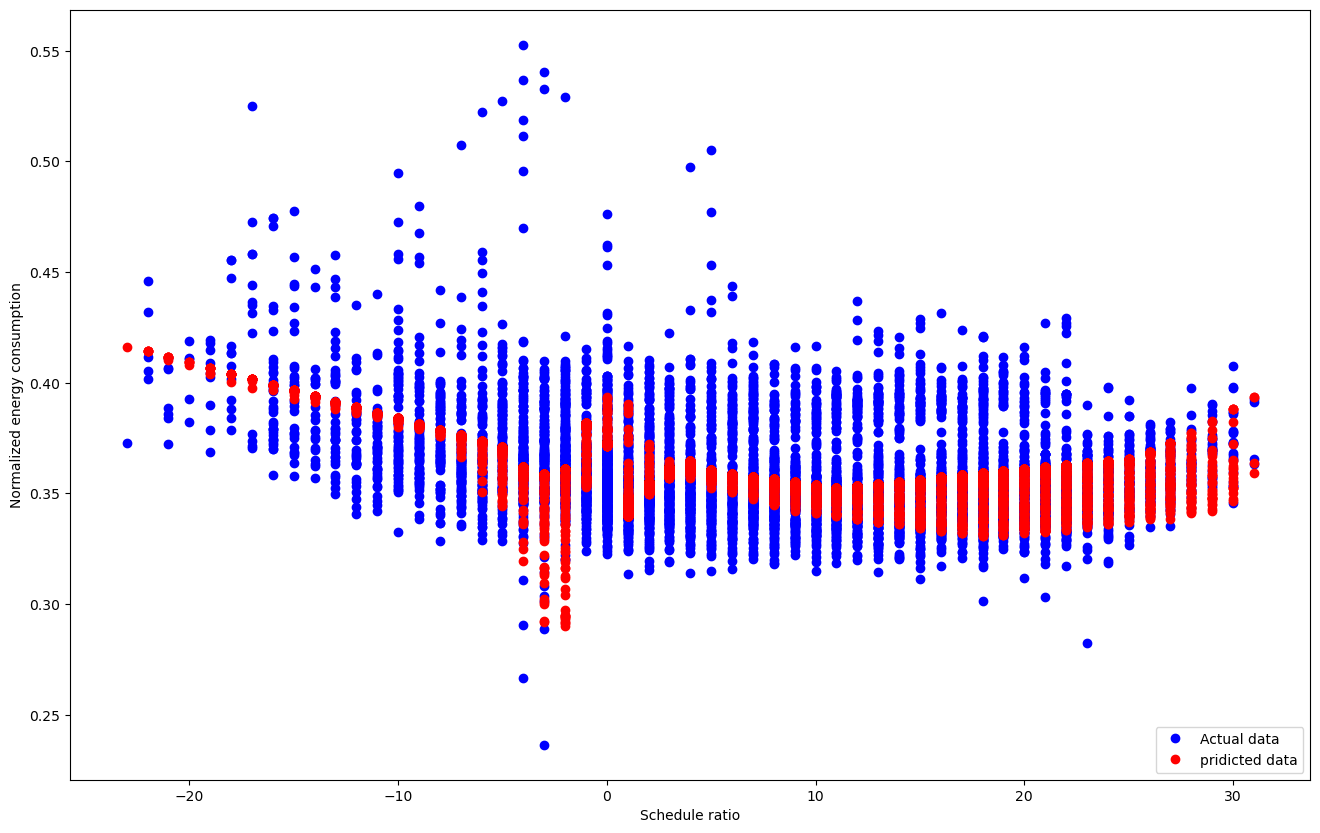

In [201]:
y_MLP=regr.predict(X)
actual=Ev1_consumption1
plt.figure(figsize=(16, 10))
plt.plot(Temprature1,y,'bo')
plt.plot(Temprature1,y_MLP,'ro')
plt.legend(["Actual data", "pridicted data"], loc ="lower right") 
plt.xlabel("Schedule ratio")
plt.ylabel("Normalized energy consumption") 
plt.show() 

In [71]:
#Fitting for Cluster 2

In [154]:
Ev1_consumption2=np.zeros(consumption_cl2.shape[0]*consumption_cl2.shape[1]).reshape(consumption_cl2.shape[0]*consumption_cl2.shape[1],1)
Ev1_consumption2_clean=np.zeros(consumption_cl2.shape[0]*consumption_cl2.shape[1]).reshape(consumption_cl2.shape[0]*consumption_cl2.shape[1],1)
Time2=np.zeros(consumption_cl2.shape[0]*consumption_cl2.shape[1]).reshape(consumption_cl2.shape[0]*consumption_cl2.shape[1],1)
Time2_1=np.zeros(consumption_cl2.shape[0]*consumption_cl2.shape[1]).reshape(consumption_cl2.shape[0]*consumption_cl2.shape[1],1)
Sch2=np.zeros(consumption_cl2.shape[0]*consumption_cl2.shape[1]).reshape(consumption_cl2.shape[0]*consumption_cl2.shape[1],1)
Ocup2=np.zeros(consumption_cl2.shape[0]*consumption_cl2.shape[1]).reshape(consumption_cl2.shape[0]*consumption_cl2.shape[1],1)
Temprature2=np.zeros(consumption_cl2.shape[0]*consumption_cl2.shape[1]).reshape(consumption_cl2.shape[0]*consumption_cl2.shape[1],1)
Rad2=np.zeros(consumption_cl2.shape[0]*consumption_cl2.shape[1]).reshape(consumption_cl2.shape[0]*consumption_cl2.shape[1],1)
k=0
for i in range (consumption_cl2.shape[0]):
    t=0
    for j in range (consumption_cl2.shape[1]):
        Time2[k,0]=t
        Time2_1[k,0]=1-abs(t-12)/12
        Ocup2[k,0]=Ocu_schadule[j]
        Sch2[k,0]=schadule[j]
#         Sch2[k,0]=0.2
#         Ev1_consumption2[k,0]=consumption_cl2_N[i,j]
        Ev1_consumption2[k,0]=cl2_N[i,j]
#         Ev1_consumption2_clean[k,0]=cl2_clean[i,j]
        Temprature2[k,0]=Temp_cl2[i,j]
        Rad2[k,0]=Total_Rad_cl2[i,j]
        k=k+1
        t=t+1

Sch2[12,0]

1.0

In [156]:
temp_daily_2=average_finder(Temprature2,24)
min_temp2=temp_daily_2.min()
max_temp2=temp_daily_2.max()
print('min temprature=',min_temp2)
print('max temprature=',max_temp2)
av_temp_2=np.average(temp_daily_2)
print ("average temperature clusterav_temp_2=",av_temp_2)
# Consumption_daily_cl1=sum_finder(Ev1_consumption1,24)
# Ev1_consumption2=sum_finder(Ev1_consumption2,24)

min temprature= -2.5833333333333335
max temprature= 25.041666666666668
average temperature clusterav_temp_2= 14.168812589413449


C:\Users\User\AppData\Local\Temp\ipykernel_28392\3814052515.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x_y[j]=x[k]


In [158]:
# input_ev2=temp_daily_2
# input_ev2=Rad2
input_ev2=np.c_[Temprature2,Rad2]
# # input_ev2=np.c_[input_ev2, Sch2]
# input_ev2=np.c_[input_ev2, Ocup2]
input_ev2.shape

(5592, 2)

In [160]:
Ev1_consumption2.shape

(5592, 1)

In [68]:
# nn=Ev1_consumption2_clean.shape[0]
# ev2=average_finder(Ev1_consumption2.reshape(nn),24)
# input_ev2=average_finder(Temprature2.reshape(nn),24)

In [162]:
#Linear Regression
from sklearn.linear_model import LinearRegression
regr = LinearRegression()
actual = Ev1_consumption2
#in x get all columns except goals column

regr.fit(input_ev2,Ev1_consumption2)
#regr.predict(x)  

predict = regr.predict(input_ev2)
from sklearn.metrics import mean_squared_error
rms = mean_squared_error(actual, predict, squared=False)
print ("Mean square erro=",rms)

from sklearn.metrics import r2_score 
r2 = r2_score(actual, predict) 
print("R^2=",r2)

from sklearn.metrics import mean_absolute_percentage_error 
err=mean_absolute_percentage_error(actual, predict)
print ("error=", err*100)

Mean square erro= 0.05001778959878929
R^2= 0.4542120081815647
error= 8.6119200831347


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [70]:
regr.coef_

array([[-0.00305573, -0.03682629,  0.2892908 , -0.04437459]])

In [71]:
regr.intercept_

array([0.32892597])

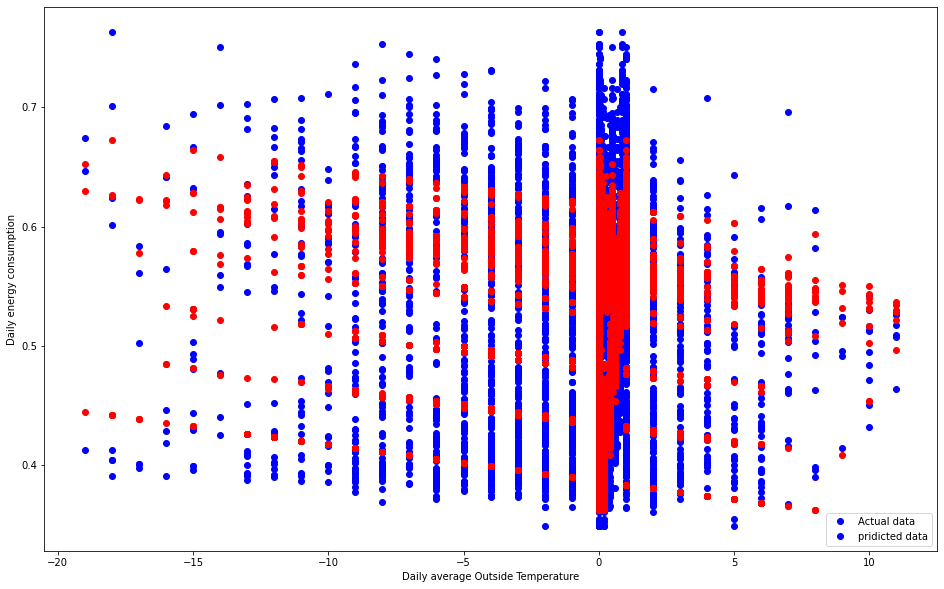

In [72]:
plt.figure(figsize=(16, 10))
plt.plot(input_ev2,actual,'bo')
plt.plot(input_ev2,predict,'ro')
plt.legend(["Actual data", "pridicted data"], loc ="lower right") 
plt.xlabel("Daily average Outside Temperature")
plt.ylabel("Daily energy consumption") 
plt.show() 

In [164]:
# Polynomial fitting 
from sklearn.preprocessing import PolynomialFeatures
regr = PolynomialFeatures(degree=2, include_bias=False)
actual = Ev1_consumption2
#in x get all columns except goals column


#regr.fit(fit_1[["Time","Temperature (C)"]],fit_1[["Energy consumption (kWh)"]])
#regr.predict(x)  
X_poly  = regr.fit_transform(input_ev2)
model = LinearRegression()
model.fit(X_poly, actual) 
y_pred = model.predict(X_poly)

#from sklearn.metrics import mean_squared_error
rms = mean_squared_error(actual, y_pred, squared=False)  
print ("meant square error=",rms)

from sklearn.metrics import r2_score 
r2 = r2_score(actual, y_pred) 
print( "R^2=",r2)

from sklearn.metrics import mean_absolute_percentage_error 
err=mean_absolute_percentage_error(actual, y_pred)
print ("MAPE=", err*100)

meant square error= 0.04634090523250449
R^2= 0.5315060230778534
MAPE= 7.748315402266651


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [166]:
# Polynomial fitting 
# Assuming:
# input_ev2 = your features (X)
# Ev1_consumption2 = your target (y)

# 1. Split data into train/test sets (80/20 split)
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    input_ev2, 
    Ev1_consumption2, 
    test_size=0.2, 
    random_state=42
)

# # 2. Scale features (critical for polynomial regression)
# scaler = StandardScaler()
# X_train_scaled2 = scaler.fit_transform(X_train2)
# X_test_scaled2 = scaler.transform(X_test2)

# 3. Generate polynomial features (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = poly.fit_transform(X_train2)
X_test_poly2 = poly.transform(X_test2)  # Important: use transform(), not fit_transform()

# 4. Train model
model = LinearRegression()
model.fit(X_train_poly2, y_train2)

# 5. Evaluate
train_pred = model.predict(X_train_poly2)
test_pred = model.predict(X_test_poly2)

# Metrics for training set (for reference)
print("=== Training Set ===")
print(f"MSE: {mean_squared_error(y_train2, train_pred):.4f}")
print(f"R²: {r2_score(y_train2, train_pred):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_train2, train_pred)*100:.2f}%")

# Metrics for test set (true performance)
print("\n=== Test Set ===")
print(f"MSE: {mean_squared_error(y_test2, test_pred):.4f}")
print(f"R²: {r2_score(y_test2, test_pred):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test2, test_pred)*100:.2f}%")

# # 6. Diagnostic Plot (Actual vs Predicted)
# import matplotlib.pyplot as plt
# plt.scatter(y_test2, test_pred, alpha=0.5)
# plt.plot([y_test2.min(), y_test2.max()], [y_test2.min(), y_test2.max()], 'k--')
# plt.xlabel("Actual Energy Consumption")
# plt.ylabel("Predicted Energy Consumption")
# plt.title("Polynomial Regression (Degree=2)")
# plt.show()

=== Training Set ===
MSE: 0.0022
R²: 0.5257
MAPE: 7.77%

=== Test Set ===
MSE: 0.0021
R²: 0.5537
MAPE: 7.74%


In [88]:
model.coef_

array([[ 1.43721240e-03,  1.65755958e-01, -2.64277916e-01,
        -7.83656809e-05, -9.95993605e-03,  4.19021980e-03,
         7.78717768e-02,  2.38367355e-01, -1.21745851e-02]])

In [89]:
model.intercept_

array([0.36738414])

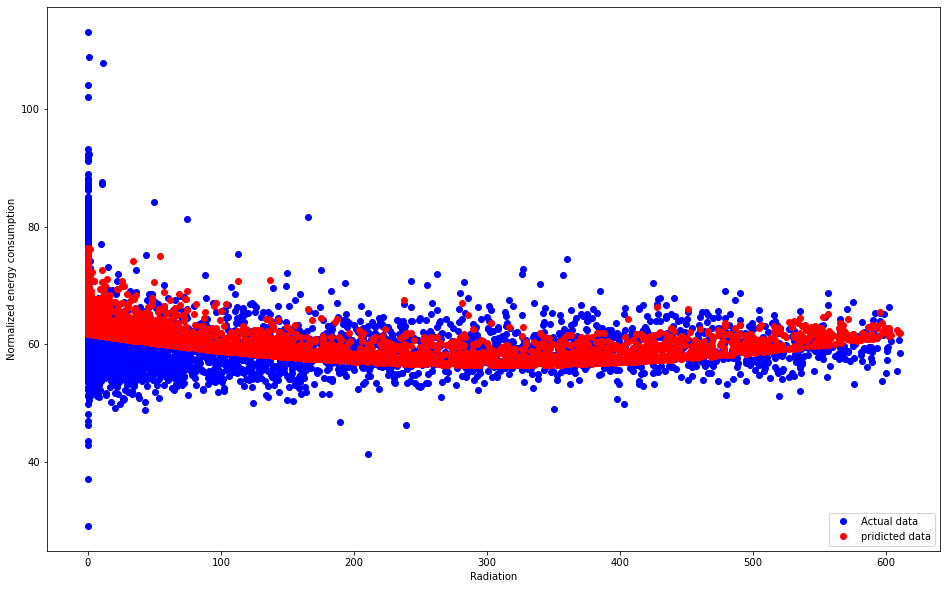

In [237]:
plt.figure(figsize=(16, 10))
plt.plot(Rad2,actual,'bo')
plt.plot(Rad2,y_pred,'ro')
plt.legend(["Actual data", "pridicted data"], loc ="lower right") 
plt.xlabel("Radiation")
plt.ylabel("Normalized energy consumption") 
plt.show() 

In [ ]:
# input_ev2=Temprature2
# input_ev2=np.c_[Rad2, Time2]
# input_ev2=np.c_[input_ev2, Rad2]
# input_ev2

In [238]:
#Neural network
from sklearn.neural_network import MLPRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
#mlp = MLPRegressor(hidden_layer_sizes=(200, 100))
#X, y = make_regression(n_samples=200, random_state=1)
X =input_ev2
y =Ev1_consumption2
X_train, X_test, y_train, y_test = train_test_split(X, y,random_state=1)
regr = MLPRegressor(random_state=1, max_iter=500).fit(X_train, y_train)
#regr=mlp.fit(X_train, y_train)
regr.predict(X_test[:2])
regr.score(X_test, y_test)

C:\Users\e3akbari\anaconda3\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


0.2691693930900112

In [176]:
#Neural network (MLP) optimized byGrid search with Cross-Validation

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

X =input_ev2
y =Ev1_consumption2
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, random_state=1)

# # Scale the data (important for neural networks)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# Define the parameter grid
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (1000,), (50,50), (100,50), (200,100)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['adam', 'lbfgs'],
    'alpha': [0.0001, 0.001, 0.01],  # L2 regularization
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [500, 1000],
    'early_stopping': [True],
    'validation_fraction': [0.1]
}

# Create the MLPRegressor
mlp = MLPRegressor(random_state=1)

# Create GridSearchCV object
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)

# Fit the model
grid_search.fit(X_train2, y_train2)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

# Evaluate on test set
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test2, y_test2)
print("Test score: ", test_score)

Fitting 5 folds for each of 864 candidates, totalling 4320 fits


C:\Users\User\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1624: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters found:  {'activation': 'relu', 'alpha': 0.0001, 'early_stopping': True, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_iter': 500, 'solver': 'adam', 'validation_fraction': 0.1}
Best score:  0.5326146945534864
Test score:  0.5440147124987118


In [188]:
###MPL optimization using optuna

import optuna
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import numpy as np

# Load your data
X = input_ev2
y = Ev1_consumption2

# Split data
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale data
scaler = StandardScaler()
X_train_scaled2= scaler.fit_transform(X_train2)
X_test_scaled2 = scaler.transform(X_test2)

def objective(trial):
    # Define hyperparameter search space
    params = {
        'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes', 
                                      [(50,), (100,), (1000,), (50,50), (100,50), (200,100)]),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh', 'logistic']),
        'solver': trial.suggest_categorical('solver', ['adam', 'lbfgs']),
        'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        'learning_rate': trial.suggest_categorical('learning_rate', ['constant', 'adaptive']),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [16, 32, 64, 128]),
        'max_iter': 10000,
        'early_stopping': True,
        'random_state': 42
    }
    
    # Create and evaluate model
    model = MLPRegressor(**params)
    
    # Use cross-validation instead of a single train/validation split
    scores = cross_val_score(model, X_train_scaled2, y_train2, cv=5, scoring='r2', n_jobs=-1)
    # scores = cross_val_score(model, X_train2, y_train2, cv=5, scoring='r2', n_jobs=-1)
    
    # Return the mean validation score
    return np.mean(scores)

# Create Optuna study
study = optuna.create_study(direction='maximize')  # We maximize R² score
study.optimize(objective, n_trials=250)  # Number of trials

# Best trial results
print(f"Best trial R² score: {study.best_value:.4f}")
print("Best parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Train final model with best parameters
best_model_2 = MLPRegressor(**study.best_params)
best_model_2.fit(X_train_scaled2, y_train2)
# best_model.fit(X_train2, y_train2)

# Evaluate on test set
test_r2 = best_model_2.score(X_test_scaled2, y_test2)
# test_r2 = best_model.score(X_test2, y_test2)
print(f"\nTest R² score: {test_r2:.4f}")

[I 2025-05-21 13:31:23,433] A new study created in memory with name: no-name-e8163491-e6bc-4379-9983-2365eacd0d4d
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50,) which is of type tuple.
  warnings.warn(message)
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  warnings.warn(message)
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1000,) which is of type tuple.
  warnings.warn(message)
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: C

Best trial R² score: 0.5602
Best parameters:
  hidden_layer_sizes: (200, 100)
  activation: relu
  solver: lbfgs
  alpha: 0.0672218668229349
  learning_rate: constant
  learning_rate_init: 0.0012566233899551464
  batch_size: 64

Test R² score: 0.5681


In [193]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

# 1. Get predictions
y_train_pred2 = best_model_2.predict(X_train_scaled2)
y_test_pred2 = best_model_2.predict(X_test_scaled2)

# 2. Calculate metrics
metrics = {
    'MSE': {
        'train': mean_squared_error(y_train2, y_train_pred2),
        'test': mean_squared_error(y_test2, y_test_pred2)
    },
    'RMSE': {
        'train': np.sqrt(mean_squared_error(y_train2, y_train_pred2)),
        'test': np.sqrt(mean_squared_error(y_test2, y_test_pred2))
    },
    'R²': {
        'train': r2_score(y_train2, y_train_pred2),
        'test': r2_score(y_test2, y_test_pred2)
    },
    'MAPE (%)': {
        'train': mean_absolute_percentage_error(y_train2, y_train_pred2) * 100,
        'test': mean_absolute_percentage_error(y_test2, y_test_pred2) * 100
    }
}

# 3. Print results in a clean table
print("\n" + "="*50)
print(f"{'Metric':<20}{'Training Set':>15}{'Test Set':>15}")
print("="*50)
for metric_name, values in metrics.items():
    print(f"{metric_name:<20}{values['train']:>15.4f}{values['test']:>15.4f}")
print("="*50)


Metric                 Training Set       Test Set
MSE                          0.0021         0.0020
RMSE                         0.0459         0.0449
R²                           0.5391         0.5681
MAPE (%)                     7.6379         7.6008


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred2 = best_model.predict(X_test2)
print(f"MSE: {mean_squared_error(y_test2, y_pred2):.4f}")
print(f"MAE: {mean_absolute_error(y_test2, y_pred2):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test2, y_pred2)):.4f}")

In [239]:
pre=regr.predict(X)
from sklearn.metrics import mean_squared_error
rms = mean_squared_error(y, pre, squared=False)  
print ("Mean square error=", rms)

from sklearn.metrics import mean_absolute_percentage_error 
err=mean_absolute_percentage_error(y, pre)*100
print ("error=", err)

Mean square error= 4.869007730280185
error= 5.774985746942955


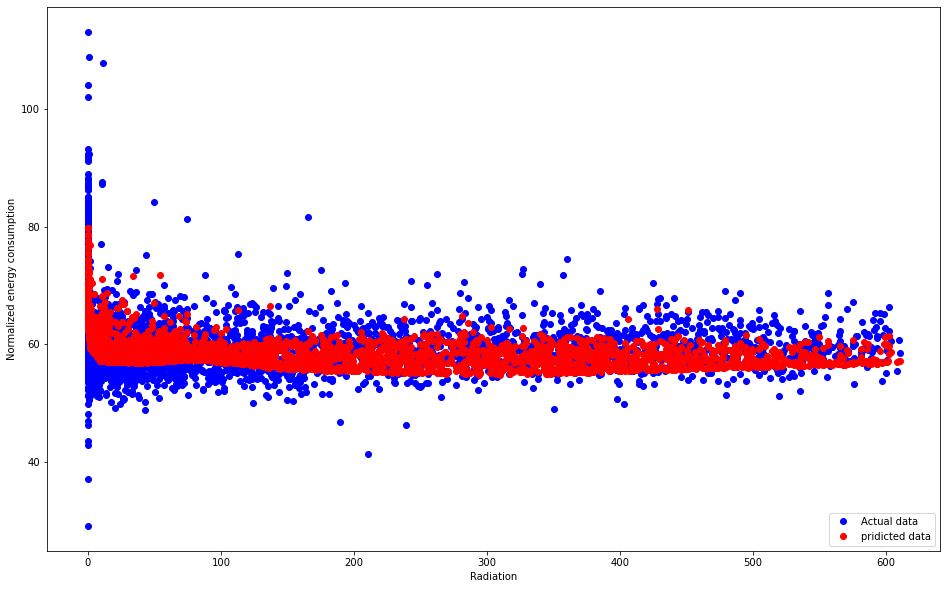

In [240]:
y_MLP=regr.predict(X)
actual=Ev1_consumption2
plt.figure(figsize=(16, 10))
plt.plot(Rad2,y,'bo')
plt.plot(Rad2,y_MLP,'ro')
plt.legend(["Actual data", "pridicted data"], loc ="lower right") 
plt.xlabel("Radiation")
plt.ylabel("Normalized energy consumption") 
plt.show() 

In [241]:
#Fitting for Cluster 3

In [195]:
Ev1_consumption3=np.zeros(consumption_cl3.shape[0]*consumption_cl3.shape[1]).reshape(consumption_cl3.shape[0]*consumption_cl3.shape[1],1)
Ev1_consumption3_clean=np.zeros(consumption_cl3.shape[0]*consumption_cl3.shape[1]).reshape(consumption_cl3.shape[0]*consumption_cl3.shape[1],1)
Time3=np.zeros(consumption_cl3.shape[0]*consumption_cl3.shape[1]).reshape(consumption_cl3.shape[0]*consumption_cl3.shape[1],1)
Time3_1=np.zeros(consumption_cl3.shape[0]*consumption_cl3.shape[1]).reshape(consumption_cl3.shape[0]*consumption_cl3.shape[1],1)
Sch3=np.zeros(consumption_cl3.shape[0]*consumption_cl3.shape[1]).reshape(consumption_cl3.shape[0]*consumption_cl3.shape[1],1)
Ocup3=np.zeros(consumption_cl3.shape[0]*consumption_cl3.shape[1]).reshape(consumption_cl3.shape[0]*consumption_cl3.shape[1],1)
Temprature3=np.zeros(consumption_cl3.shape[0]*consumption_cl3.shape[1]).reshape(consumption_cl3.shape[0]*consumption_cl3.shape[1],1)
Rad3=np.zeros(consumption_cl3.shape[0]*consumption_cl3.shape[1]).reshape(consumption_cl3.shape[0]*consumption_cl3.shape[1],1)
k=0
for i in range (consumption_cl3.shape[0]):
    t=0
    for j in range (consumption_cl3.shape[1]):
        Time3[k,0]=t
        Time3_1[k,0]=1-abs(t-12)/12
        Sch3[k,0]=schadule[j]
        Ocup3[k,0]=Ocu_schadule[j]
#         Ev1_consumption3[k,0]=consumption_cl3_N[i,j]
        Ev1_consumption3[k,0]=consumption_cl3_N[i,j]
#         Ev1_consumption3_clean[k,0]=cl3_clean[i,j]
        Temprature3[k,0]=Temp_cl3[i,j]
        Rad3[k,0]=Total_Rad_cl3[i,j]
        k=k+1
        t=t+1

Sch3[12,0]

1.0

In [197]:
# temp_daily_3=average_finder(Temprature3,24)
# min_temp3=temp_daily_3.min()
# max_temp3=temp_daily_3.max()
# print('min temprature=',min_temp3)
# print('max temprature=',max_temp3)
# av_temp_3=np.average(temp_daily_3)
# print ("average temperature clusterav_temp_3=",av_temp_3)
# Consumption_daily_cl1=sum_finder(Ev1_consumption1,24)
# Ev1_consumption3=sum_finder(Ev1_consumption3,24)

In [199]:
# input_ev3=temp_daily_3
# input_ev3=Temprature3
# input_ev3=Ocup3
input_ev3=np.c_[Temprature3, Rad3]
# input_ev3=np.c_[input_ev3, Sch3]
# input_ev3=np.c_[input_ev3, Ocup3]
input_ev3

array([[-9.,  0.],
       [-8.,  0.],
       [-7.,  0.],
       ...,
       [ 0.,  0.],
       [-1.,  0.],
       [-1.,  0.]])

In [133]:
#Linear Regression
from sklearn.linear_model import LinearRegression
regr = LinearRegression()
actual = Ev1_consumption3
#in x get all columns except goals column

regr.fit(input_ev3,Ev1_consumption3)
#regr.predict(x)  

predict = regr.predict(input_ev3)
from sklearn.metrics import mean_squared_error
rms = mean_squared_error(actual, predict, squared=False)
print ("Mean square erro=",rms)

from sklearn.metrics import r2_score 
r2 = r2_score(actual, predict) 
print("R^2=",r2)

from sklearn.metrics import mean_absolute_percentage_error 
err=mean_absolute_percentage_error(actual, predict)
print ("error=", err*100)

Mean square erro= 0.03716432665337216
R^2= 0.2503977508029205
error= 6.717906158947999


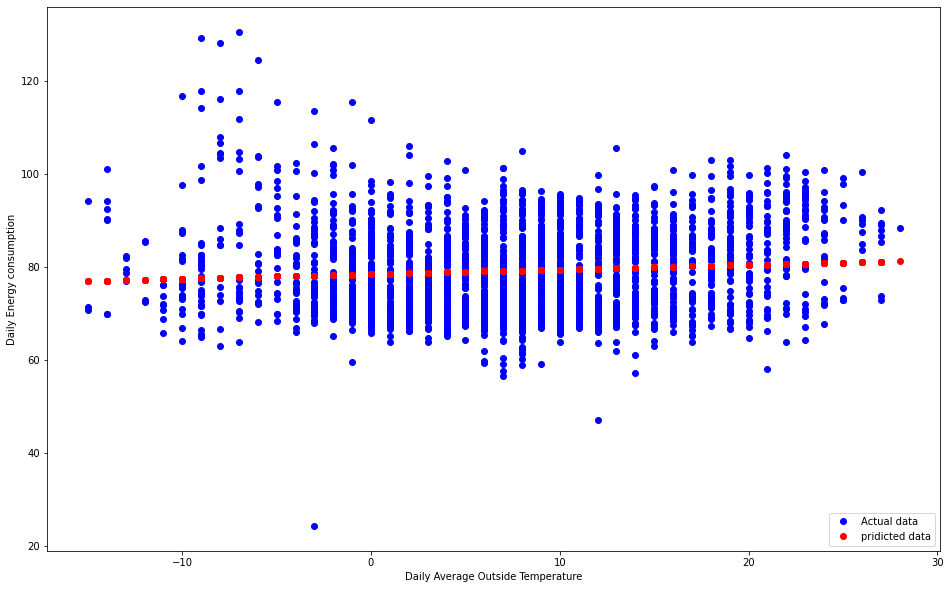

In [249]:
plt.figure(figsize=(16, 10))
plt.plot(Temprature3,actual,'bo')
plt.plot(Temprature3,predict,'ro')
plt.legend(["Actual data", "pridicted data"], loc ="lower right") 
plt.xlabel("Daily Average Outside Temperature")
plt.ylabel("Daily Energy consumption") 
plt.show() 

In [242]:
# Polynomial fitting 
from sklearn.preprocessing import PolynomialFeatures
regr = PolynomialFeatures(degree=2, include_bias=False)
actual = Ev1_consumption3
#in x get all columns except goals column


#regr.fit(fit_1[["Time","Temperature (C)"]],fit_1[["Energy consumption (kWh)"]])
#regr.predict(x)  
X_poly  = regr.fit_transform(input_ev3)
model = LinearRegression()
model.fit(X_poly, actual) 
y_pred = model.predict(X_poly)

#from sklearn.metrics import mean_squared_error
rms = mean_squared_error(actual, y_pred, squared=False)  
print ("meant square error=",rms)

from sklearn.metrics import r2_score 
r2 = r2_score(actual, y_pred) 
print( "R^2=",r2)

from sklearn.metrics import mean_absolute_percentage_error 
err=mean_absolute_percentage_error(actual, y_pred)
print ("error=", err*100)

meant square error= 0.13635377021142528
R^2= 0.09143991527334072
error= 21.94637833677596


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [302]:
# Polynomial fitting 
# Assuming:
# input_ev3 = your features (X)
# Ev1_consumption3 = your target (y)

# 1. Split data into train/test sets (80/20 split)
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    input_ev3, 
    Ev1_consumption3, 
    test_size=0.2, 
    random_state=42
)

# # 2. Scale features (critical for polynomial regression)
# scaler = StandardScaler()
# X_train_scaled3 = scaler.fit_transform(X_train3)
# X_test_scaled3 = scaler.transform(X_test3)

# 3. Generate polynomial features (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly3 = poly.fit_transform(X_train3)
X_test_poly3 = poly.transform(X_test3)  # Important: use transform(), not fit_transform()

# 4. Train model
model = LinearRegression()
model.fit(X_train_poly3, y_train3)

# 5. Evaluate
train_pred = model.predict(X_train_poly3)
test_pred = model.predict(X_test_poly3)

# Metrics for training set (for reference)
print("=== Training Set ===")
print(f"MSE: {mean_squared_error(y_train3, train_pred):.4f}")
print(f"R²: {r2_score(y_train3, train_pred):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_train3, train_pred)*100:.2f}%")

# Metrics for test set (true performance)
print("\n=== Test Set ===")
print(f"MSE: {mean_squared_error(y_test3, test_pred):.4f}")
print(f"R²: {r2_score(y_test3, test_pred):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test3, test_pred)*100:.2f}%")



=== Training Set ===
MSE: 0.0181
R²: 0.0951
MAPE: 21.80%

=== Test Set ===
MSE: 0.0205
R²: 0.0766
MAPE: 22.44%


In [97]:
model.coef_

array([[-3.86429747e-03,  2.96274291e-01, -1.97978561e-01,
        -8.10231034e-05,  2.86364251e-03,  1.33182661e-03,
        -1.77819625e-01,  1.91000287e-01, -1.06269154e-02]])

In [98]:
model.intercept_

array([0.34481452])

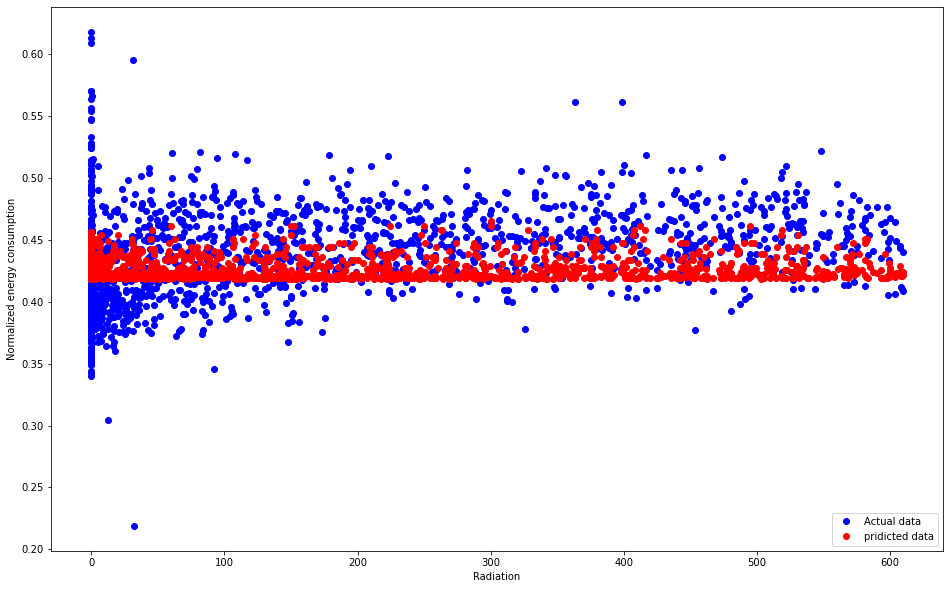

In [251]:
plt.figure(figsize=(16, 10))
plt.plot(Rad3,actual,'bo')
plt.plot(Rad3,y_pred,'ro')
plt.legend(["Actual data", "pridicted data"], loc ="lower right") 
plt.xlabel("Radiation")
plt.ylabel("Normalized energy consumption") 
plt.show() 

In [ ]:
# input_ev2=Temprature3
# input_ev3=np.c_[Temprature3, Time3_1]
# input_ev3=np.c_[input_ev3, Rad3]
# input_ev3

In [119]:
# #Neural network
# from sklearn.neural_network import MLPRegressor
# from sklearn.datasets import make_regression
# from sklearn.model_selection import train_test_split
# #mlp = MLPRegressor(hidden_layer_sizes=(200, 100))
# #X, y = make_regression(n_samples=200, random_state=1)
# X =input_ev3
# y =Ev1_consumption3
# X_train, X_test, y_train, y_test = train_test_split(X, y,random_state=1)
# regr = MLPRegressor(random_state=1, max_iter=500).fit(X_train, y_train)
# #regr=mlp.fit(X_train, y_train)
# regr.predict(X_test[:2])
# regr.score(X_test, y_test)

C:\Users\e3akbari\anaconda3\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


-1.0636175243583952

In [597]:
# pre=regr.predict(X)
# from sklearn.metrics import mean_squared_error
# rms = mean_squared_error(y, pre, squared=False)  
# print ("Mean square error=", rms)

# from sklearn.metrics import mean_absolute_percentage_error 
# err=mean_absolute_percentage_error(y, pre)*100
# print ("error=", err)

Mean square error= 0.10539558882271007
error= 14.464802892633696


In [246]:
#Neural network (MLP) optimized by grid search

X =input_ev3
y =Ev1_consumption3
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y, random_state=1)

# # Scale the data (important for neural networks)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train3)
# X_test_scaled = scaler.transform(X_test3)

# Define the parameter grid
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50,50), (100,50), (200,100)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['adam', 'lbfgs'],
    'alpha': [0.0001, 0.001, 0.01],  # L2 regularization
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [500, 1000],
    'early_stopping': [True],
    'validation_fraction': [0.1]
}

# Create the MLPRegressor
mlp = MLPRegressor(random_state=1)

# Create GridSearchCV object
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)

# Fit the model
grid_search.fit(X_train3, y_train3)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

# Evaluate on test set
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test3, y_test3)
print("Test score: ", test_score)

Fitting 5 folds for each of 720 candidates, totalling 3600 fits


C:\Users\User\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1624: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters found:  {'activation': 'tanh', 'alpha': 0.01, 'early_stopping': True, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_iter': 1000, 'solver': 'lbfgs', 'validation_fraction': 0.1}
Best score:  0.18547148388709525
Test score:  0.07205829711543643


C:\Users\User\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [211]:
###MPL optimization using optuna

import optuna
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import numpy as np

# Load your data
X = input_ev3
y = Ev1_consumption3

# Split data
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale data
scaler = StandardScaler()
X_train_scaled3= scaler.fit_transform(X_train3)
X_test_scaled3 = scaler.transform(X_test3)

def objective(trial):
    # Define hyperparameter search space
    params = {
        'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes', 
                                      [(50,), (100,), (1000,), (50,50), (100,50), (200,100)]),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh', 'logistic']),
        'solver': trial.suggest_categorical('solver', ['adam', 'lbfgs']),
        'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        'learning_rate': trial.suggest_categorical('learning_rate', ['constant', 'adaptive']),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [16, 32, 64, 128]),
        'max_iter': 10000,
        'early_stopping': True,
        'random_state': 42
    }
    
    # Create and evaluate model
    model = MLPRegressor(**params)
    
    # Use cross-validation instead of a single train/validation split
    scores = cross_val_score(model, X_train_scaled3, y_train3, cv=5, scoring='r2', n_jobs=-1)
    # scores = cross_val_score(model, X_train2, y_train2, cv=5, scoring='r2', n_jobs=-1)
    
    # Return the mean validation score
    return np.mean(scores)

# Create Optuna study
study = optuna.create_study(direction='maximize')  # We maximize R² score
study.optimize(objective, n_trials=250)  # Number of trials

# Best trial results
print(f"Best trial R² score: {study.best_value:.4f}")
print("Best parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Train final model with best parameters
best_model_3 = MLPRegressor(**study.best_params)
best_model_3.fit(X_train_scaled3, y_train3)
# best_model.fit(X_train2, y_train2)

# Evaluate on test set
test_r2 = best_model_3.score(X_test_scaled3, y_test3)
# test_r2 = best_model_3.score(X_test3, y_test3)
print(f"\nTest R² score: {test_r2:.4f}")

[I 2025-05-21 14:00:04,488] A new study created in memory with name: no-name-04b6d976-93e9-45c1-a5a8-115504a89bda
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50,) which is of type tuple.
  warnings.warn(message)
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  warnings.warn(message)
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1000,) which is of type tuple.
  warnings.warn(message)
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: C

Best trial R² score: 0.2286
Best parameters:
  hidden_layer_sizes: (50,)
  activation: relu
  solver: lbfgs
  alpha: 0.023327767157966386
  learning_rate: constant
  learning_rate_init: 0.0001215826242552369
  batch_size: 128

Test R² score: 0.1863


C:\Users\User\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1624: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\User\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [213]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

# 1. Get predictions
y_train_pred3 = best_model_3.predict(X_train_scaled3)
y_test_pred3 = best_model_3.predict(X_test_scaled3)

# 2. Calculate metrics
metrics = {
    'MSE': {
        'train': mean_squared_error(y_train3, y_train_pred3),
        'test': mean_squared_error(y_test3, y_test_pred3)
    },
    'RMSE': {
        'train': np.sqrt(mean_squared_error(y_train3, y_train_pred3)),
        'test': np.sqrt(mean_squared_error(y_test3, y_test_pred3))
    },
    'R²': {
        'train': r2_score(y_train3, y_train_pred3),
        'test': r2_score(y_test3, y_test_pred3)
    },
    'MAPE (%)': {
        'train': mean_absolute_percentage_error(y_train3, y_train_pred3) * 100,
        'test': mean_absolute_percentage_error(y_test3, y_test_pred3) * 100
    }
}

# 3. Print results in a clean table
print("\n" + "="*50)
print(f"{'Metric':<20}{'Training Set':>15}{'Test Set':>15}")
print("="*50)
for metric_name, values in metrics.items():
    print(f"{metric_name:<20}{values['train']:>15.4f}{values['test']:>15.4f}")
print("="*50)


Metric                 Training Set       Test Set
MSE                          0.0149         0.0181
RMSE                         0.1219         0.1344
R²                           0.2581         0.1863
MAPE (%)                    18.4820        19.6219


In [247]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred3 = best_model.predict(X_test3)
print(f"MSE: {mean_squared_error(y_test3, y_pred3):.4f}")
print(f"MAE: {mean_absolute_error(y_test3, y_pred3):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test3, y_pred3)):.4f}")

MSE: 0.0173
MAE: 0.1118
RMSE: 0.1315


ValueError: x and y must have same first dimension, but have shapes (1104, 1) and (221,)

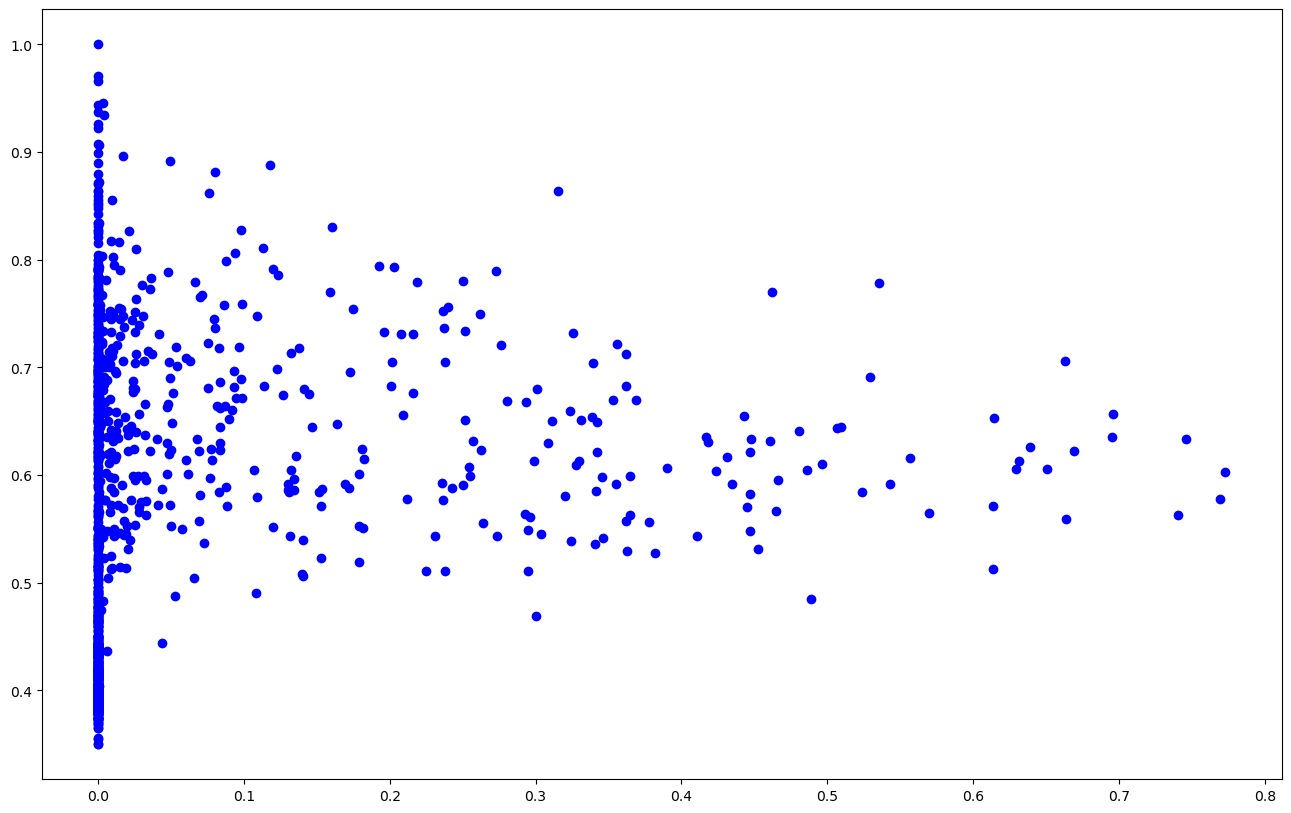

In [304]:
actual=Ev1_consumption3
# y_MLP=regr.predict(X)
y_MLP=best_model.predict(X_test3)
plt.figure(figsize=(16, 10))
plt.plot(Rad3,actual,'bo')
plt.plot(Rad3,y_MLP,'ro')
plt.legend(["Actual data", "pridicted data"], loc ="lower right") 
plt.xlabel("Radiation")
plt.ylabel("Normalized energy consumption") 
plt.show() 

In [ ]:
#Fitting Cluster 4

In [205]:
Ev1_consumption4=np.zeros(consumption_cl4.shape[0]*consumption_cl4.shape[1]).reshape(consumption_cl4.shape[0]*consumption_cl4.shape[1],1)
Ev1_consumption4_clean=np.zeros(consumption_cl4.shape[0]*consumption_cl4.shape[1]).reshape(consumption_cl4.shape[0]*consumption_cl4.shape[1],1)
Time4=np.zeros(consumption_cl4.shape[0]*consumption_cl4.shape[1]).reshape(consumption_cl4.shape[0]*consumption_cl4.shape[1],1)
Time4_1=np.zeros(consumption_cl4.shape[0]*consumption_cl4.shape[1]).reshape(consumption_cl4.shape[0]*consumption_cl4.shape[1],1)
Sch4=np.zeros(consumption_cl4.shape[0]*consumption_cl4.shape[1]).reshape(consumption_cl4.shape[0]*consumption_cl4.shape[1],1)
Ocup4=np.zeros(consumption_cl4.shape[0]*consumption_cl4.shape[1]).reshape(consumption_cl4.shape[0]*consumption_cl4.shape[1],1)
Temprature4=np.zeros(consumption_cl4.shape[0]*consumption_cl4.shape[1]).reshape(consumption_cl4.shape[0]*consumption_cl4.shape[1],1)
Rad4=np.zeros(consumption_cl4.shape[0]*consumption_cl4.shape[1]).reshape(consumption_cl4.shape[0]*consumption_cl4.shape[1],1)
k=0
for i in range (consumption_cl4.shape[0]):
    t=0
    for j in range (consumption_cl4.shape[1]):
        Time4[k,0]=t
        Time4_1[k,0]=1-abs(t-12)/12
        Sch4[k,0]=schadule[j]
        Ocup4[k,0]=Ocu_schadule[j]
#         Ev1_consumption4[k,0]=consumption_cl4[i,j]
        Ev1_consumption4[k,0]=consumption_cl4_N[i,j]
#         Ev1_consumption4_clean[k,0]=cl4_clean[i,j]
        Temprature4[k,0]=Temp_cl4[i,j]
        Rad4[k,0]=Total_Rad_cl4[i,j]
        k=k+1
        t=t+1

Time4_1[12,0]

1.0

In [207]:
temp_daily_4=average_finder(Temprature4,24)
min_temp4=temp_daily_4.min()
max_temp4=temp_daily_4.max()
print('min temprature=',min_temp4)
print('max temprature=',max_temp4)
av_temp_4=np.average(temp_daily_4)
print ("average temperature clusterav_temp_3=",av_temp_4)
# Consumption_daily_cl1=sum_finder(Ev1_consumption1,24)
# Ev1_consumption4=sum_finder(Ev1_consumption4,24)

min temprature= -11.333333333333334
max temprature= 23.125
average temperature clusterav_temp_3= 9.389136904761903


C:\Users\User\AppData\Local\Temp\ipykernel_28392\3814052515.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x_y[j]=x[k]


In [209]:
# input_ev4=temp_daily_4
# input_ev4= Rad4
input_ev4=np.c_[Temprature4, Rad4]
# input_ev4=np.c_[input_ev4, Sch4]
# input_ev4=np.c_[input_ev4, Ocup4]
input_ev4

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [2., 0.],
       [2., 0.],
       [1., 0.]])

In [66]:
#Linear Regression
from sklearn.linear_model import LinearRegression
regr = LinearRegression()
actual = Ev1_consumption4
#in x get all columns except goals column

regr.fit(input_ev4,Ev1_consumption4)
#regr.predict(x)  

predict = regr.predict(input_ev4)
from sklearn.metrics import mean_squared_error
rms = mean_squared_error(actual, predict, squared=False)
print ("Mean square erro=",rms)

from sklearn.metrics import r2_score 
r2 = r2_score(actual, predict) 
print("R^2=",r2)

from sklearn.metrics import mean_absolute_percentage_error 
err=mean_absolute_percentage_error(actual, predict)
print ("MAPE=", err*100)

Mean square erro= 0.0753438005191671
R^2= 0.7266635007164075
MAPE= 10.049871122358397


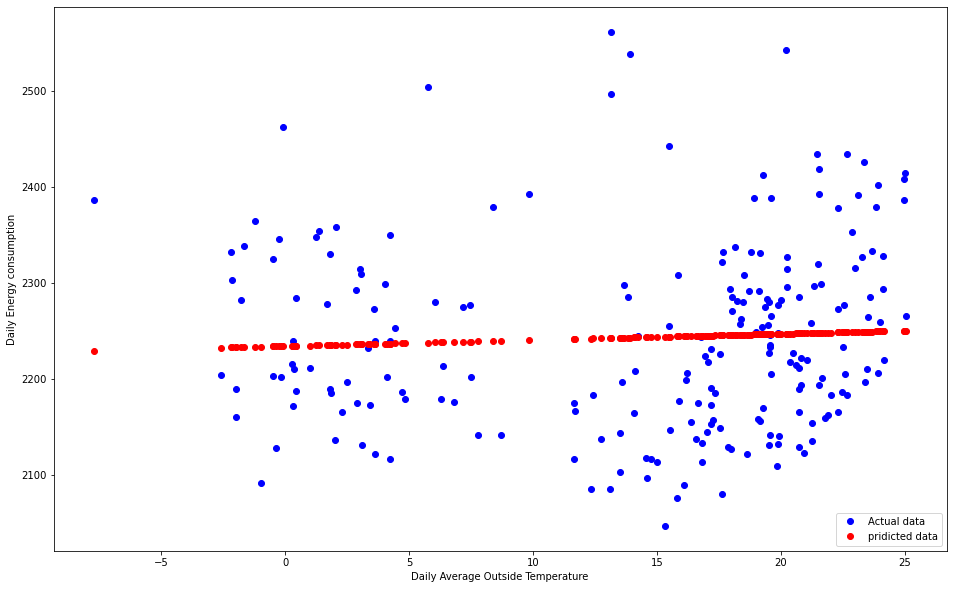

In [103]:
plt.figure(figsize=(16, 10))
plt.plot(temp_daily_4,actual,'bo')
plt.plot(temp_daily_4,predict,'ro')
plt.legend(["Actual data", "pridicted data"], loc ="lower right") 
plt.xlabel("Daily Average Outside Temperature")
plt.ylabel("Daily Energy consumption") 
plt.show() 

In [258]:
# Polynomial fitting 
from sklearn.preprocessing import PolynomialFeatures
regr = PolynomialFeatures(degree=2, include_bias=False)
actual = Ev1_consumption4
#in x get all columns except goals column


#regr.fit(fit_1[["Time","Temperature (C)"]],fit_1[["Energy consumption (kWh)"]])
#regr.predict(x)  
X_poly  = regr.fit_transform(input_ev4)
model = LinearRegression()
model.fit(X_poly, actual) 
y_pred = model.predict(X_poly)

#from sklearn.metrics import mean_squared_error
rms = mean_squared_error(actual, y_pred, squared=False)  
print ("meant square error=",rms)

from sklearn.metrics import r2_score 
r2 = r2_score(actual, y_pred) 
print( "R^2=",r2)

from sklearn.metrics import mean_absolute_percentage_error 
err=mean_absolute_percentage_error(actual, y_pred)
print ("MAPE=", err*100)

meant square error= 0.035311965909398814
R^2= 0.36943642575245206
MAPE= 6.34566517308229


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [290]:
# Polynomial fitting 
# Assuming:
# input_ev4 = your features (X)
# Ev1_consumption4 = your target (y)

# 1. Split data into train/test sets (80/20 split)
X_train4, X_test4, y_train4, y_test4 = train_test_split(
    input_ev4, 
    Ev1_consumption4, 
    test_size=0.3, 
    random_state=2
)

# # 2. Scale features (critical for polynomial regression)
# scaler = StandardScaler()
# X_train_scaled4 = scaler.fit_transform(X_train4)
# X_test_scaled4 = scaler.transform(X_test4)

# 3. Generate polynomial features (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly4 = poly.fit_transform(X_train4)
X_test_poly4 = poly.transform(X_test4)  # Important: use transform(), not fit_transform()

# 4. Train model
model = LinearRegression()
model.fit(X_train_poly4, y_train4)

# 5. Evaluate
train_pred = model.predict(X_train_poly4)
test_pred = model.predict(X_test_poly4)

# Metrics for training set (for reference)
print("=== Training Set ===")
print(f"MSE: {mean_squared_error(y_train4, train_pred):.4f}")
print(f"R²: {r2_score(y_train4, train_pred):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_train4, train_pred)*100:.2f}%")

# Metrics for test set (true performance)
print("\n=== Test Set ===")
print(f"MSE: {mean_squared_error(y_test4, test_pred):.4f}")
print(f"R²: {r2_score(y_test4, test_pred):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test4, test_pred)*100:.2f}%")

=== Training Set ===
MSE: 0.0012
R²: 0.3851
MAPE: 6.30%

=== Test Set ===
MSE: 0.0013
R²: 0.3303
MAPE: 6.38%


In [111]:
model.coef_

array([[-1.11709320e-03,  9.73484018e-01, -1.26163586e+00,
        -1.95817830e-04, -7.46653642e-03,  1.60225398e-03,
        -4.50489620e-01,  1.13308719e+00, -1.37484844e-02]])

In [112]:
model.intercept_

array([0.23097793])

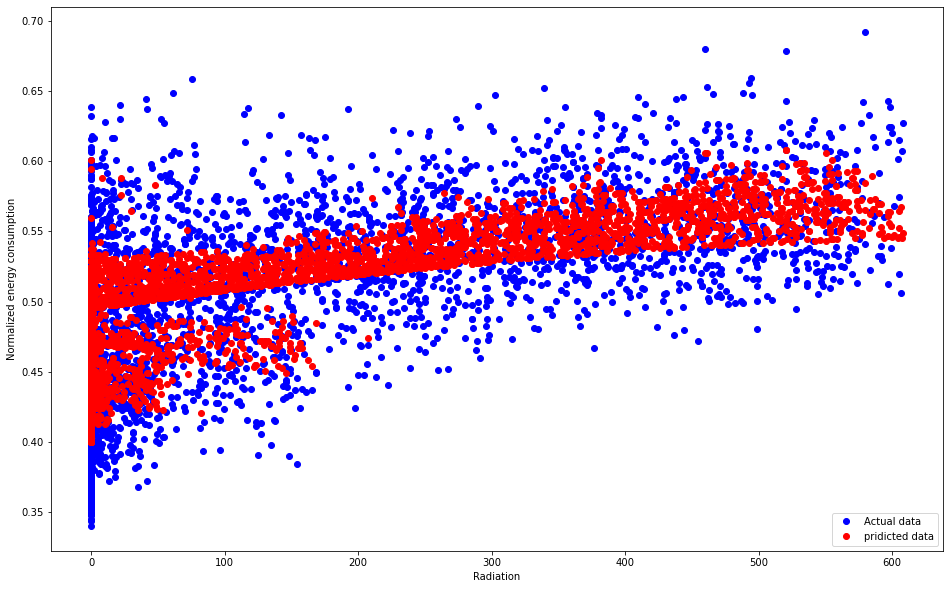

In [344]:
plt.figure(figsize=(16, 10))
plt.plot(Rad4,actual,'bo')
plt.plot(Rad4,y_pred,'ro')
plt.legend(["Actual data", "pridicted data"], loc ="lower right") 
plt.xlabel("Radiation")
plt.ylabel("Normalized energy consumption") 
plt.show() 

In [359]:
# input_ev4=Rad4
# input_ev4=np.c_[Temprature4,Rad4]
# # input_ev4=np.c_[input_ev4, Rad4]
# # input_ev4

In [610]:
# #Neural network
# from sklearn.neural_network import MLPRegressor
# from sklearn.datasets import make_regression
# from sklearn.model_selection import train_test_split
# #mlp = MLPRegressor(hidden_layer_sizes=(200, 100))
# #X, y = make_regression(n_samples=200, random_state=1)
# X =input_ev4
# y =Ev1_consumption4_clean
# X_train, X_test, y_train, y_test = train_test_split(X, y,random_state=1)
# regr = MLPRegressor(random_state=1, max_iter=500).fit(X_train, y_train)
# #regr=mlp.fit(X_train, y_train)
# regr.predict(X_test[:2])
# regr.score(X_test, y_test)

C:\Users\e3akbari\anaconda3\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


0.6902456623685531

In [611]:
# pre=regr.predict(X)
# from sklearn.metrics import mean_squared_error
# rms = mean_squared_error(y, pre, squared=False)  
# print ("Mean square error=", rms)

# from sklearn.metrics import mean_absolute_percentage_error 
# err=mean_absolute_percentage_error(y, pre)*100
# print ("error=", err)

Mean square error= 0.036937530712484797
error= 5.790050271661683


In [292]:
#Neural network (MLP) using grid search

X =input_ev4
y =Ev1_consumption4
X_train4, X_test4, y_train4, y_test4 = train_test_split(X, y, random_state=1)

# # Scale the data (important for neural networks)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# Define the parameter grid
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50,50), (100,50), (200,100)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['adam', 'lbfgs'],
    'alpha': [0.0001, 0.001, 0.01],  # L2 regularization
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [500, 1000],
    'early_stopping': [True],
    'validation_fraction': [0.1]
}

# Create the MLPRegressor
mlp = MLPRegressor(random_state=1)

# Create GridSearchCV object
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)

# Fit the model
grid_search.fit(X_train3, y_train3)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

# Evaluate on test set
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test4, y_test4)
print("Test score: ", test_score)

Fitting 5 folds for each of 720 candidates, totalling 3600 fits


C:\Users\User\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1624: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters found:  {'activation': 'tanh', 'alpha': 0.01, 'early_stopping': True, 'hidden_layer_sizes': (50, 50), 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_iter': 1000, 'solver': 'lbfgs', 'validation_fraction': 0.1}
Best score:  0.1396486135246005
Test score:  -18.10251947219444


C:\Users\User\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [293]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred4 = best_model.predict(X_test4)
print(f"MSE: {mean_squared_error(y_test4, y_pred4):.4f}")
print(f"MAE: {mean_absolute_error(y_test4, y_pred4):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test4, y_pred4)):.4f}")

MSE: 0.0390
MAE: 0.1537
RMSE: 0.1974


In [215]:
###MPL optimization using optuna

import optuna
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import numpy as np

# Load your data
X = input_ev4
y = Ev1_consumption4

# Split data
X_train4, X_test4, y_train4, y_test4 = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale data
scaler = StandardScaler()
X_train_scaled4= scaler.fit_transform(X_train4)
X_test_scaled4 = scaler.transform(X_test4)

def objective(trial):
    # Define hyperparameter search space
    params = {
        'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes', 
                                      [(50,), (100,), (1000,), (50,50), (100,50), (200,100)]),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh', 'logistic']),
        'solver': trial.suggest_categorical('solver', ['adam', 'lbfgs']),
        'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        'learning_rate': trial.suggest_categorical('learning_rate', ['constant', 'adaptive']),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [16, 32, 64, 128]),
        'max_iter': 10000,
        'early_stopping': True,
        'random_state': 42
    }
    
    # Create and evaluate model
    model = MLPRegressor(**params)
    
    # Use cross-validation instead of a single train/validation split
    scores = cross_val_score(model, X_train_scaled4, y_train4, cv=5, scoring='r2', n_jobs=-1)
    # scores = cross_val_score(model, X_train2, y_train2, cv=5, scoring='r2', n_jobs=-1)
    
    # Return the mean validation score
    return np.mean(scores)

# Create Optuna study
study = optuna.create_study(direction='maximize')  # We maximize R² score
study.optimize(objective, n_trials=250)  # Number of trials

# Best trial results
print(f"Best trial R² score: {study.best_value:.4f}")
print("Best parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Train final model with best parameters
best_model_4 = MLPRegressor(**study.best_params)
best_model_4.fit(X_train_scaled4, y_train4)
# best_model.fit(X_train2, y_train2)

# Evaluate on test set
test_r2 = best_model_4.score(X_test_scaled4, y_test4)
# test_r2 = best_model_4.score(X_test4, y_test4)
print(f"\nTest R² score: {test_r2:.4f}")

[I 2025-05-21 14:12:01,973] A new study created in memory with name: no-name-adaca30e-e8e7-4cd0-a9c8-956f8cd5d45b
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50,) which is of type tuple.
  warnings.warn(message)
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  warnings.warn(message)
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1000,) which is of type tuple.
  warnings.warn(message)
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: C

Best trial R² score: 0.4056
Best parameters:
  hidden_layer_sizes: (1000,)
  activation: relu
  solver: adam
  alpha: 0.0011537573828783257
  learning_rate: adaptive
  learning_rate_init: 0.00031696786530472824
  batch_size: 128

Test R² score: 0.3747


In [216]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

# 1. Get predictions
y_train_pred4 = best_model_4.predict(X_train_scaled4)
y_test_pred4 = best_model_4.predict(X_test_scaled4)

# 2. Calculate metrics
metrics = {
    'MSE': {
        'train': mean_squared_error(y_train4, y_train_pred4),
        'test': mean_squared_error(y_test4, y_test_pred4)
    },
    'RMSE': {
        'train': np.sqrt(mean_squared_error(y_train4, y_train_pred4)),
        'test': np.sqrt(mean_squared_error(y_test4, y_test_pred4))
    },
    'R²': {
        'train': r2_score(y_train4, y_train_pred4),
        'test': r2_score(y_test4, y_test_pred4)
    },
    'MAPE (%)': {
        'train': mean_absolute_percentage_error(y_train4, y_train_pred4) * 100,
        'test': mean_absolute_percentage_error(y_test4, y_test_pred4) * 100
    }
}

# 3. Print results in a clean table
print("\n" + "="*50)
print(f"{'Metric':<20}{'Training Set':>15}{'Test Set':>15}")
print("="*50)
for metric_name, values in metrics.items():
    print(f"{metric_name:<20}{values['train']:>15.4f}{values['test']:>15.4f}")
print("="*50)


Metric                 Training Set       Test Set
MSE                          0.0012         0.0013
RMSE                         0.0346         0.0357
R²                           0.3892         0.3747
MAPE (%)                     6.2960         6.3900


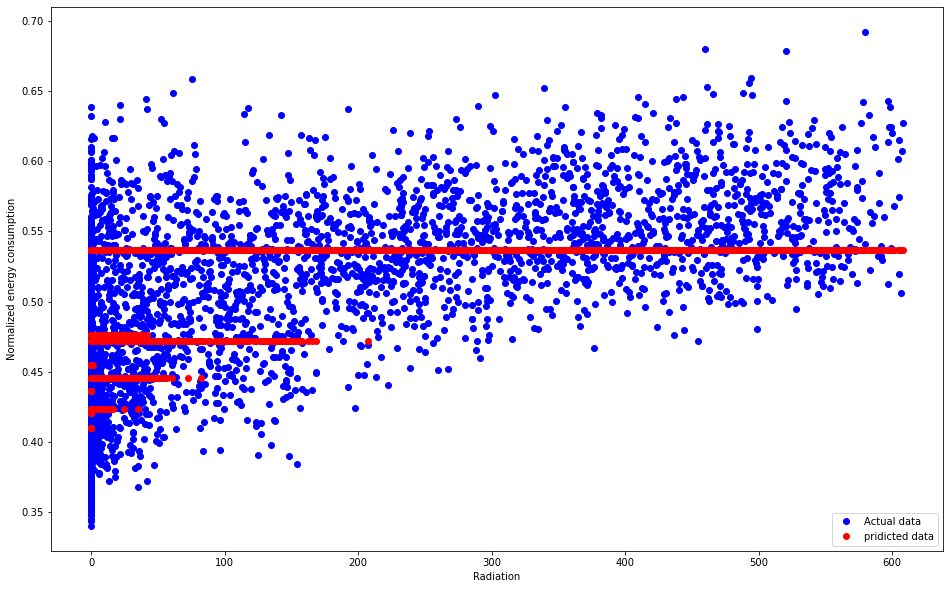

In [612]:
actual=Ev1_consumption4
y_MLP=regr.predict(X)
plt.figure(figsize=(16, 10))
plt.plot(Rad4,actual,'bo')
plt.plot(Rad4,y_MLP,'ro')
plt.legend(["Actual data", "pridicted data"], loc ="lower right") 
plt.xlabel("Radiation")
plt.ylabel("Normalized energy consumption") 
plt.show() 

In [87]:
#Fitting Cluster 5

In [217]:
Ev1_consumption5=np.zeros(consumption_cl5.shape[0]*consumption_cl5.shape[1]).reshape(consumption_cl5.shape[0]*consumption_cl5.shape[1],1)
Ev1_consumption5_clean=np.zeros(consumption_cl5.shape[0]*consumption_cl5.shape[1]).reshape(consumption_cl5.shape[0]*consumption_cl5.shape[1],1)
Time5=np.zeros(consumption_cl5.shape[0]*consumption_cl5.shape[1]).reshape(consumption_cl5.shape[0]*consumption_cl5.shape[1],1)
Time5_1=np.zeros(consumption_cl5.shape[0]*consumption_cl5.shape[1]).reshape(consumption_cl5.shape[0]*consumption_cl5.shape[1],1)
Sch5=np.zeros(consumption_cl5.shape[0]*consumption_cl5.shape[1]).reshape(consumption_cl5.shape[0]*consumption_cl5.shape[1],1)
Temprature5=np.zeros(consumption_cl5.shape[0]*consumption_cl5.shape[1]).reshape(consumption_cl5.shape[0]*consumption_cl5.shape[1],1)
Rad5=np.zeros(consumption_cl5.shape[0]*consumption_cl5.shape[1]).reshape(consumption_cl5.shape[0]*consumption_cl5.shape[1],1)
Ocup5=np.zeros(consumption_cl5.shape[0]*consumption_cl5.shape[1]).reshape(consumption_cl5.shape[0]*consumption_cl5.shape[1],1)

k=0
for i in range (consumption_cl5.shape[0]):
    t=0
    for j in range (consumption_cl5.shape[1]):
        Time5[k,0]=t
        Time5_1[k,0]=1-abs(t-12)/12
        Sch5[k,0]=schadule[j]
        Ocup5[k,0]=Ocu_schadule[j]
#         Ev1_consumption5[k,0]=consumption_cl5_N[i,j]
        Ev1_consumption5[k,0]=consumption_cl5_N[i,j]
#         Ev1_consumption5_clean[k,0]=cl5_clean[i,j]
        Temprature5[k,0]=Temp_cl5[i,j]
        Rad5[k,0]=Total_Rad_cl5[i,j]
        k=k+1
        t=t+1

Time5_1[12,0]

1.0

In [151]:
temp_daily_5=average_finder(Temprature5,24)
min_temp5=temp_daily_5.min()
max_temp5=temp_daily_5.max()
print('min temprature=',min_temp5)
print('max temprature=',max_temp5)
av_temp_5=np.average(temp_daily_5)
print ("average temperature clusterav_temp_3=",av_temp_5)
# Consumption_daily_cl1=sum_finder(Ev1_consumption1,24)
# Ev1_consumption5=sum_finder(Ev1_consumption5,24)

min temprature= 5.75
max temprature= 24.75
average temperature clusterav_temp_3= 18.288157894736845


In [218]:
# input_ev5=temp_daily_5
# input_ev5=Temprature5
# input_ev5=np.c_[Ocup5, Sch5]
input_ev5=np.c_[Temprature5, Rad5]
# input_ev5=np.c_[input_ev5, Sch5]
# input_ev5=np.c_[input_ev5, Ocup5]
# input_ev5=np.c_[input_ev5, Time5]
input_ev5

array([[-5.,  0.],
       [-6.,  0.],
       [-6.,  0.],
       ...,
       [ 4.,  0.],
       [ 4.,  0.],
       [ 5.,  0.]])

In [154]:
#Linear Regression
from sklearn.linear_model import LinearRegression
regr = LinearRegression()
actual = Ev1_consumption5
#in x get all columns except goals column

regr.fit(input_ev5,Ev1_consumption5)
#regr.predict(x)  

predict = regr.predict(input_ev5)
from sklearn.metrics import mean_squared_error
rms = mean_squared_error(actual, predict, squared=False)
print ("Mean square erro=",rms)

from sklearn.metrics import r2_score 
r2 = r2_score(actual, predict) 
print("R^2=",r2)

from sklearn.metrics import mean_absolute_percentage_error 
err=mean_absolute_percentage_error(actual, predict)
print ("error=", err*100)

Mean square erro= 0.056152135079094466
R^2= 0.6749625591247765
error= 8.682186468622938


In [155]:
regr.coef_

array([[-8.36320792e-05,  9.17643704e-02,  9.67569930e-02,
         7.53847607e-02]])

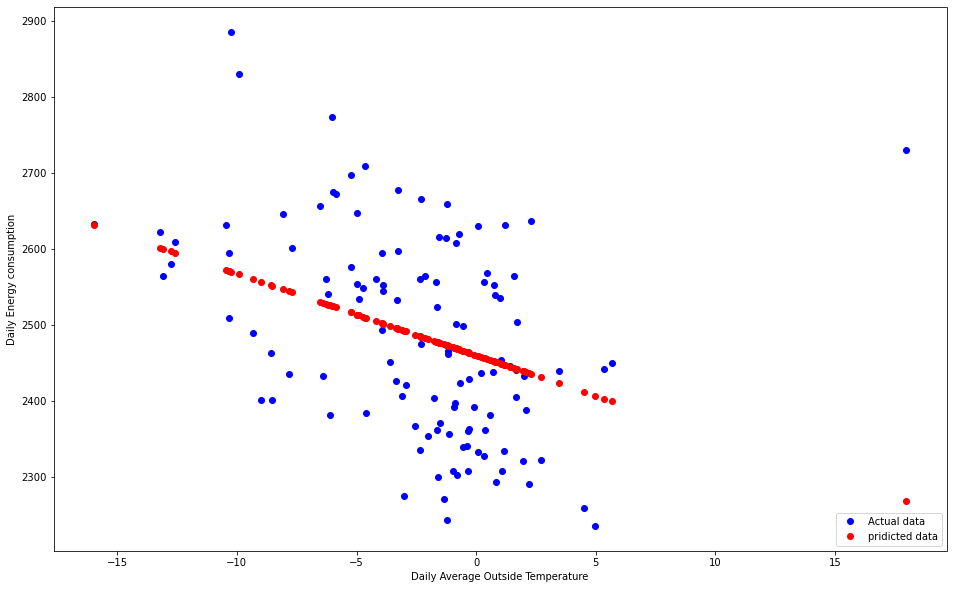

In [135]:
plt.figure(figsize=(16, 10))
plt.plot(temp_daily_5,actual,'bo')
plt.plot(temp_daily_5,predict,'ro')
plt.legend(["Actual data", "pridicted data"], loc ="lower right") 
plt.xlabel("Daily Average Outside Temperature")
plt.ylabel("Daily Energy consumption") 
plt.show() 

In [310]:
# Polynomial fitting 
from sklearn.preprocessing import PolynomialFeatures
regr = PolynomialFeatures(degree=2, include_bias=False)
actual = Ev1_consumption5
#in x get all columns except goals column


#regr.fit(fit_1[["Time","Temperature (C)"]],fit_1[["Energy consumption (kWh)"]])
#regr.predict(x)  
X_poly  = regr.fit_transform(input_ev5)
model = LinearRegression()
model.fit(X_poly, actual) 
y_pred = model.predict(X_poly)

#from sklearn.metrics import mean_squared_error
rms = mean_squared_error(actual, y_pred, squared=False)  
print ("meant square error=",rms)

from sklearn.metrics import r2_score 
r2 = r2_score(actual, y_pred) 
print( "R^2=",r2)

from sklearn.metrics import mean_absolute_percentage_error 
err=mean_absolute_percentage_error(actual, y_pred)
print (" MAPE=", err*100)

meant square error= 0.07543828080748759
R^2= 0.07660131828850136
 MAPE= 12.53815300879563


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [312]:
# Polynomial fitting 
# Assuming:
# input_ev5 = your features (X)
# Ev1_consumption5 = your target (y)

# 1. Split data into train/test sets (80/20 split)
X_train5, X_test5, y_train5, y_test5 = train_test_split(
    input_ev5, 
    Ev1_consumption5, 
    test_size=0.2, 
    random_state=42
)

# # 2. Scale features (critical for polynomial regression)
# scaler = StandardScaler()
# X_train_scaled5 = scaler.fit_transform(X_train5)
# X_test_scaled5 = scaler.transform(X_test5)

# 3. Generate polynomial features (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly5 = poly.fit_transform(X_train5)
X_test_poly5 = poly.transform(X_test5)  # Important: use transform(), not fit_transform()

# 4. Train model
model = LinearRegression()
model.fit(X_train_poly5, y_train5)

# 5. Evaluate
train_pred = model.predict(X_train_poly5)
test_pred = model.predict(X_test_poly5)

# Metrics for training set (for reference)
print("=== Training Set ===")
print(f"MSE: {mean_squared_error(y_train5, train_pred):.4f}")
print(f"R²: {r2_score(y_train5, train_pred):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_train5, train_pred)*100:.2f}%")

# Metrics for test set (true performance)
print("\n=== Test Set ===")
print(f"MSE: {mean_squared_error(y_test5, test_pred):.4f}")
print(f"R²: {r2_score(y_test5, test_pred):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test5, test_pred)*100:.2f}%")


=== Training Set ===
MSE: 0.0054
R²: 0.0914
MAPE: 12.34%

=== Test Set ===
MSE: 0.0068
R²: 0.0165
MAPE: 13.07%


In [122]:
model.coef_

array([[-1.00170774e-03,  4.10011512e-01, -8.87011064e-01,
        -5.74098004e-05,  6.80597845e-03, -6.11312302e-04,
        -3.72174494e-01,  1.01261046e+00,  7.78693460e-03]])

In [123]:
model.intercept_

array([0.37938679])

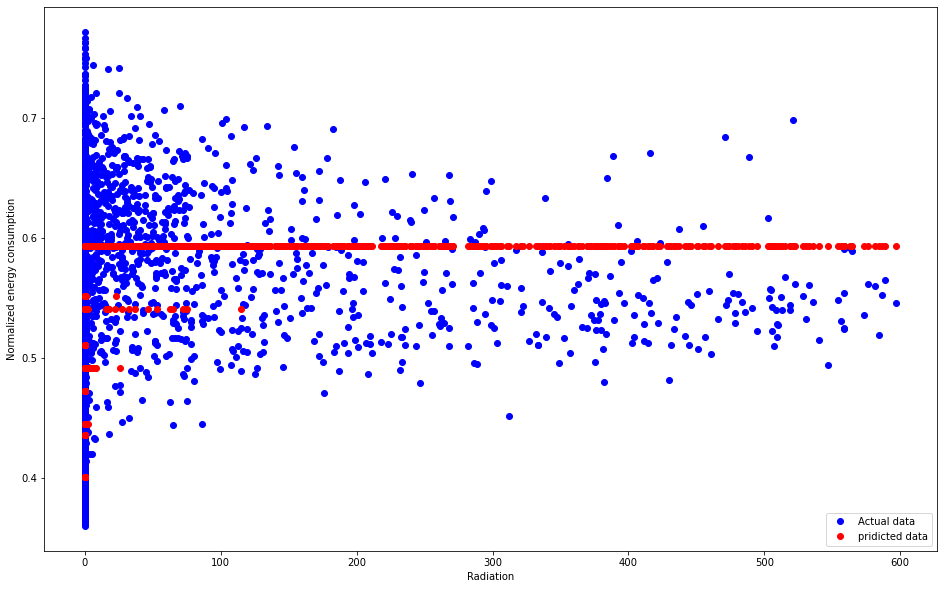

In [621]:
plt.figure(figsize=(16, 10))
plt.plot(Rad5,actual,'bo')
plt.plot(Rad5,y_pred,'ro')
plt.legend(["Actual data", "pridicted data"], loc ="lower right") 
plt.xlabel("Radiation")
plt.ylabel("Normalized energy consumption") 
plt.show() 

In [624]:
# #Neural network
# from sklearn.neural_network import MLPRegressor
# from sklearn.datasets import make_regression
# from sklearn.model_selection import train_test_split
# #mlp = MLPRegressor(hidden_layer_sizes=(200, 100))
# #X, y = make_regression(n_samples=200, random_state=1)
# X =input_ev5
# y =Ev1_consumption5_clean
# X_train, X_test, y_train, y_test = train_test_split(X, y,random_state=1)
# regr = MLPRegressor(random_state=1, max_iter=500).fit(X_train, y_train)
# #regr=mlp.fit(X_train, y_train)
# regr.predict(X_test[:2])
# regr.score(X_test, y_test)

C:\Users\e3akbari\anaconda3\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


0.6899139150159528

In [625]:
# pre=regr.predict(X)
# from sklearn.metrics import mean_squared_error
# rms = mean_squared_error(y, pre, squared=False)  
# print ("Mean square error=", rms)

# from sklearn.metrics import mean_absolute_percentage_error 
# err=mean_absolute_percentage_error(y, pre)*100
# print ("error=", err)

Mean square error= 0.053015364652035164
error= 7.152613175777257


In [314]:
#Neural network (MLP)

X =input_ev5
y =Ev1_consumption5
X_train5, X_test5, y_train5, y_test5 = train_test_split(X, y, random_state=1)

# # Scale the data (important for neural networks)
# scaler = StandardScaler()
# X_train_scaled5 = scaler.fit_transform(X_train5)
# X_test_scaled5 = scaler.transform(X_test5)

# Define the parameter grid
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50,50), (100,50), (200,100)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['adam', 'lbfgs'],
    'alpha': [0.0001, 0.001, 0.01],  # L2 regularization
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [500, 1000],
    'early_stopping': [True],
    'validation_fraction': [0.1]
}

# Create the MLPRegressor
mlp = MLPRegressor(random_state=1)

# Create GridSearchCV object
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)

# Fit the model
grid_search.fit(X_train5, y_train5)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

# Evaluate on test set
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test5, y_test5)
print("Test score: ", test_score)

Fitting 5 folds for each of 720 candidates, totalling 3600 fits


C:\Users\User\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1624: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters found:  {'activation': 'relu', 'alpha': 0.01, 'early_stopping': True, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_iter': 1000, 'solver': 'lbfgs', 'validation_fraction': 0.1}
Best score:  0.08884420504749817
Test score:  0.01117011040442839


C:\Users\User\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [315]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred5 = best_model.predict(X_test5)
print(f"MSE: {mean_squared_error(y_test5, y_pred5):.4f}")
print(f"MAE: {mean_absolute_error(y_test5, y_pred5):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test5, y_pred5)):.4f}")

MSE: 0.0059
MAE: 0.0617
RMSE: 0.0768


In [223]:
###MPL optimization using optuna

import optuna
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import numpy as np

# Load your data
X = input_ev5
y = Ev1_consumption5

# Split data
X_train5, X_test5, y_train5, y_test5 = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale data
scaler = StandardScaler()
X_train_scaled5= scaler.fit_transform(X_train5)
X_test_scaled5 = scaler.transform(X_test5)

def objective(trial):
    # Define hyperparameter search space
    params = {
        'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes', 
                                      [(50,), (100,), (1000,), (50,50), (100,50), (200,100)]),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh', 'logistic']),
        'solver': trial.suggest_categorical('solver', ['adam', 'lbfgs']),
        'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        'learning_rate': trial.suggest_categorical('learning_rate', ['constant', 'adaptive']),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [16, 32, 64, 128]),
        'max_iter': 10000,
        'early_stopping': True,
        'random_state': 42
    }
    
    # Create and evaluate model
    model = MLPRegressor(**params)
    
    # Use cross-validation instead of a single train/validation split
    scores = cross_val_score(model, X_train_scaled5, y_train5, cv=5, scoring='r2', n_jobs=-1)
    # scores = cross_val_score(model, X_train2, y_train2, cv=5, scoring='r2', n_jobs=-1)
    
    # Return the mean validation score
    return np.mean(scores)

# Create Optuna study
study = optuna.create_study(direction='maximize')  # We maximize R² score
study.optimize(objective, n_trials=250)  # Number of trials

# Best trial results
print(f"Best trial R² score: {study.best_value:.4f}")
print("Best parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Train final model with best parameters
best_model_5 = MLPRegressor(**study.best_params)
best_model_5.fit(X_train_scaled5, y_train5)
# best_model.fit(X_train5, y_train5)

# Evaluate on test set
test_r2 = best_model_5.score(X_test_scaled5, y_test5)
# test_r2 = best_model_5.score(X_test5, y_test5)
print(f"\nTest R² score: {test_r2:.4f}")

[I 2025-05-21 14:20:04,772] A new study created in memory with name: no-name-e09583c9-293d-450e-b233-8ec2c421e3e4
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50,) which is of type tuple.
  warnings.warn(message)
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  warnings.warn(message)
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1000,) which is of type tuple.
  warnings.warn(message)
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: C

Best trial R² score: 0.1216
Best parameters:
  hidden_layer_sizes: (100, 50)
  activation: relu
  solver: lbfgs
  alpha: 0.05484722479914322
  learning_rate: adaptive
  learning_rate_init: 0.009487035205606975
  batch_size: 16

Test R² score: 0.0504


C:\Users\User\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [227]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

# 1. Get predictions
y_train_pred5 = best_model_5.predict(X_train_scaled5)
y_test_pred5 = best_model_5.predict(X_test_scaled5)

# 2. Calculate metrics
metrics = {
    'MSE': {
        'train': mean_squared_error(y_train5, y_train_pred5),
        'test': mean_squared_error(y_test5, y_test_pred5)
    },
    'RMSE': {
        'train': np.sqrt(mean_squared_error(y_train5, y_train_pred5)),
        'test': np.sqrt(mean_squared_error(y_test5, y_test_pred5))
    },
    'R²': {
        'train': r2_score(y_train5, y_train_pred5),
        'test': r2_score(y_test5, y_test_pred5)
    },
    'MAPE (%)': {
        'train': mean_absolute_percentage_error(y_train5, y_train_pred5) * 100,
        'test': mean_absolute_percentage_error(y_test5, y_test_pred5) * 100
    }
}

# 3. Print results in a clean table
print("\n" + "="*50)
print(f"{'Metric':<20}{'Training Set':>15}{'Test Set':>15}")
print("="*50)
for metric_name, values in metrics.items():
    print(f"{metric_name:<20}{values['train']:>15.4f}{values['test']:>15.4f}")
print("="*50)


Metric                 Training Set       Test Set
MSE                          0.0051         0.0066
RMSE                         0.0717         0.0810
R²                           0.1392         0.0504
MAPE (%)                    11.7568        12.8008


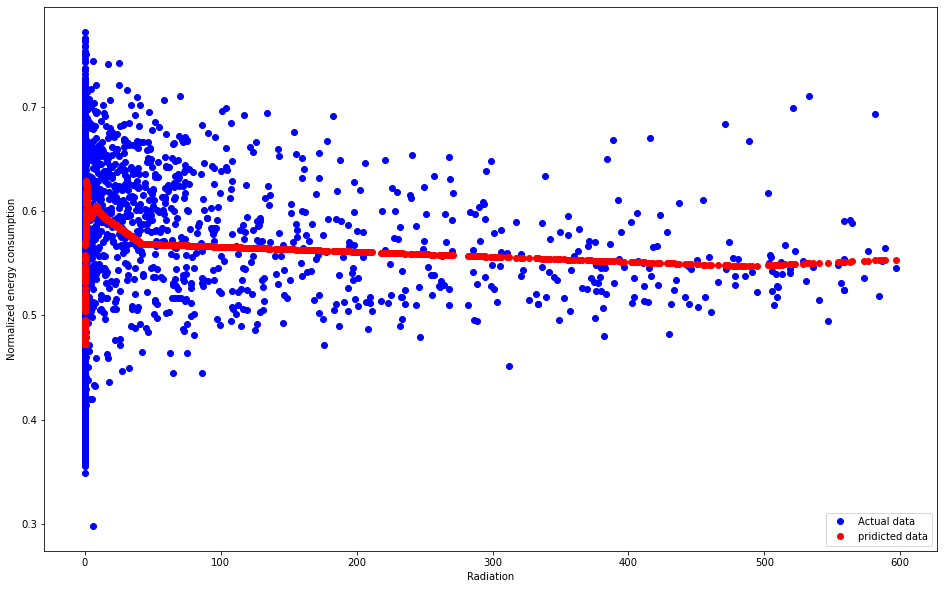

In [398]:
actual=Ev1_consumption5
y_MLP=regr.predict(X)
plt.figure(figsize=(16, 10))
plt.plot(Rad5,actual,'bo')
plt.plot(Rad5,y_MLP,'ro')
plt.legend(["Actual data", "pridicted data"], loc ="lower right") 
plt.xlabel("Radiation")
plt.ylabel("Normalized energy consumption") 
plt.show() 

In [98]:
#Fitting Cluster 6

In [229]:
Ev1_consumption6=np.zeros(consumption_cl6.shape[0]*consumption_cl6.shape[1]).reshape(consumption_cl6.shape[0]*consumption_cl6.shape[1],1)
Ev1_consumption6_clean=np.zeros(consumption_cl6.shape[0]*consumption_cl6.shape[1]).reshape(consumption_cl6.shape[0]*consumption_cl6.shape[1],1)
Time6=np.zeros(consumption_cl6.shape[0]*consumption_cl6.shape[1]).reshape(consumption_cl6.shape[0]*consumption_cl6.shape[1],1)
Time6_1=np.zeros(consumption_cl6.shape[0]*consumption_cl6.shape[1]).reshape(consumption_cl6.shape[0]*consumption_cl6.shape[1],1)
Sch6=np.zeros(consumption_cl6.shape[0]*consumption_cl6.shape[1]).reshape(consumption_cl6.shape[0]*consumption_cl6.shape[1],1)
Temprature6=np.zeros(consumption_cl6.shape[0]*consumption_cl6.shape[1]).reshape(consumption_cl6.shape[0]*consumption_cl6.shape[1],1)
Rad6=np.zeros(consumption_cl6.shape[0]*consumption_cl6.shape[1]).reshape(consumption_cl6.shape[0]*consumption_cl6.shape[1],1)
Ocup6=np.zeros(consumption_cl6.shape[0]*consumption_cl6.shape[1]).reshape(consumption_cl6.shape[0]*consumption_cl6.shape[1],1)
k=0
for i in range (consumption_cl6.shape[0]):
    t=0
    for j in range (consumption_cl6.shape[1]):
        Time6[k,0]=t
        Time6_1[k,0]=1-abs(t-12)/12
        Sch6[k,0]=schadule[j]
        Ocup6[k,0]=Ocu_schadule[j]
#         Ev1_consumption6[k,0]=consumption_cl6_N[i,j]
        Ev1_consumption6[k,0]=consumption_cl6_N[i,j]
#         Ev1_consumption6_clean[k,0]=cl6_clean[i,j]
        Temprature6[k,0]=Temp_cl6[i,j]
        Rad6[k,0]=Total_Rad_cl6[i,j]
        k=k+1
        t=t+1

Time6_1[12,0]

1.0

In [163]:
temp_daily_6=average_finder(Temprature6,24)
min_temp6=temp_daily_6.min()
max_temp6=temp_daily_6.max()
print('min temprature=',min_temp6)
print('max temprature=',max_temp6)
av_temp_6=np.average(temp_daily_6)
print ("average temperature clusterav_temp_3=",av_temp_6)
# Consumption_daily_cl1=sum_finder(Ev1_consumption1,24)
# Ev1_consumption6=sum_finder(Ev1_consumption6,24)

min temprature= -2.5833333333333335
max temprature= 25.041666666666668
average temperature clusterav_temp_3= 13.999293785310735


In [231]:
# input_ev6=temp_daily_6
# input_ev6=Temprature6
input_ev6=np.c_[Temprature6,Rad6 ]
# input_ev6=np.c_[input_ev6,Sch6 ]
# input_ev6=np.c_[input_ev6, Ocup6]
# input_ev6=np.c_[input_ev6, Time6]
input_ev6

array([[20.,  0.],
       [20.,  0.],
       [19.,  0.],
       ...,
       [13.,  0.],
       [13.,  0.],
       [13.,  0.]])

In [172]:
#Linear Regression
from sklearn.linear_model import LinearRegression
regr = LinearRegression()
actual = Ev1_consumption6
#in x get all columns except goals column

regr.fit(input_ev6,Ev1_consumption6)
#regr.predict(x)  

predict = regr.predict(input_ev6)
from sklearn.metrics import mean_squared_error
rms = mean_squared_error(actual, predict, squared=False)
print ("Mean square erro=",rms)

from sklearn.metrics import r2_score 
r2 = r2_score(actual, predict) 
print("R^2=",r2)

from sklearn.metrics import mean_absolute_percentage_error 
err=mean_absolute_percentage_error(actual, predict)
print ("error=", err*100)

Mean square erro= 0.03231187727214676
R^2= 0.7734591469744986
error= 5.210754311276863


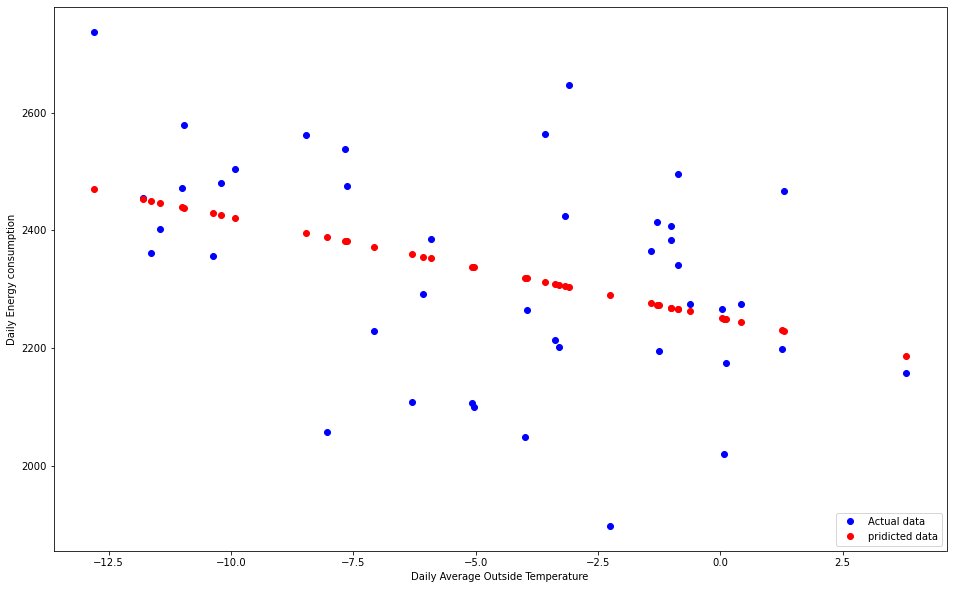

In [141]:
plt.figure(figsize=(16, 10))
plt.plot(temp_daily_6,actual,'bo')
plt.plot(temp_daily_6,predict,'ro')
plt.legend(["Actual data", "pridicted data"], loc ="lower right") 
plt.xlabel("Daily Average Outside Temperature")
plt.ylabel("Daily Energy consumption") 
plt.show() 

In [329]:
# Polynomial fitting 
from sklearn.preprocessing import PolynomialFeatures
regr = PolynomialFeatures(degree=2, include_bias=False)
actual = Ev1_consumption6
#in x get all columns except goals column


#regr.fit(fit_1[["Time","Temperature (C)"]],fit_1[["Energy consumption (kWh)"]])
#regr.predict(x)  
X_poly  = regr.fit_transform(input_ev6)
model = LinearRegression()
model.fit(X_poly, actual) 
y_pred = model.predict(X_poly)

#from sklearn.metrics import mean_squared_error
rms = mean_squared_error(actual, y_pred, squared=False)  
print ("meant square error=",rms)

from sklearn.metrics import r2_score 
r2 = r2_score(actual, y_pred) 
print( "R^2=",r2)

from sklearn.metrics import mean_absolute_percentage_error 
err=mean_absolute_percentage_error(actual, y_pred)
print ("MAPE=", err*100)

meant square error= 0.06362436630358638
R^2= 0.5827005797723837
MAPE= 10.500209049948229


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [331]:
# Polynomial fitting 
# Assuming:
# input_ev6 = your features (X)
# Ev1_consumption6 = your target (y)

# 1. Split data into train/test sets (80/20 split)
X_train6, X_test6, y_train6, y_test6 = train_test_split(
    input_ev6, 
    Ev1_consumption6, 
    test_size=0.2, 
    random_state=42
)

# # 2. Scale features (critical for polynomial regression)
# scaler = StandardScaler()
# X_train_scaled2 = scaler.fit_transform(X_train2)
# X_test_scaled2 = scaler.transform(X_test2)

# 3. Generate polynomial features (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly6 = poly.fit_transform(X_train6)
X_test_poly6 = poly.transform(X_test6)  # Important: use transform(), not fit_transform()

# 4. Train model
model = LinearRegression()
model.fit(X_train_poly6, y_train6)

# 5. Evaluate
train_pred = model.predict(X_train_poly6)
test_pred = model.predict(X_test_poly6)

# Metrics for training set (for reference)
print("=== Training Set ===")
print(f"MSE: {mean_squared_error(y_train6, train_pred):.4f}")
print(f"R²: {r2_score(y_train6, train_pred):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_train6, train_pred)*100:.2f}%")

# Metrics for test set (true performance)
print("\n=== Test Set ===")
print(f"MSE: {mean_squared_error(y_test6, test_pred):.4f}")
print(f"R²: {r2_score(y_test6, test_pred):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test6, test_pred)*100:.2f}%")


=== Training Set ===
MSE: 0.0040
R²: 0.5827
MAPE: 10.49%

=== Test Set ===
MSE: 0.0042
R²: 0.5822
MAPE: 10.55%


In [134]:
model.coef_

array([[-9.68371437e-04,  2.16545040e-01, -2.46343410e-01,
         7.74953772e-05, -1.62320483e-03,  1.32653380e-03,
        -1.24661080e-01,  3.50091476e-01, -2.02100715e-02]])

In [135]:
model.intercept_

array([0.36848413])

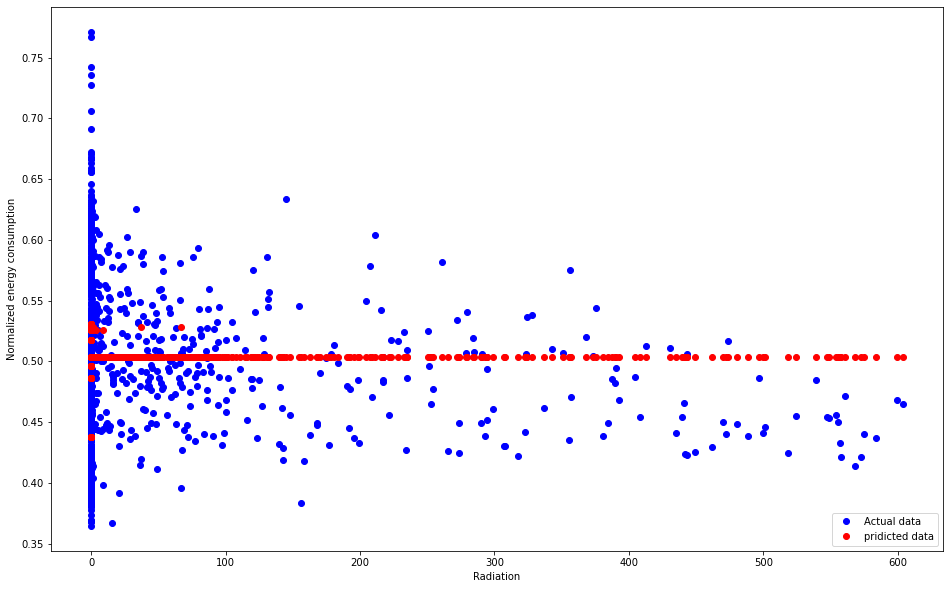

In [641]:
plt.figure(figsize=(16, 10))
plt.plot(Rad6,actual,'bo')
plt.plot(Rad6,y_pred,'ro')
plt.legend(["Actual data", "pridicted data"], loc ="lower right") 
plt.xlabel("Radiation")
plt.ylabel("Normalized energy consumption") 
plt.show() 

In [644]:
#Neural network
from sklearn.neural_network import MLPRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
#mlp = MLPRegressor(hidden_layer_sizes=(200, 100))
#X, y = make_regression(n_samples=200, random_state=1)
X =input_ev6
y =Ev1_consumption6_clean
X_train, X_test, y_train, y_test = train_test_split(X, y,random_state=1)
regr = MLPRegressor(random_state=1, max_iter=500).fit(X_train, y_train)
#regr=mlp.fit(X_train, y_train)
regr.predict(X_test[:2])
regr.score(X_test, y_test)

C:\Users\e3akbari\anaconda3\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


0.07788750114364373

In [645]:
pre=regr.predict(X)
from sklearn.metrics import mean_squared_error
rms = mean_squared_error(y, pre, squared=False)  
print ("Mean square error=", rms)

from sklearn.metrics import mean_absolute_percentage_error 
err=mean_absolute_percentage_error(y, pre)*100
print ("error=", err)

Mean square error= 0.06521228839395204
error= 10.288126571847046


In [322]:
#Neural network (MLP) using grid search

X =input_ev6
y =Ev1_consumption6
X_train6, X_test6, y_train6, y_test6 = train_test_split(X, y, random_state=1)

# # Scale the data (important for neural networks)
# scaler = StandardScaler()
# X_train_scaled6 = scaler.fit_transform(X_train6)
# X_test_scaled6 = scaler.transform(X_test6)

# Define the parameter grid
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50,50), (100,50), (200,100)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['adam', 'lbfgs'],
    'alpha': [0.0001, 0.001, 0.01],  # L2 regularization
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [500, 1000],
    'early_stopping': [True],
    'validation_fraction': [0.1]
}

# Create the MLPRegressor
mlp = MLPRegressor(random_state=1)

# Create GridSearchCV object
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)

# Fit the model
grid_search.fit(X_train6, y_train6)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

# Evaluate on test set
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test6, y_test6)
print("Test score: ", test_score)

Fitting 5 folds for each of 720 candidates, totalling 3600 fits


C:\Users\User\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1624: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters found:  {'activation': 'relu', 'alpha': 0.0001, 'early_stopping': True, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant', 'learning_rate_init': 0.01, 'max_iter': 500, 'solver': 'adam', 'validation_fraction': 0.1}
Best score:  0.6073059876078943
Test score:  0.6001687428343248


In [327]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred6 = best_model.predict(X_test6)
print(f"MSE: {mean_squared_error(y_test6, y_pred6):.4f}")
print(f"MAE: {mean_absolute_error(y_test6, y_pred6):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test6, y_pred6)):.4f}")

MSE: 0.0038
MAE: 0.0483
RMSE: 0.0618


In [233]:
###MPL optimization using optuna

import optuna
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import numpy as np

# Load your data
X = input_ev6
y = Ev1_consumption6

# Split data
X_train6, X_test6, y_train6, y_test6 = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale data
scaler = StandardScaler()
X_train_scaled6= scaler.fit_transform(X_train6)
X_test_scaled6 = scaler.transform(X_test6)

def objective(trial):
    # Define hyperparameter search space
    params = {
        'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes', 
                                      [(50,), (100,), (1000,), (50,50), (100,50), (200,100)]),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh', 'logistic']),
        'solver': trial.suggest_categorical('solver', ['adam', 'lbfgs']),
        'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        'learning_rate': trial.suggest_categorical('learning_rate', ['constant', 'adaptive']),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [16, 32, 64, 128]),
        'max_iter': 10000,
        'early_stopping': True,
        'random_state': 42
    }
    
    # Create and evaluate model
    model = MLPRegressor(**params)
    
    # Use cross-validation instead of a single train/validation split
    scores = cross_val_score(model, X_train_scaled6, y_train6, cv=5, scoring='r2', n_jobs=-1)
    # scores = cross_val_score(model, X_train2, y_train2, cv=5, scoring='r2', n_jobs=-1)
    
    # Return the mean validation score
    return np.mean(scores)

# Create Optuna study
study = optuna.create_study(direction='maximize')  # We maximize R² score
study.optimize(objective, n_trials=250)  # Number of trials

# Best trial results
print(f"Best trial R² score: {study.best_value:.4f}")
print("Best parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Train final model with best parameters
best_model_6 = MLPRegressor(**study.best_params)
best_model_6.fit(X_train_scaled6, y_train6)
# best_model.fit(X_train6, y_train6)

# Evaluate on test set
test_r2 = best_model_6.score(X_test_scaled6, y_test6)
# test_r2 = best_model_6.score(X_test6, y_test6)
print(f"\nTest R² score: {test_r2:.4f}")

[I 2025-05-21 14:25:07,379] A new study created in memory with name: no-name-2632f680-0d8c-4a72-86dc-8c263917cb52
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50,) which is of type tuple.
  warnings.warn(message)
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  warnings.warn(message)
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1000,) which is of type tuple.
  warnings.warn(message)
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: C

Best trial R² score: 0.6257
Best parameters:
  hidden_layer_sizes: (200, 100)
  activation: relu
  solver: lbfgs
  alpha: 0.004534960320734903
  learning_rate: adaptive
  learning_rate_init: 0.003627748214590612
  batch_size: 128

Test R² score: 0.6234


In [234]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

# 1. Get predictions
y_train_pred6 = best_model_6.predict(X_train_scaled6)
y_test_pred6 = best_model_6.predict(X_test_scaled6)

# 2. Calculate metrics
metrics = {
    'MSE': {
        'train': mean_squared_error(y_train6, y_train_pred6),
        'test': mean_squared_error(y_test6, y_test_pred6)
    },
    'RMSE': {
        'train': np.sqrt(mean_squared_error(y_train6, y_train_pred6)),
        'test': np.sqrt(mean_squared_error(y_test6, y_test_pred6))
    },
    'R²': {
        'train': r2_score(y_train6, y_train_pred6),
        'test': r2_score(y_test6, y_test_pred6)
    },
    'MAPE (%)': {
        'train': mean_absolute_percentage_error(y_train6, y_train_pred6) * 100,
        'test': mean_absolute_percentage_error(y_test6, y_test_pred6) * 100
    }
}

# 3. Print results in a clean table
print("\n" + "="*50)
print(f"{'Metric':<20}{'Training Set':>15}{'Test Set':>15}")
print("="*50)
for metric_name, values in metrics.items():
    print(f"{metric_name:<20}{values['train']:>15.4f}{values['test']:>15.4f}")
print("="*50)


Metric                 Training Set       Test Set
MSE                          0.0035         0.0037
RMSE                         0.0592         0.0612
R²                           0.6370         0.6234
MAPE (%)                     9.2738         9.7221


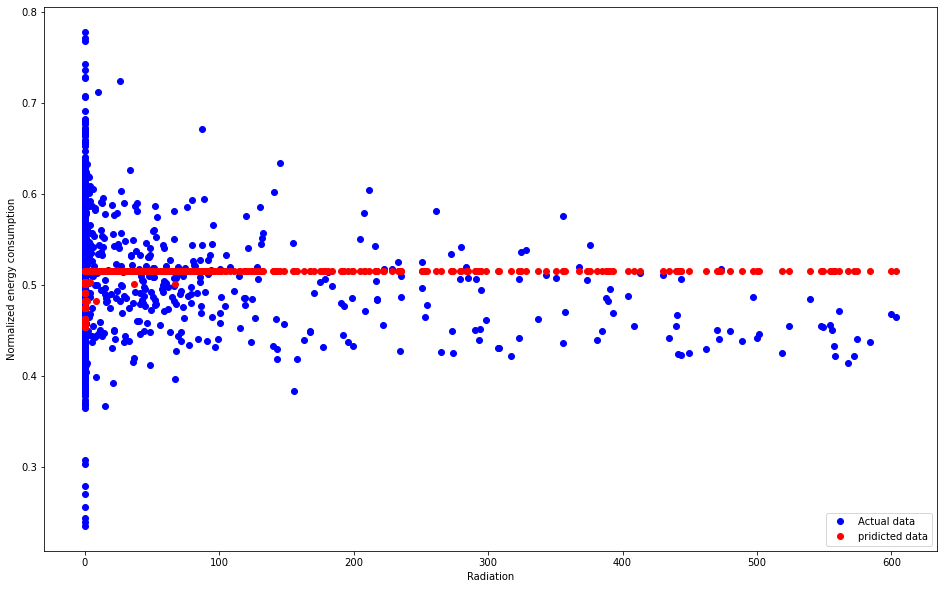

In [646]:
actual=Ev1_consumption6
y_MLP=regr.predict(X)
plt.figure(figsize=(16, 10))
plt.plot(Rad6,actual,'bo')
plt.plot(Rad6,y_MLP,'ro')
plt.legend(["Actual data", "pridicted data"], loc ="lower right") 
plt.xlabel("Radiation")
plt.ylabel("Normalized energy consumption") 
plt.show() 

In [ ]:
#Fitting cluster 7

In [237]:
Ev1_consumption7=np.zeros(consumption_cl7.shape[0]*consumption_cl7.shape[1]).reshape(consumption_cl7.shape[0]*consumption_cl7.shape[1],1)
Ev1_consumption7_clean=np.zeros(consumption_cl7.shape[0]*consumption_cl7.shape[1]).reshape(consumption_cl7.shape[0]*consumption_cl7.shape[1],1)
Time7=np.zeros(consumption_cl7.shape[0]*consumption_cl7.shape[1]).reshape(consumption_cl7.shape[0]*consumption_cl7.shape[1],1)
Time7_1=np.zeros(consumption_cl7.shape[0]*consumption_cl7.shape[1]).reshape(consumption_cl7.shape[0]*consumption_cl7.shape[1],1)
Sch7=np.zeros(consumption_cl7.shape[0]*consumption_cl7.shape[1]).reshape(consumption_cl7.shape[0]*consumption_cl7.shape[1],1)
Temprature7=np.zeros(consumption_cl7.shape[0]*consumption_cl7.shape[1]).reshape(consumption_cl7.shape[0]*consumption_cl7.shape[1],1)
Rad7=np.zeros(consumption_cl7.shape[0]*consumption_cl7.shape[1]).reshape(consumption_cl7.shape[0]*consumption_cl7.shape[1],1)
Ocup7=np.zeros(consumption_cl7.shape[0]*consumption_cl7.shape[1]).reshape(consumption_cl7.shape[0]*consumption_cl7.shape[1],1)
k=0
for i in range (consumption_cl7.shape[0]):
    t=0
    for j in range (consumption_cl7.shape[1]):
        Time7[k,0]=t
        Time7_1[k,0]=1-abs(t-12)/12
        Sch7[k,0]=schadule[j]
        Ocup7[k,0]=Ocu_schadule[j]
#         Ev1_consumption7[k,0]=consumption_cl7_N[i,j]
        Ev1_consumption7[k,0]=consumption_cl7_N[i,j]
#         Ev1_consumption7_clean[k,0]=cl7_clean[i,j]
        Temprature7[k,0]=Temp_cl7[i,j]
        Rad7[k,0]=Total_Rad_cl7[i,j]
        k=k+1
        t=t+1

Time7_1[12,0]

1.0

In [335]:
temp_daily_7=average_finder(Temprature7,24)
min_temp7=temp_daily_7.min()
max_temp7=temp_daily_7.max()
print('min temprature=',min_temp7)
print('max temprature=',max_temp7)
av_temp_7=np.average(temp_daily_7)
print ("average temperature clusterav_temp_7=",av_temp_7)
# Consumption_daily_cl1=sum_finder(Ev1_consumption7,24)
# Ev1_consumption7=sum_finder(Ev1_consumption7,24)

min temprature= -15.958333333333334
max temprature= 5.333333333333333
average temperature clusterav_temp_7= -1.7629999999999997


C:\Users\User\AppData\Local\Temp\ipykernel_61396\3814052515.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x_y[j]=x[k]


In [239]:
# input_ev7=temp_daily_7
# input_ev7=Temprature7
input_ev7=np.c_[Temprature7,Rad7 ]
# input_ev7=np.c_[input_ev7,Sch7 ]
# input_ev7=np.c_[input_ev7, Ocup7]
# input_ev7=np.c_[input_ev7, Time7]
input_ev7

array([[-3.,  0.],
       [-3.,  0.],
       [-4.,  0.],
       ...,
       [-1.,  0.],
       [-1.,  0.],
       [ 0.,  0.]])

In [339]:
#Linear Regression
from sklearn.linear_model import LinearRegression
regr = LinearRegression()
actual = Ev1_consumption7
#in x get all columns except goals column

regr.fit(input_ev7,Ev1_consumption7)
#regr.predict(x)  

predict = regr.predict(input_ev7)
from sklearn.metrics import mean_squared_error
rms = mean_squared_error(actual, predict, squared=False)
print ("Mean square erro=",rms)

from sklearn.metrics import r2_score 
r2 = r2_score(actual, predict) 
print("R^2=",r2)

from sklearn.metrics import mean_absolute_percentage_error 
err=mean_absolute_percentage_error(actual, predict)
print ("error=", err*100)

Mean square erro= 0.0892593793026307
R^2= 0.07275837307076771
error= 15.738792355191771


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [341]:
# Polynomial fitting 
from sklearn.preprocessing import PolynomialFeatures
regr = PolynomialFeatures(degree=2, include_bias=False)
actual = Ev1_consumption7
#in x get all columns except goals column


#regr.fit(fit_1[["Time","Temperature (C)"]],fit_1[["Energy consumption (kWh)"]])
#regr.predict(x)  
X_poly  = regr.fit_transform(input_ev7)
model = LinearRegression()
model.fit(X_poly, actual) 
y_pred = model.predict(X_poly)

#from sklearn.metrics import mean_squared_error
rms = mean_squared_error(actual, y_pred, squared=False)  
print ("meant square error=",rms)

# from sklearn.metrics import r2_score 
r2 = r2_score(actual, y_pred) 
print( "R^2=",r2)

from sklearn.metrics import mean_absolute_percentage_error 
err=mean_absolute_percentage_error(actual, y_pred)
print ("MAPE=", err*100)

meant square error= 0.08519006411654048
R^2= 0.15537664609282298
MAPE= 14.7080803062021


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [343]:
# Polynomial fitting 
# Assuming:
# input_ev7 = your features (X)
# Ev1_consumption7 = your target (y)

# 1. Split data into train/test sets (80/20 split)
X_train7, X_test7, y_train7, y_test7 = train_test_split(
    input_ev7, 
    Ev1_consumption7, 
    test_size=0.2, 
    random_state=42
)

# # 2. Scale features (critical for polynomial regression)
# scaler = StandardScaler()
# X_train_scaled7 = scaler.fit_transform(X_train7)
# X_test_scaled7 = scaler.transform(X_test7)

# 3. Generate polynomial features (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly7 = poly.fit_transform(X_train7)
X_test_poly7 = poly.transform(X_test7)  # Important: use transform(), not fit_transform()

# 4. Train model
model = LinearRegression()
model.fit(X_train_poly7, y_train7)

# 5. Evaluate
train_pred = model.predict(X_train_poly7)
test_pred = model.predict(X_test_poly7)

# Metrics for training set (for reference)
print("=== Training Set ===")
print(f"MSE: {mean_squared_error(y_train7, train_pred):.4f}")
print(f"R²: {r2_score(y_train7, train_pred):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_train7, train_pred)*100:.2f}%")

# Metrics for test set (true performance)
print("\n=== Test Set ===")
print(f"MSE: {mean_squared_error(y_test7, test_pred):.4f}")
print(f"R²: {r2_score(y_test7, test_pred):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test7, test_pred)*100:.2f}%")


=== Training Set ===
MSE: 0.0073
R²: 0.1610
MAPE: 14.67%

=== Test Set ===
MSE: 0.0072
R²: 0.1279
MAPE: 14.94%


In [143]:
model.coef_

array([[-2.69873845e-03,  5.57564166e-01,  2.01775367e-04,
         1.18681417e-03, -3.56630010e-01]])

In [144]:
model.intercept_

array([0.30111054])

In [345]:
#Neural network (MLP) using grid search

X =input_ev7
y =Ev1_consumption7
X_train7, X_test7, y_train7, y_test7 = train_test_split(X, y, random_state=1)

# # Scale the data (important for neural networks)
# scaler = StandardScaler()
# X_train_scaled7 = scaler.fit_transform(X_train7)
# X_test_scaled7 = scaler.transform(X_test7)

# Define the parameter grid
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50,50), (100,50), (200,100)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['adam', 'lbfgs'],
    'alpha': [0.0001, 0.001, 0.01],  # L2 regularization
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [500, 1000],
    'early_stopping': [True],
    'validation_fraction': [0.1]
}

# Create the MLPRegressor
mlp = MLPRegressor(random_state=1)

# Create GridSearchCV object
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)

# Fit the model
grid_search.fit(X_train7, y_train7)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

# Evaluate on test set
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test7, y_test7)
print("Test score: ", test_score)

Fitting 5 folds for each of 720 candidates, totalling 3600 fits


C:\Users\User\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1624: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters found:  {'activation': 'relu', 'alpha': 0.001, 'early_stopping': True, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_iter': 1000, 'solver': 'lbfgs', 'validation_fraction': 0.1}
Best score:  0.3923037336581711
Test score:  0.28299939432206433


In [346]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred7 = best_model.predict(X_test7)
print(f"MSE: {mean_squared_error(y_test7, y_pred7):.4f}")
print(f"MAE: {mean_absolute_error(y_test7, y_pred7):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test7, y_pred7)):.4f}")

MSE: 0.0062
MAE: 0.0609
RMSE: 0.0786


In [241]:
###MPL optimization using optuna

import optuna
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import numpy as np

# Load your data
X = input_ev7
y = Ev1_consumption7

# Split data
X_train7, X_test7, y_train7, y_test7 = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale data
scaler = StandardScaler()
X_train_scaled7= scaler.fit_transform(X_train7)
X_test_scaled7 = scaler.transform(X_test7)

def objective(trial):
    # Define hyperparameter search space
    params = {
        'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes', 
                                      [(50,), (100,), (1000,), (50,50), (100,50), (200,100)]),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh', 'logistic']),
        'solver': trial.suggest_categorical('solver', ['adam', 'lbfgs']),
        'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        'learning_rate': trial.suggest_categorical('learning_rate', ['constant', 'adaptive']),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [16, 32, 64, 128]),
        'max_iter': 10000,
        'early_stopping': True,
        'random_state': 42
    }
    
    # Create and evaluate model
    model = MLPRegressor(**params)
    
    # Use cross-validation instead of a single train/validation split
    scores = cross_val_score(model, X_train_scaled7, y_train7, cv=5, scoring='r2', n_jobs=-1)
    # scores = cross_val_score(model, X_train7, y_train7, cv=5, scoring='r2', n_jobs=-1)
    
    # Return the mean validation score
    return np.mean(scores)

# Create Optuna study
study = optuna.create_study(direction='maximize')  # We maximize R² score
study.optimize(objective, n_trials=250)  # Number of trials

# Best trial results
print(f"Best trial R² score: {study.best_value:.4f}")
print("Best parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Train final model with best parameters
best_model_7 = MLPRegressor(**study.best_params)
best_model_7.fit(X_train_scaled7, y_train7)
# best_model.fit(X_train7, y_train7)

# Evaluate on test set
test_r2 = best_model_7.score(X_test_scaled7, y_test7)
# test_r2 = best_model_7.score(X_test7, y_test7)
print(f"\nTest R² score: {test_r2:.4f}")

[I 2025-05-21 14:29:16,048] A new study created in memory with name: no-name-b4a47198-13fd-4ad9-85a5-fd4f12af59c5
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50,) which is of type tuple.
  warnings.warn(message)
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  warnings.warn(message)
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1000,) which is of type tuple.
  warnings.warn(message)
C:\Users\User\anaconda3\Lib\site-packages\optuna\distributions.py:515: UserWarning: C

Best trial R² score: 0.4096
Best parameters:
  hidden_layer_sizes: (1000,)
  activation: relu
  solver: lbfgs
  alpha: 0.001142789026802846
  learning_rate: constant
  learning_rate_init: 0.03094464798759509
  batch_size: 16

Test R² score: 0.3076


C:\Users\User\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [242]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

# 1. Get predictions
y_train_pred7 = best_model_7.predict(X_train_scaled7)
y_test_pred7 = best_model_7.predict(X_test_scaled7)

# 2. Calculate metrics
metrics = {
    'MSE': {
        'train': mean_squared_error(y_train7, y_train_pred7),
        'test': mean_squared_error(y_test7, y_test_pred7)
    },
    'RMSE': {
        'train': np.sqrt(mean_squared_error(y_train7, y_train_pred7)),
        'test': np.sqrt(mean_squared_error(y_test7, y_test_pred7))
    },
    'R²': {
        'train': r2_score(y_train7, y_train_pred7),
        'test': r2_score(y_test7, y_test_pred7)
    },
    'MAPE (%)': {
        'train': mean_absolute_percentage_error(y_train7, y_train_pred7) * 100,
        'test': mean_absolute_percentage_error(y_test7, y_test_pred7) * 100
    }
}

# 3. Print results in a clean table
print("\n" + "="*50)
print(f"{'Metric':<20}{'Training Set':>15}{'Test Set':>15}")
print("="*50)
for metric_name, values in metrics.items():
    print(f"{metric_name:<20}{values['train']:>15.4f}{values['test']:>15.4f}")
print("="*50)


Metric                 Training Set       Test Set
MSE                          0.0049         0.0057
RMSE                         0.0700         0.0757
R²                           0.4340         0.3076
MAPE (%)                    10.7234        11.7581
